<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Nanobridge_Qubit_Material_Screening_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Nanobridge Qubit Material and Geometry Screening

This notebook compares NbN, amorphous MoGe, and granular Al weak-link design spaces. Literature values are kept separate from extrapolated screening models. The MoGe ultrathin-film calculation is a hypothesis generator, especially below about 5 nm where phase fluctuations invalidate a simple dirty-BCS extrapolation.

Primary literature include arXiv:2103.00615, arXiv:2301.04276, arXiv:2402.00387, arXiv:2411.02178, arXiv:1911.02333, arXiv:2503.13321, arXiv:2510.19983, and arXiv:2603.17214.


In [1]:
!uv pip install -q numpy scipy pandas matplotlib qutip cupy-cuda12x

Adjacency backend: CuPy GPU sparse solver
NbN and grAl current scales use literature reference currents scaled to the configured bridge width.
The a-MoGe current scale is derived from the dirty-limit normal-resistance relation.
MoGe multilayer interlayer coupling remains phenomenological.

Baseline nanobridge comparison:


,Material,Film_t_nm,Lk_sheet_pH_sq,I_star_uA,J_star_MA_cm2,L_eff_nH,C_for_6GHz_fF,BCS_alpha_MHz,abs_alpha_over_f_percent,Length_for_100fF_um,Measured_qubit_alpha_MHz,Anchor
0,NbN,13.0,89.000,29.600,2.846,0.5562,1264.9,-0.01835,0.00031,6.325,NaN,"2025 NbN/grAl comparison, width-scaled I*"
1,grAl,50.0,150.000,8.920,0.223,0.9375,750.5,-0.11992,0.00200,3.753,4.48,"2025 NbN/grAl comparison, width-scaled I*"
2,a-MoGe,10.0,33.439,3.149,0.394,0.2090,3366.7,-4.31506,0.07192,16.834,NaN,"Dirty-limit I0 from Rn, Tc, and bridge geometry"


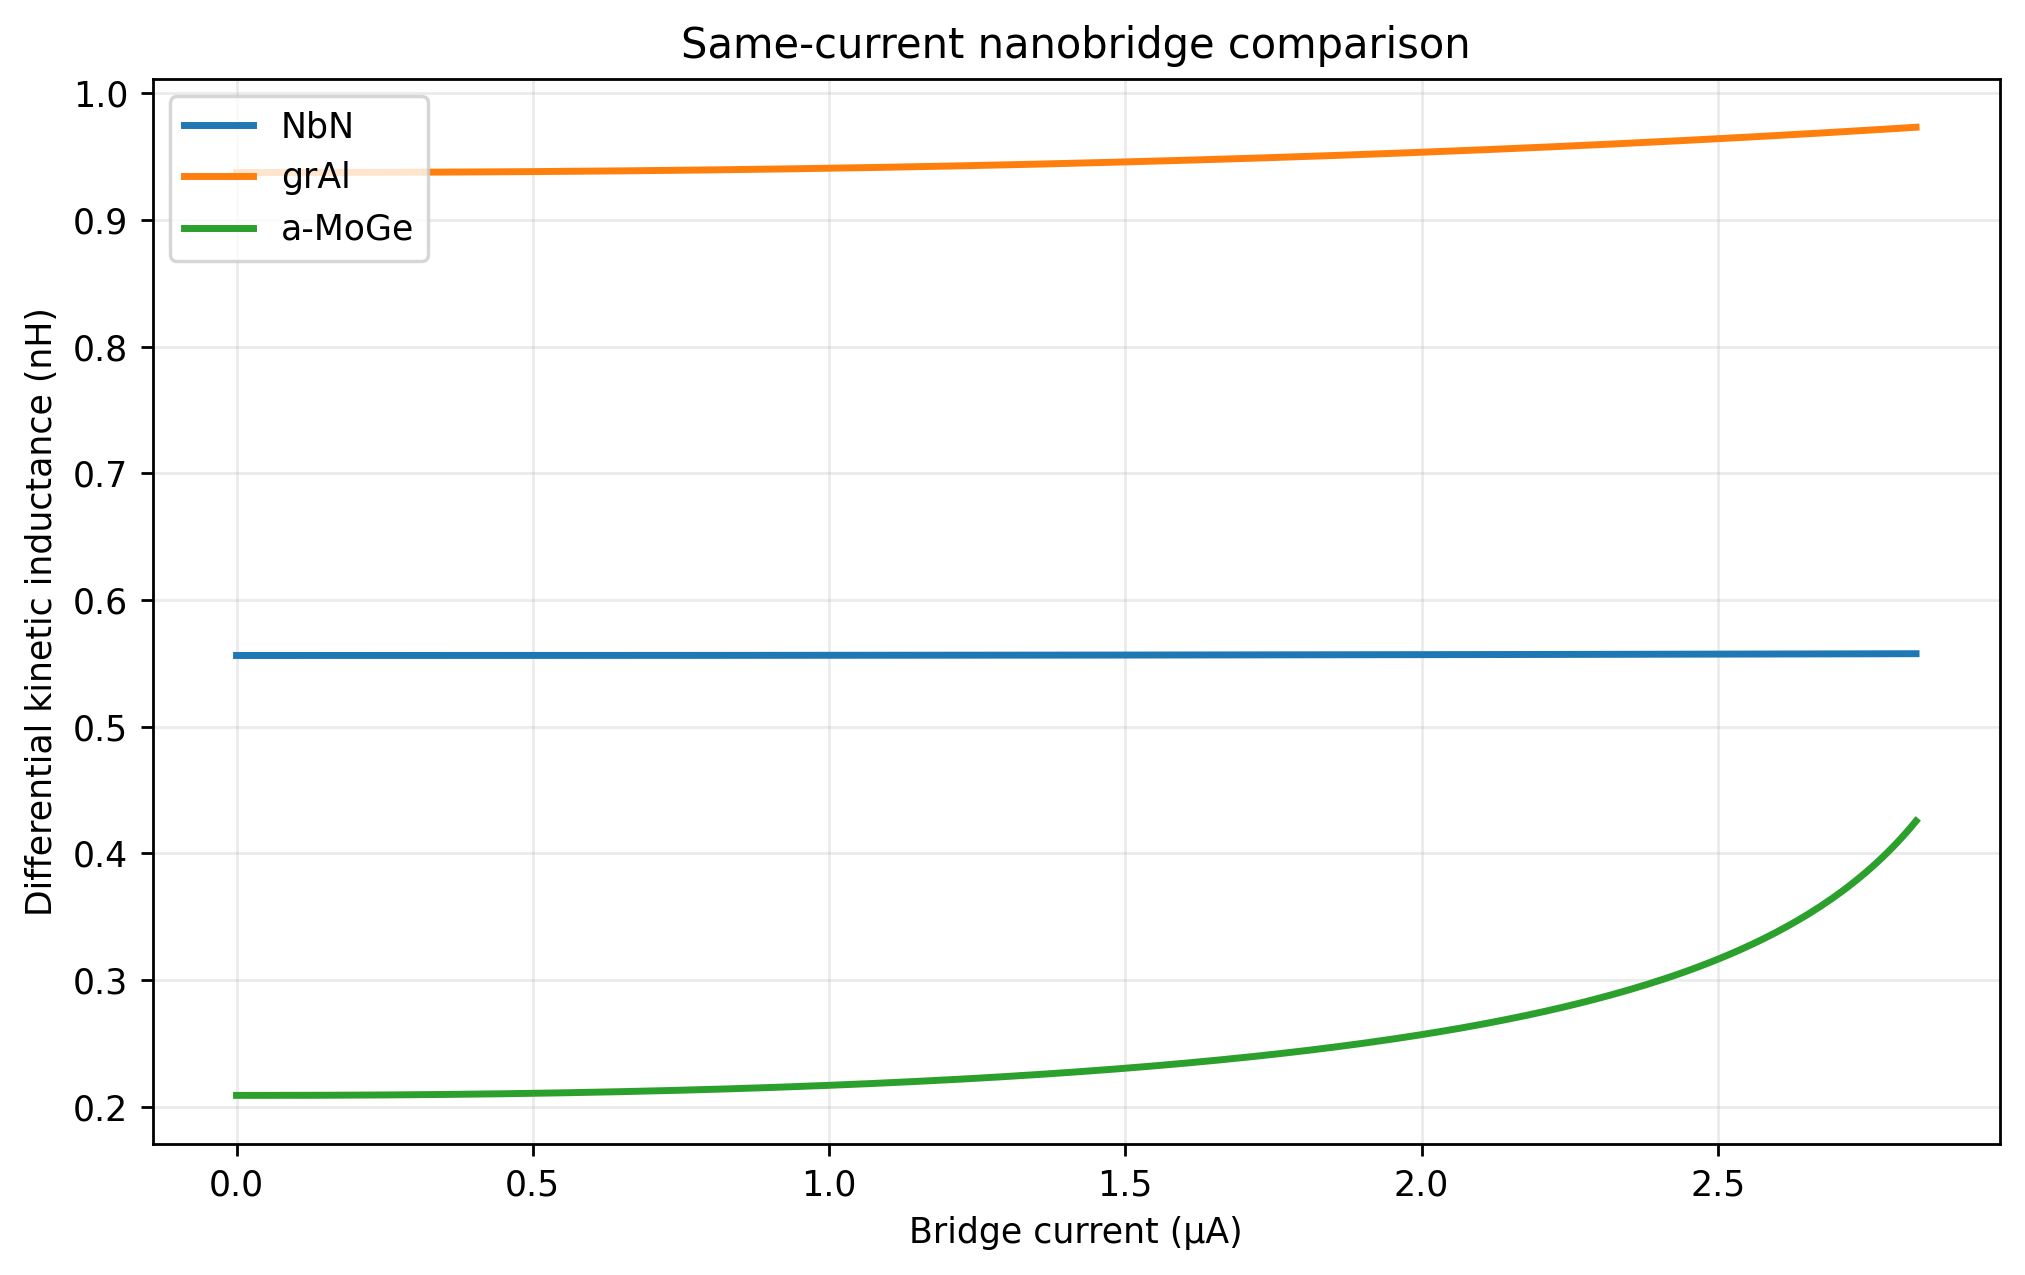

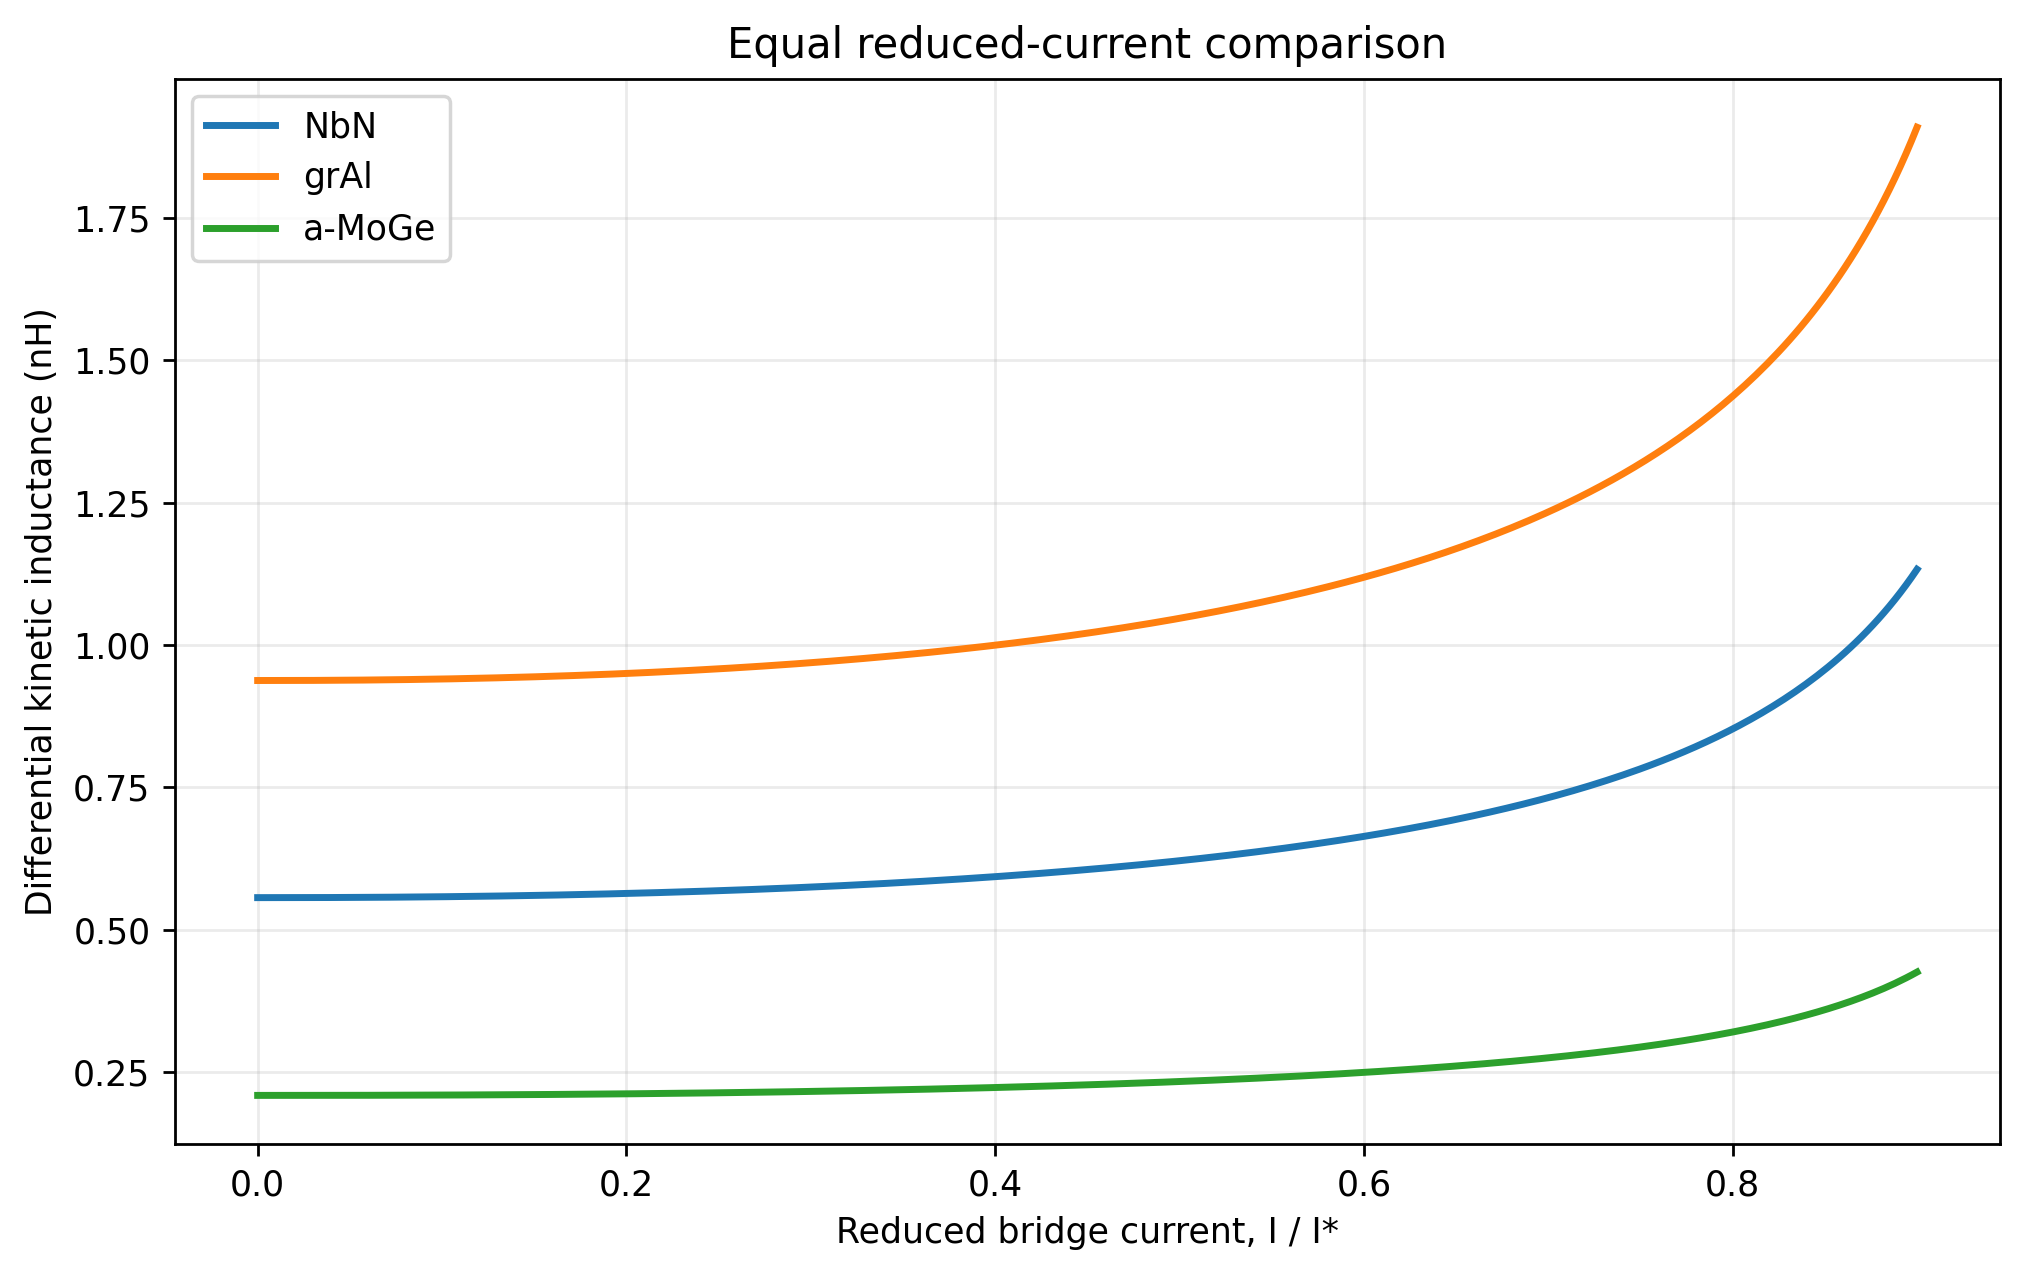

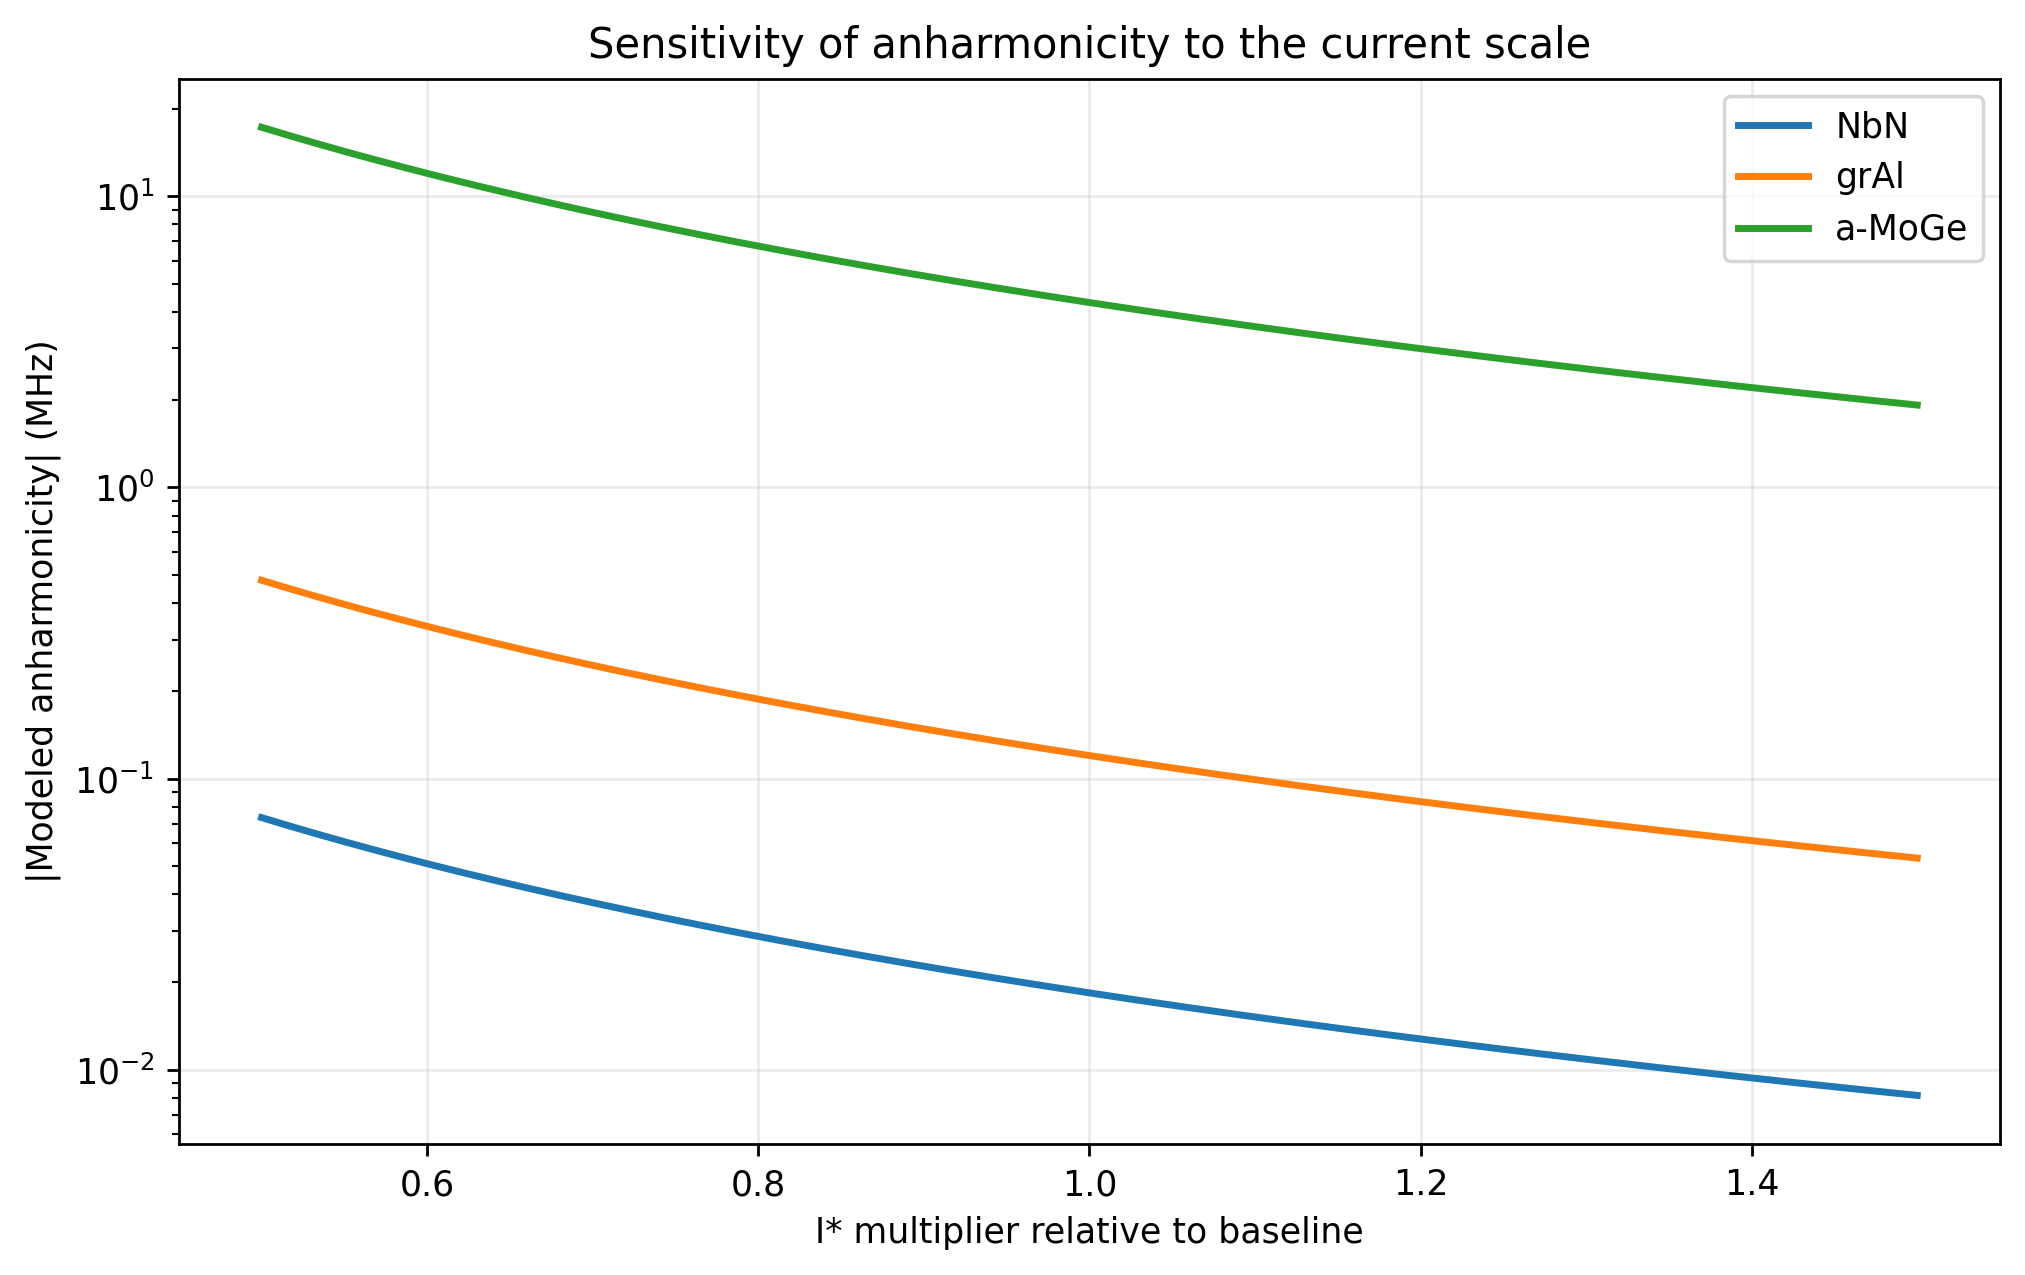

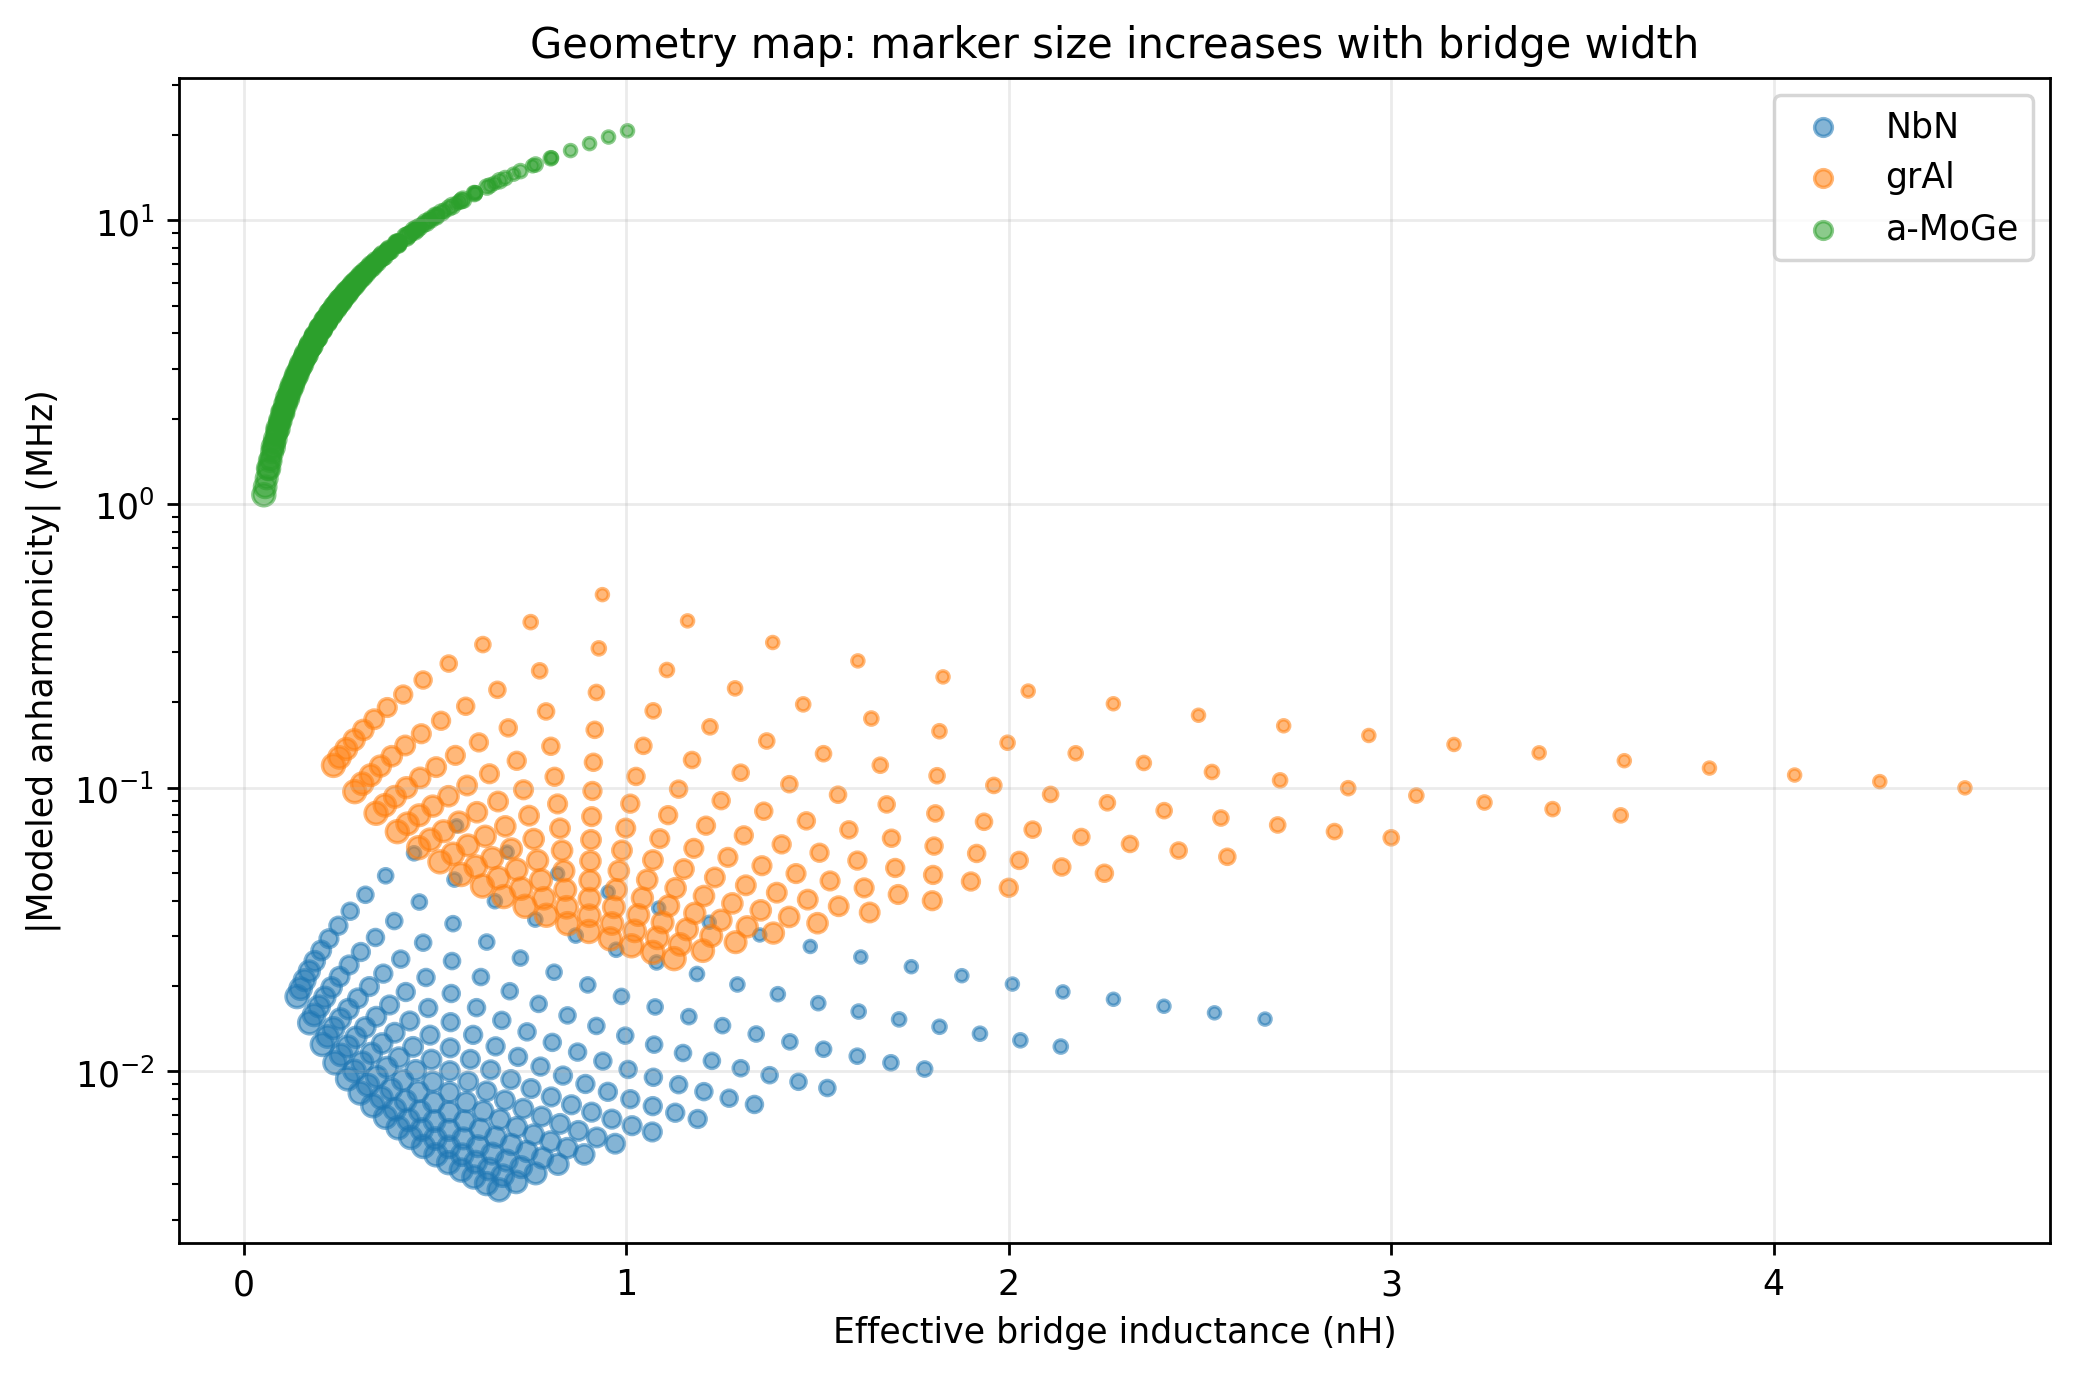

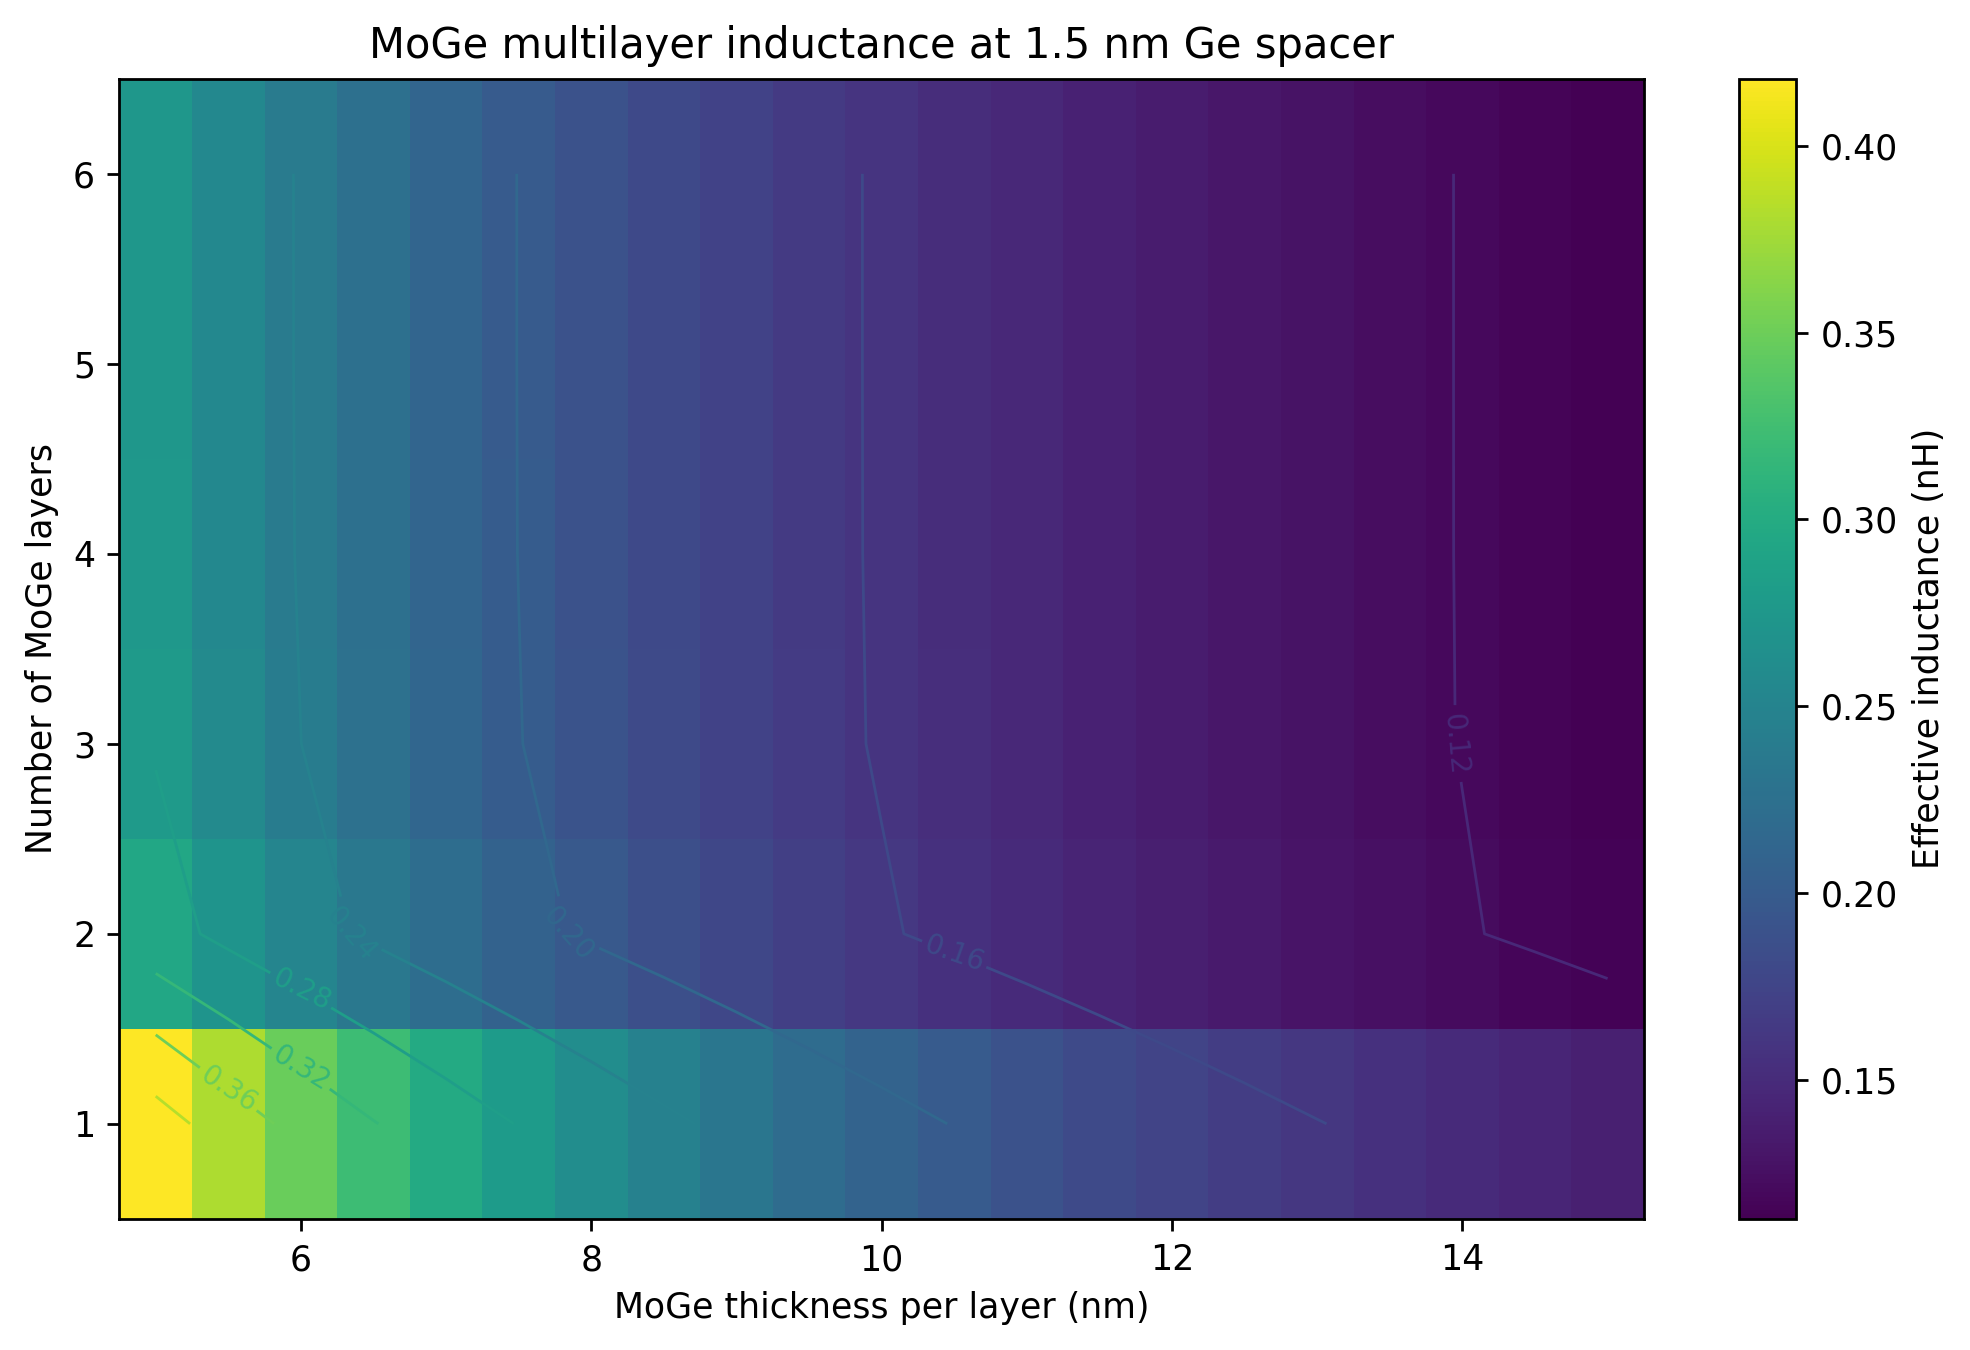

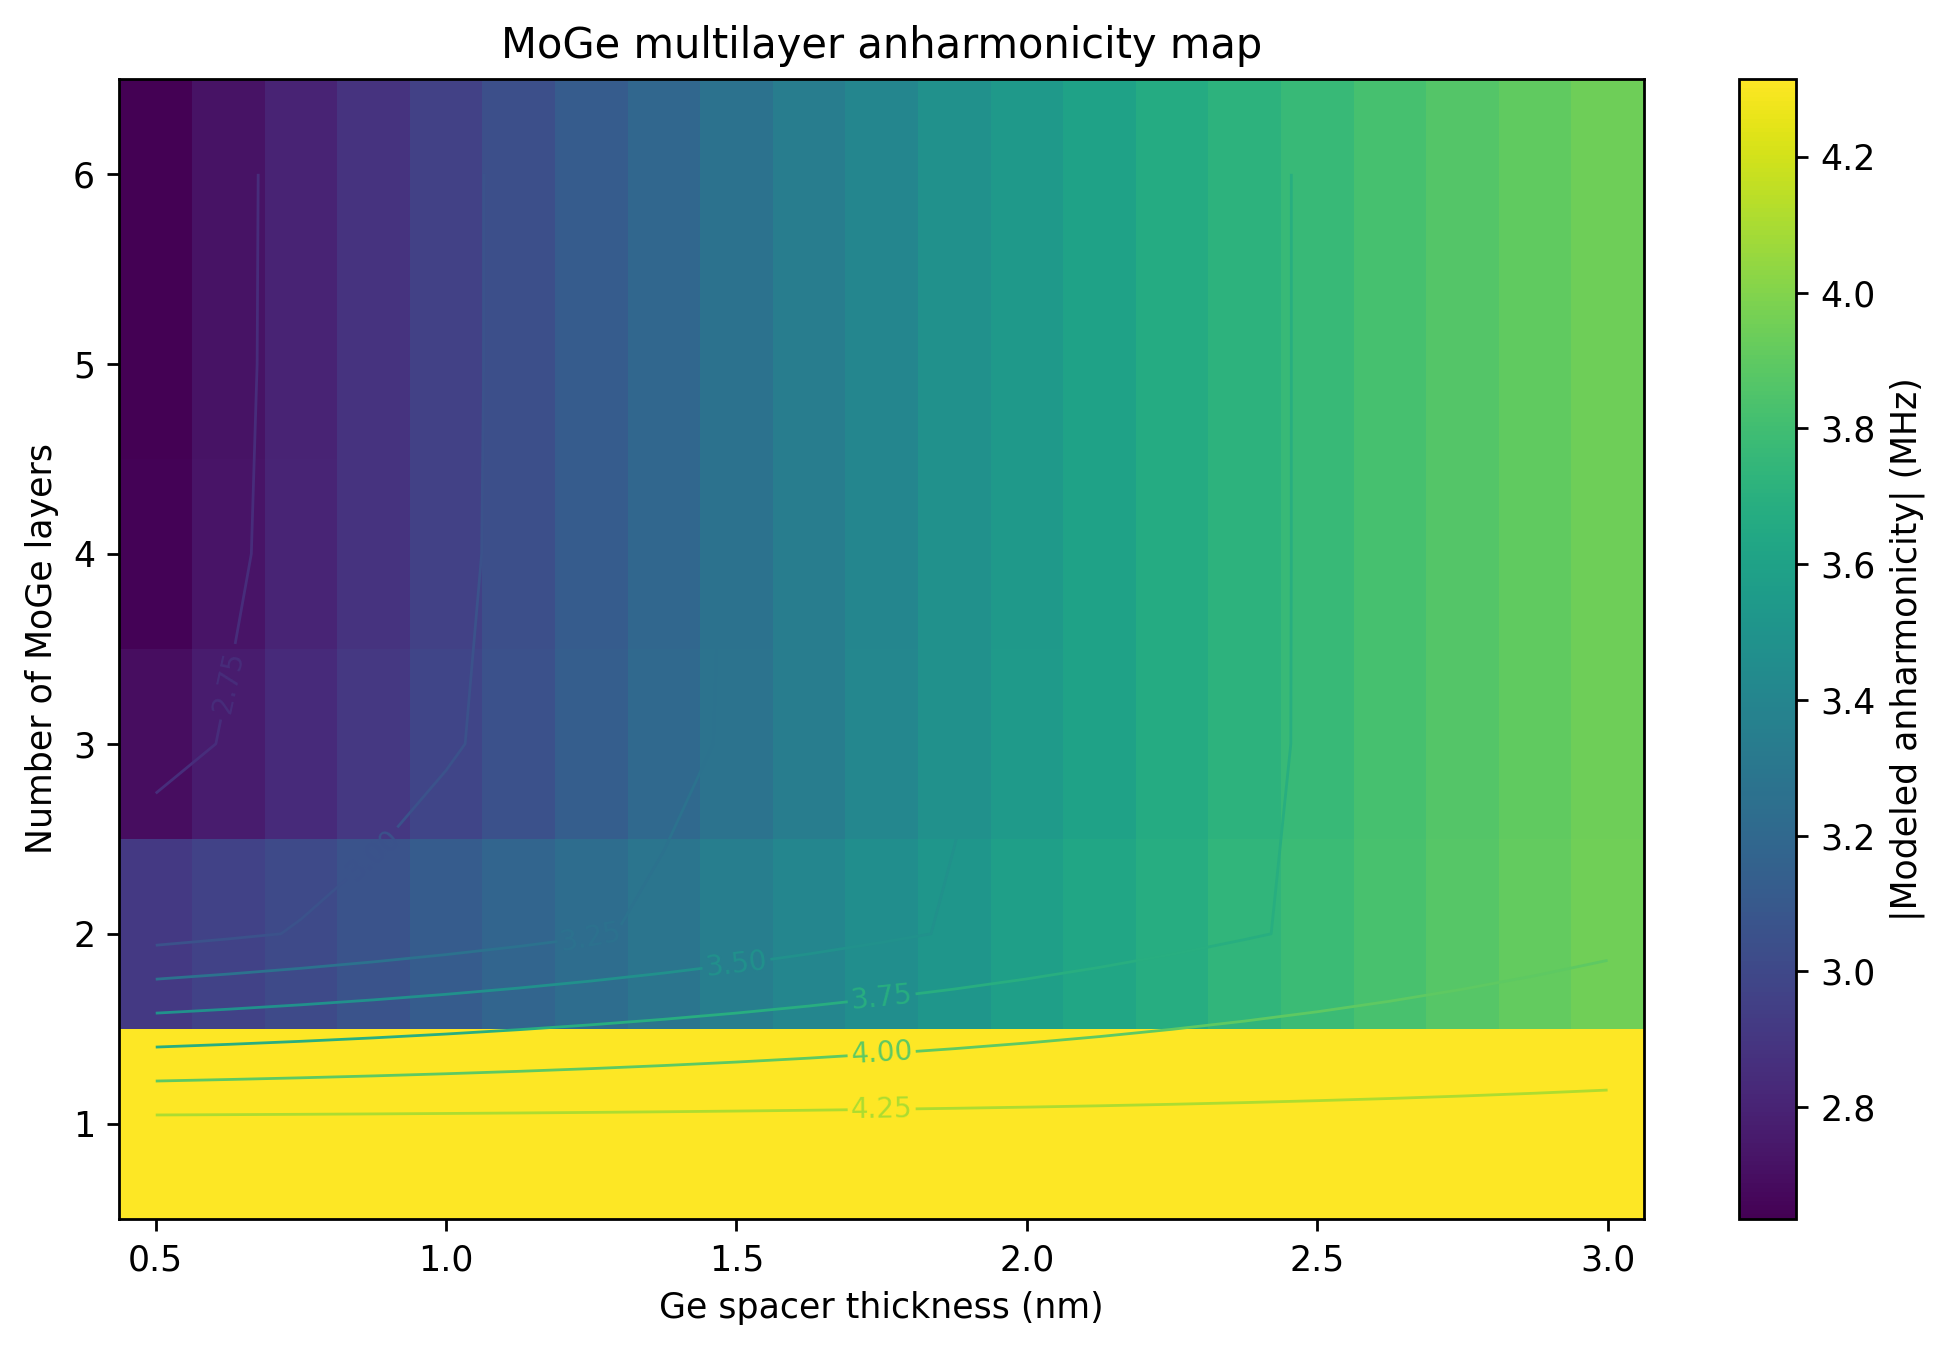

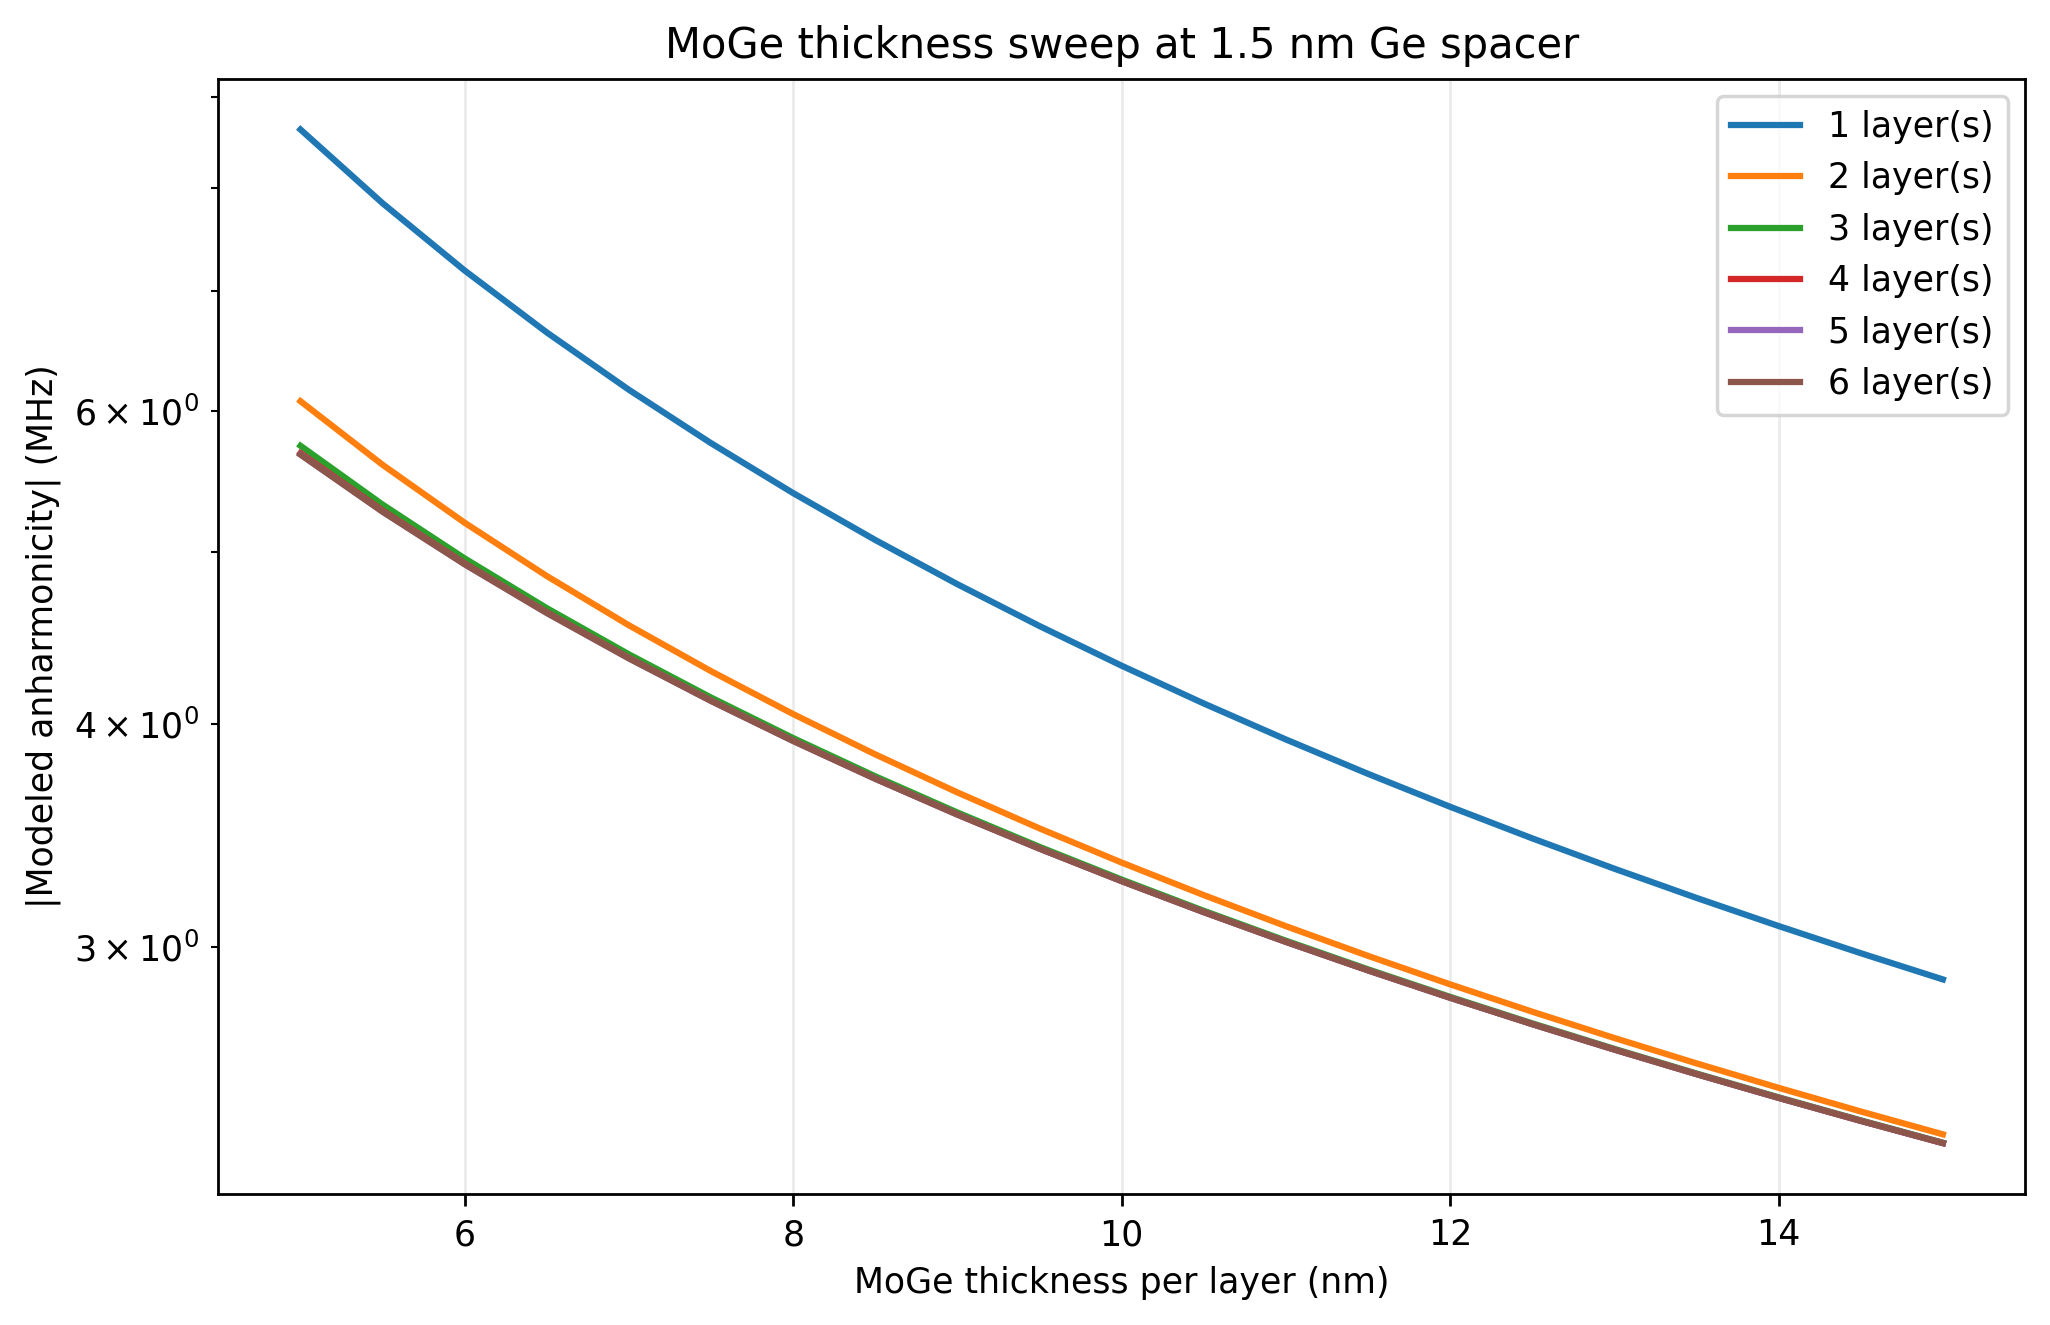

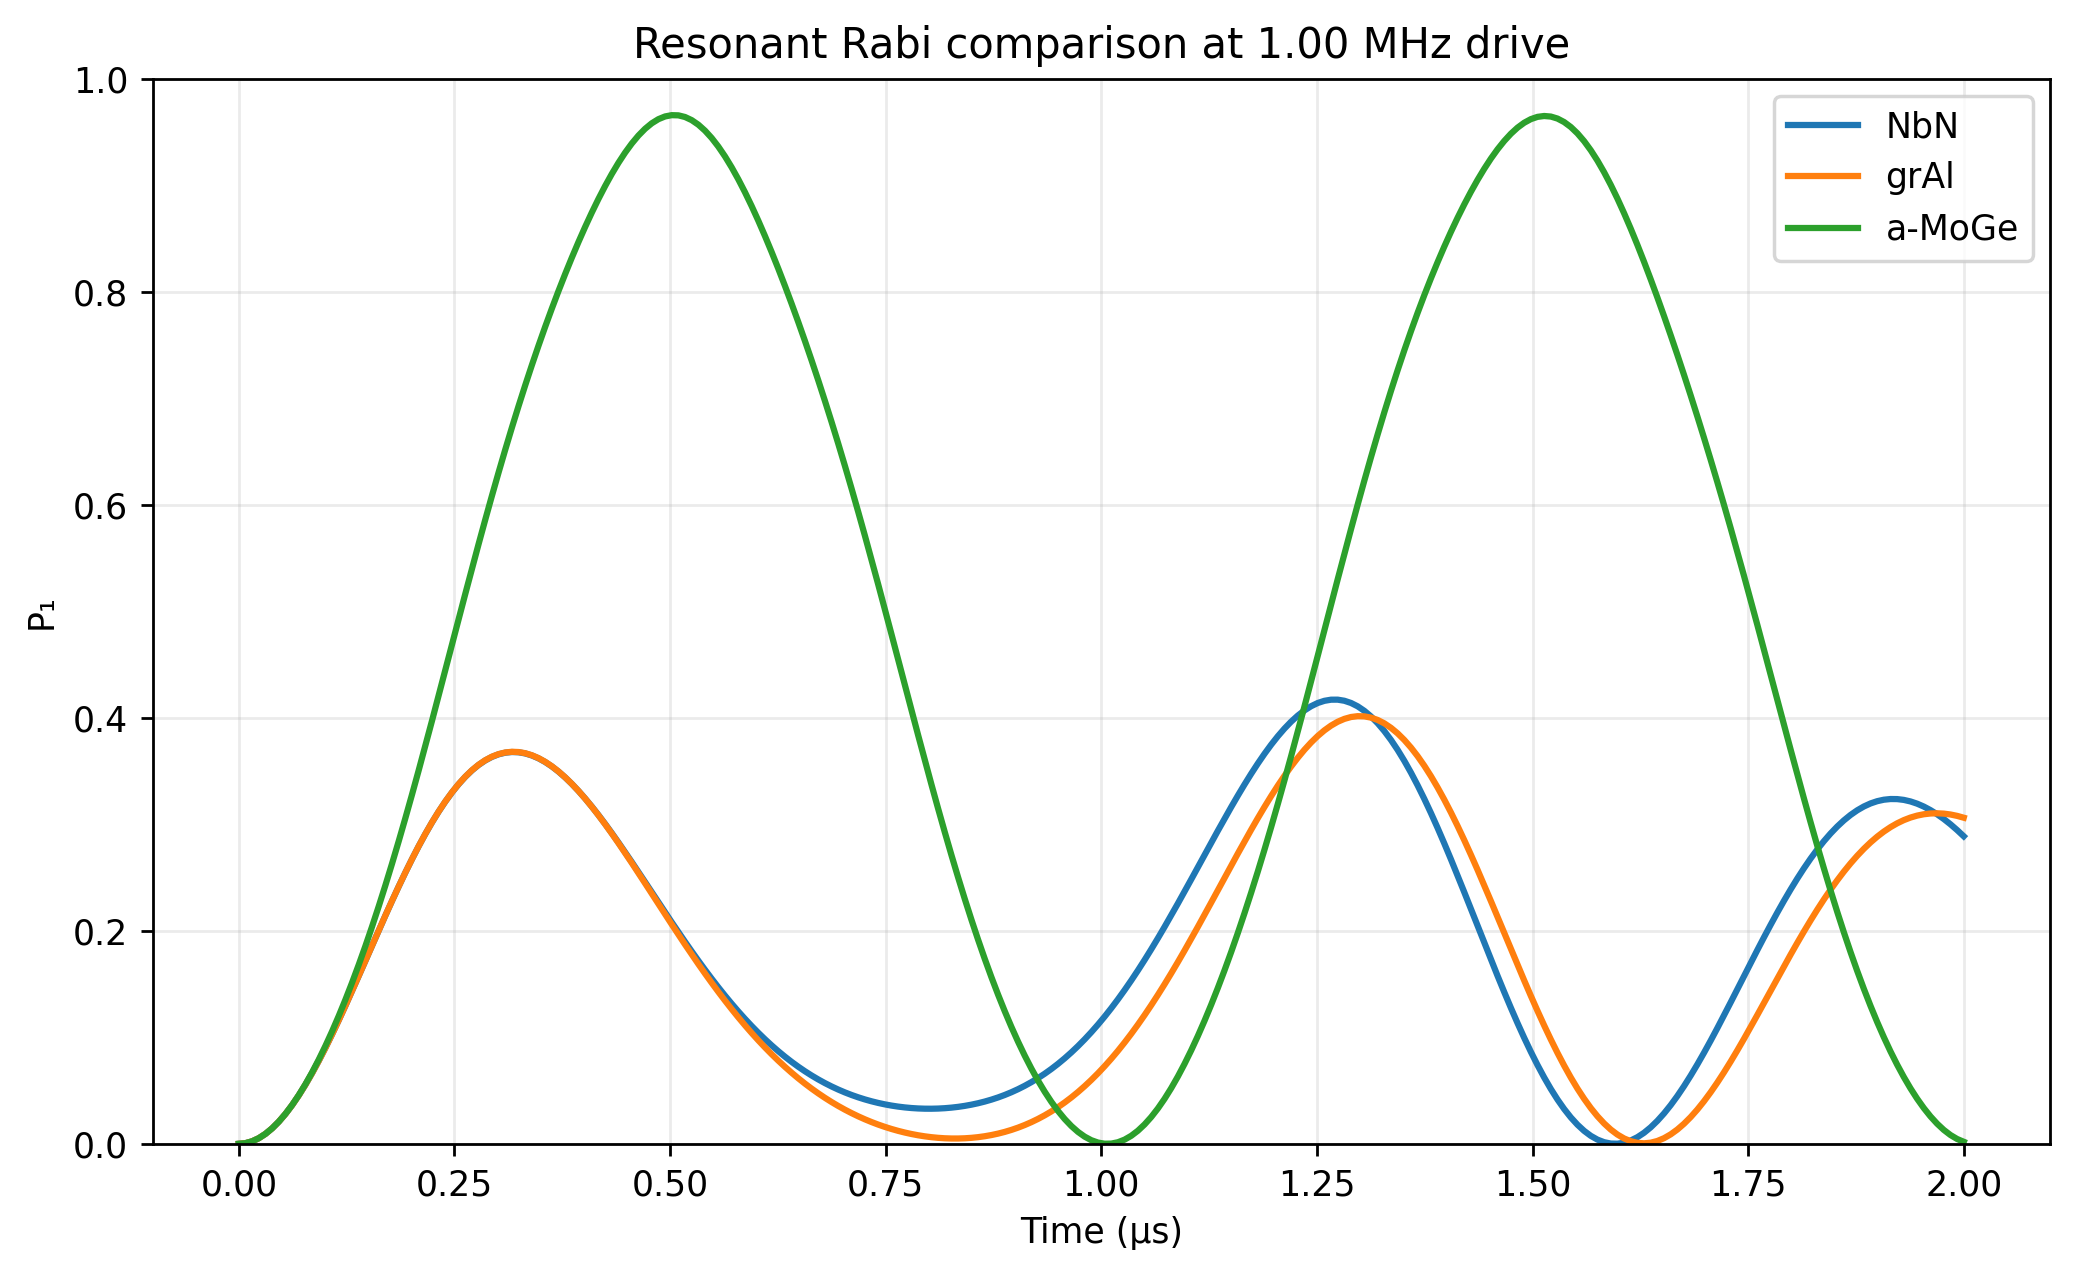

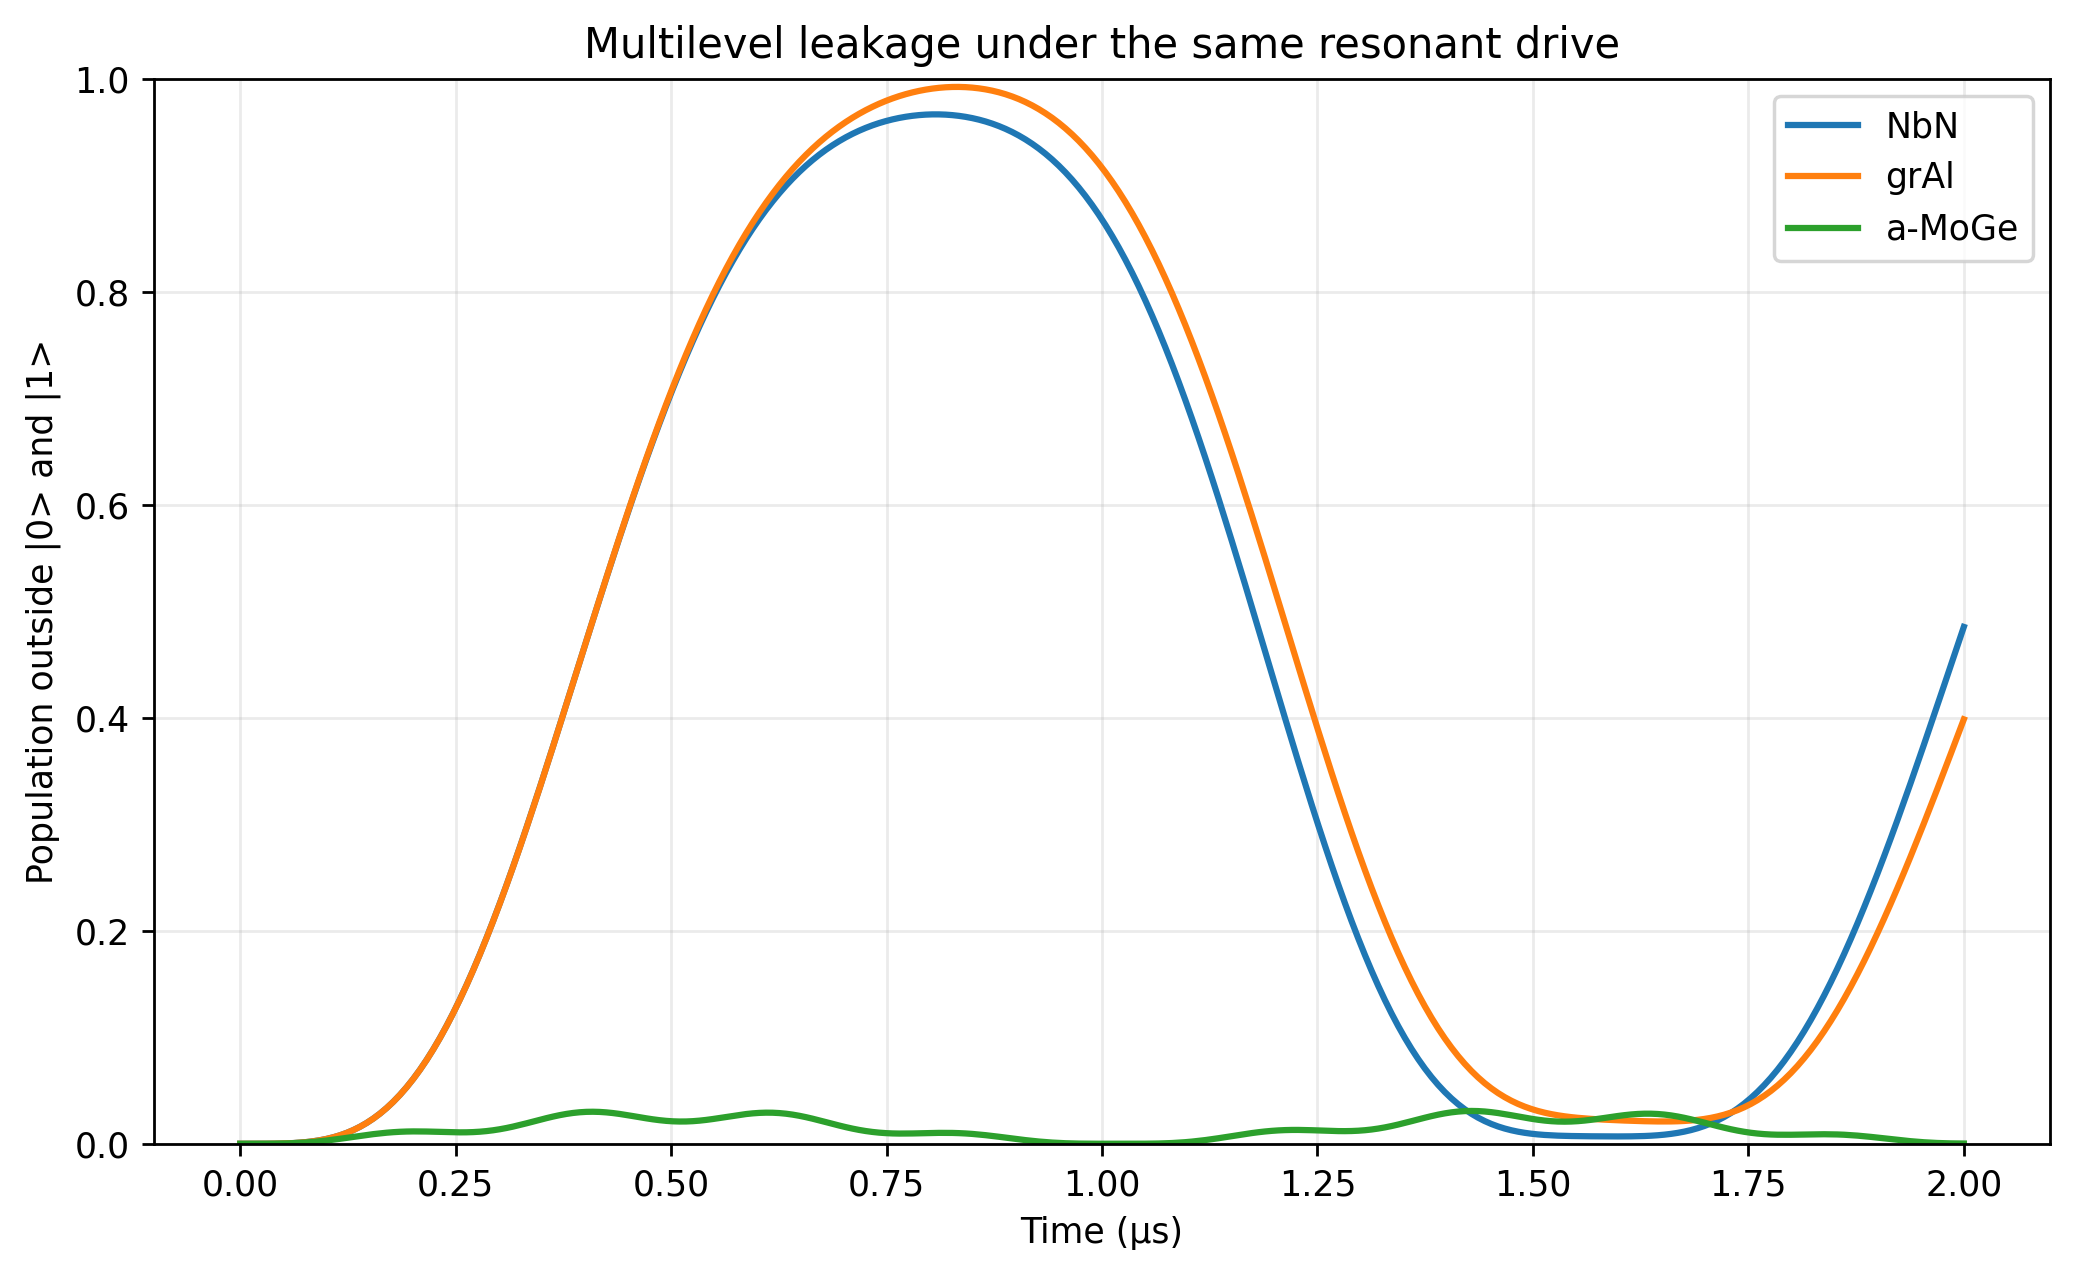

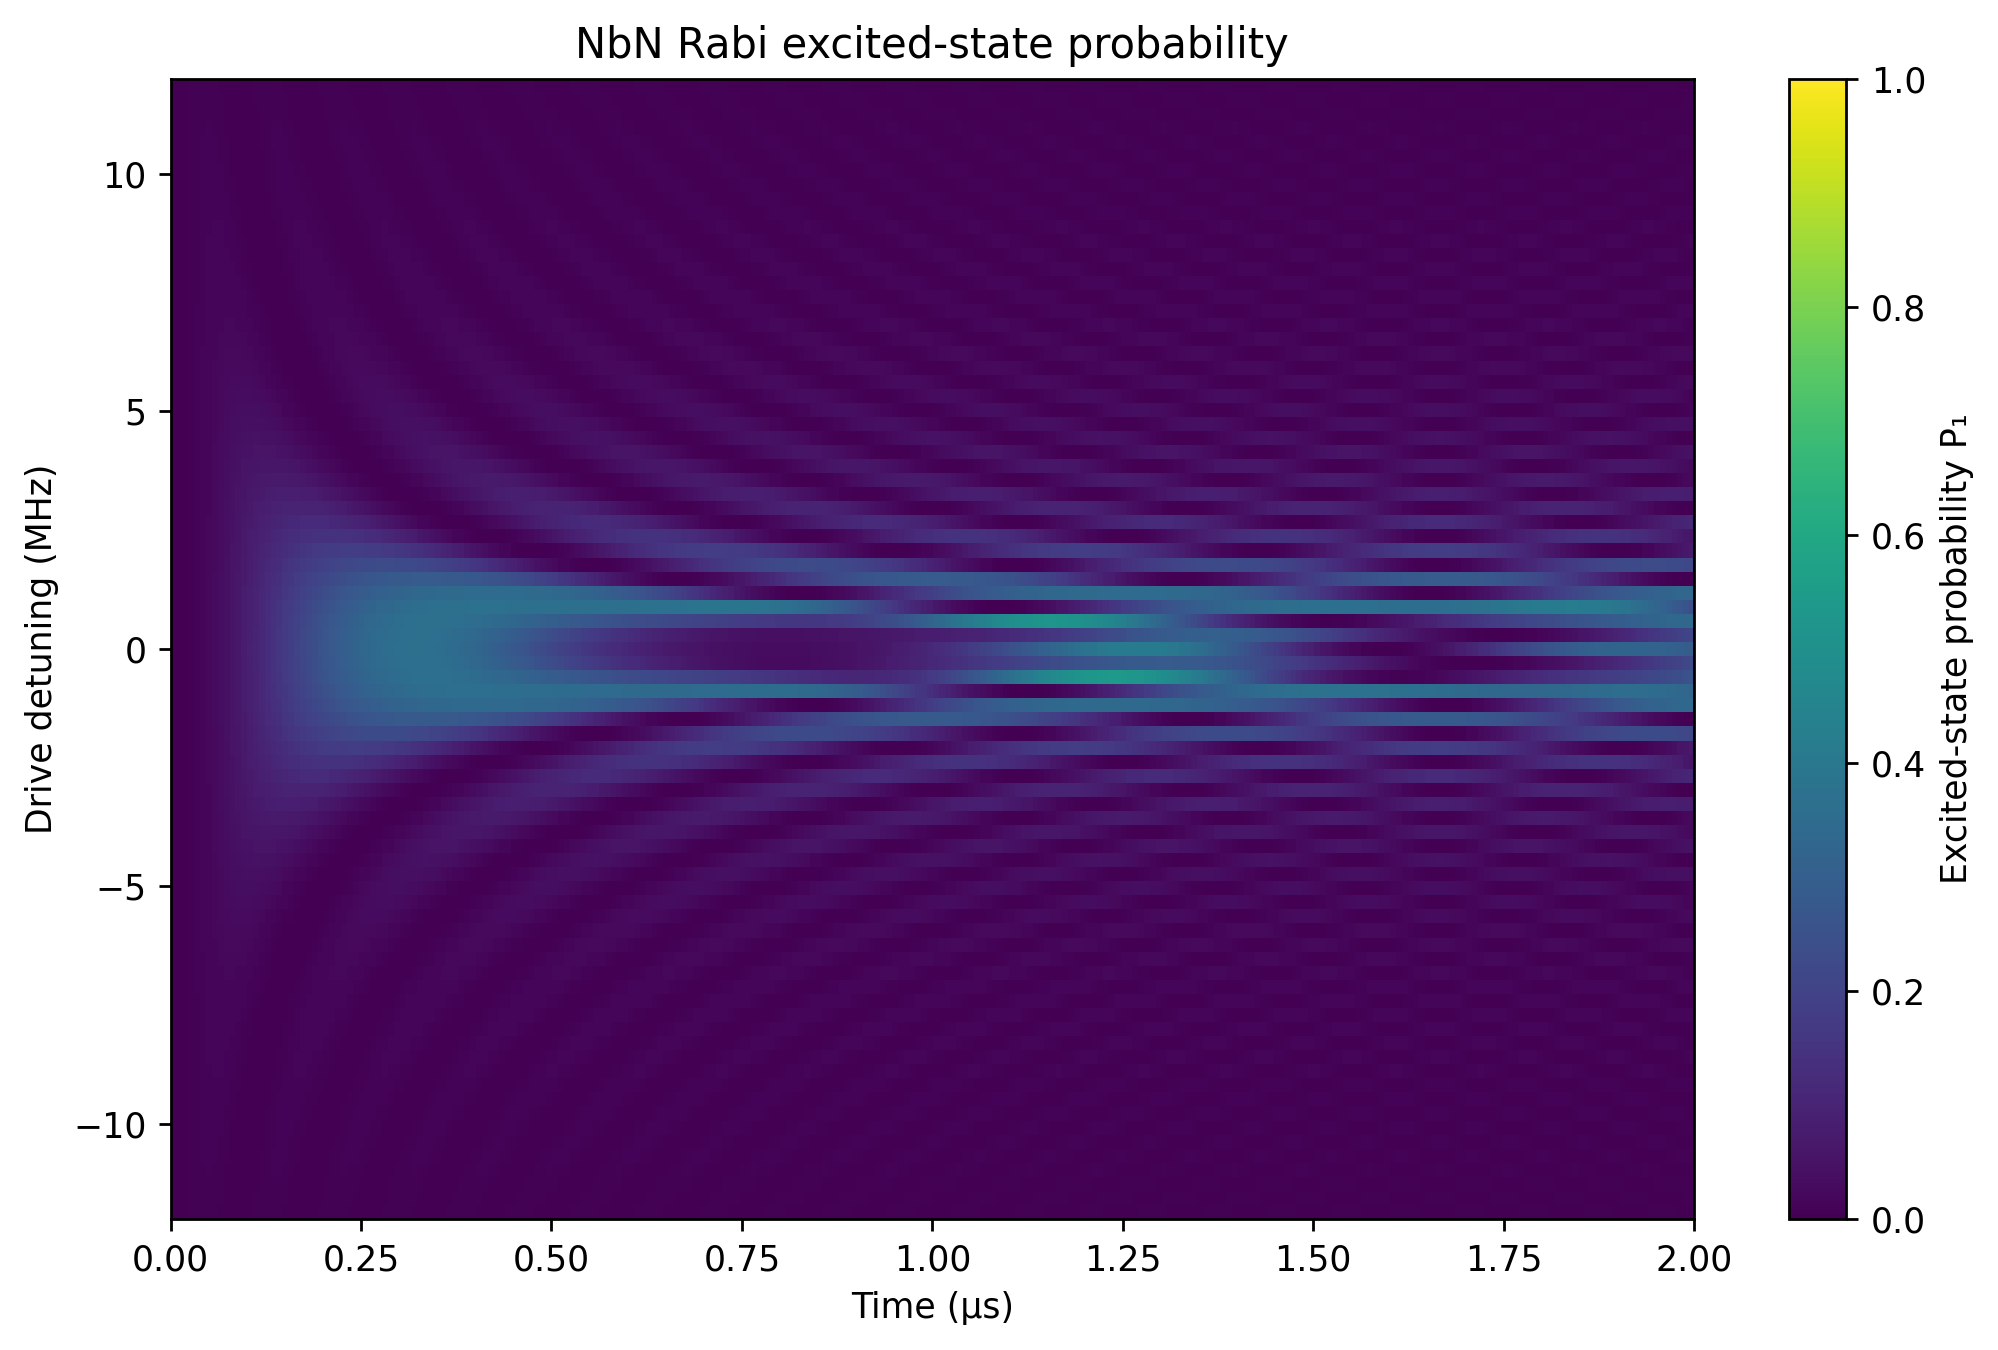

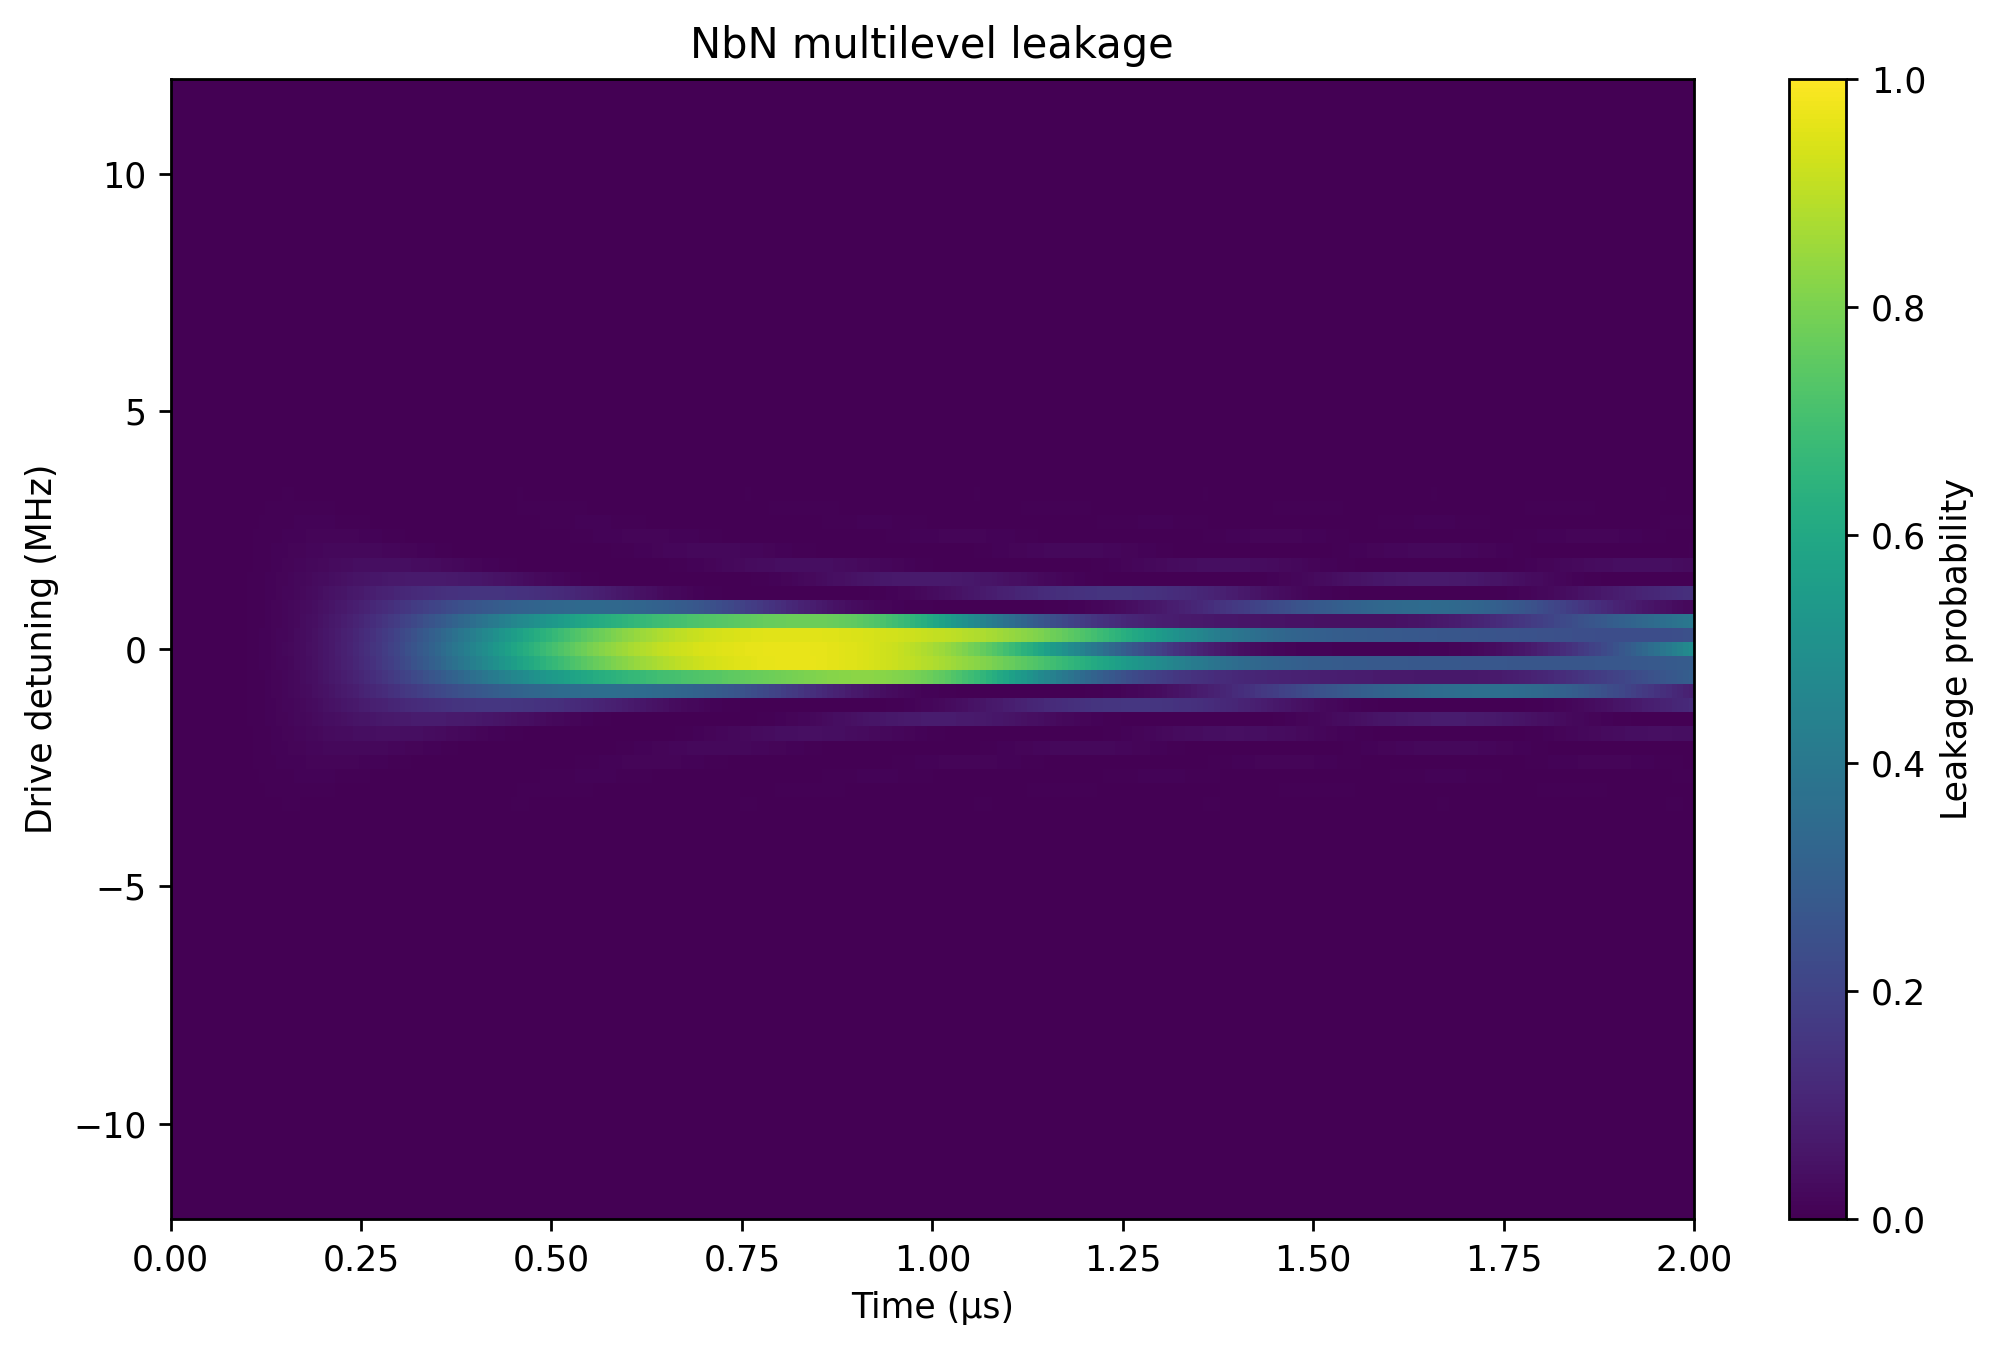

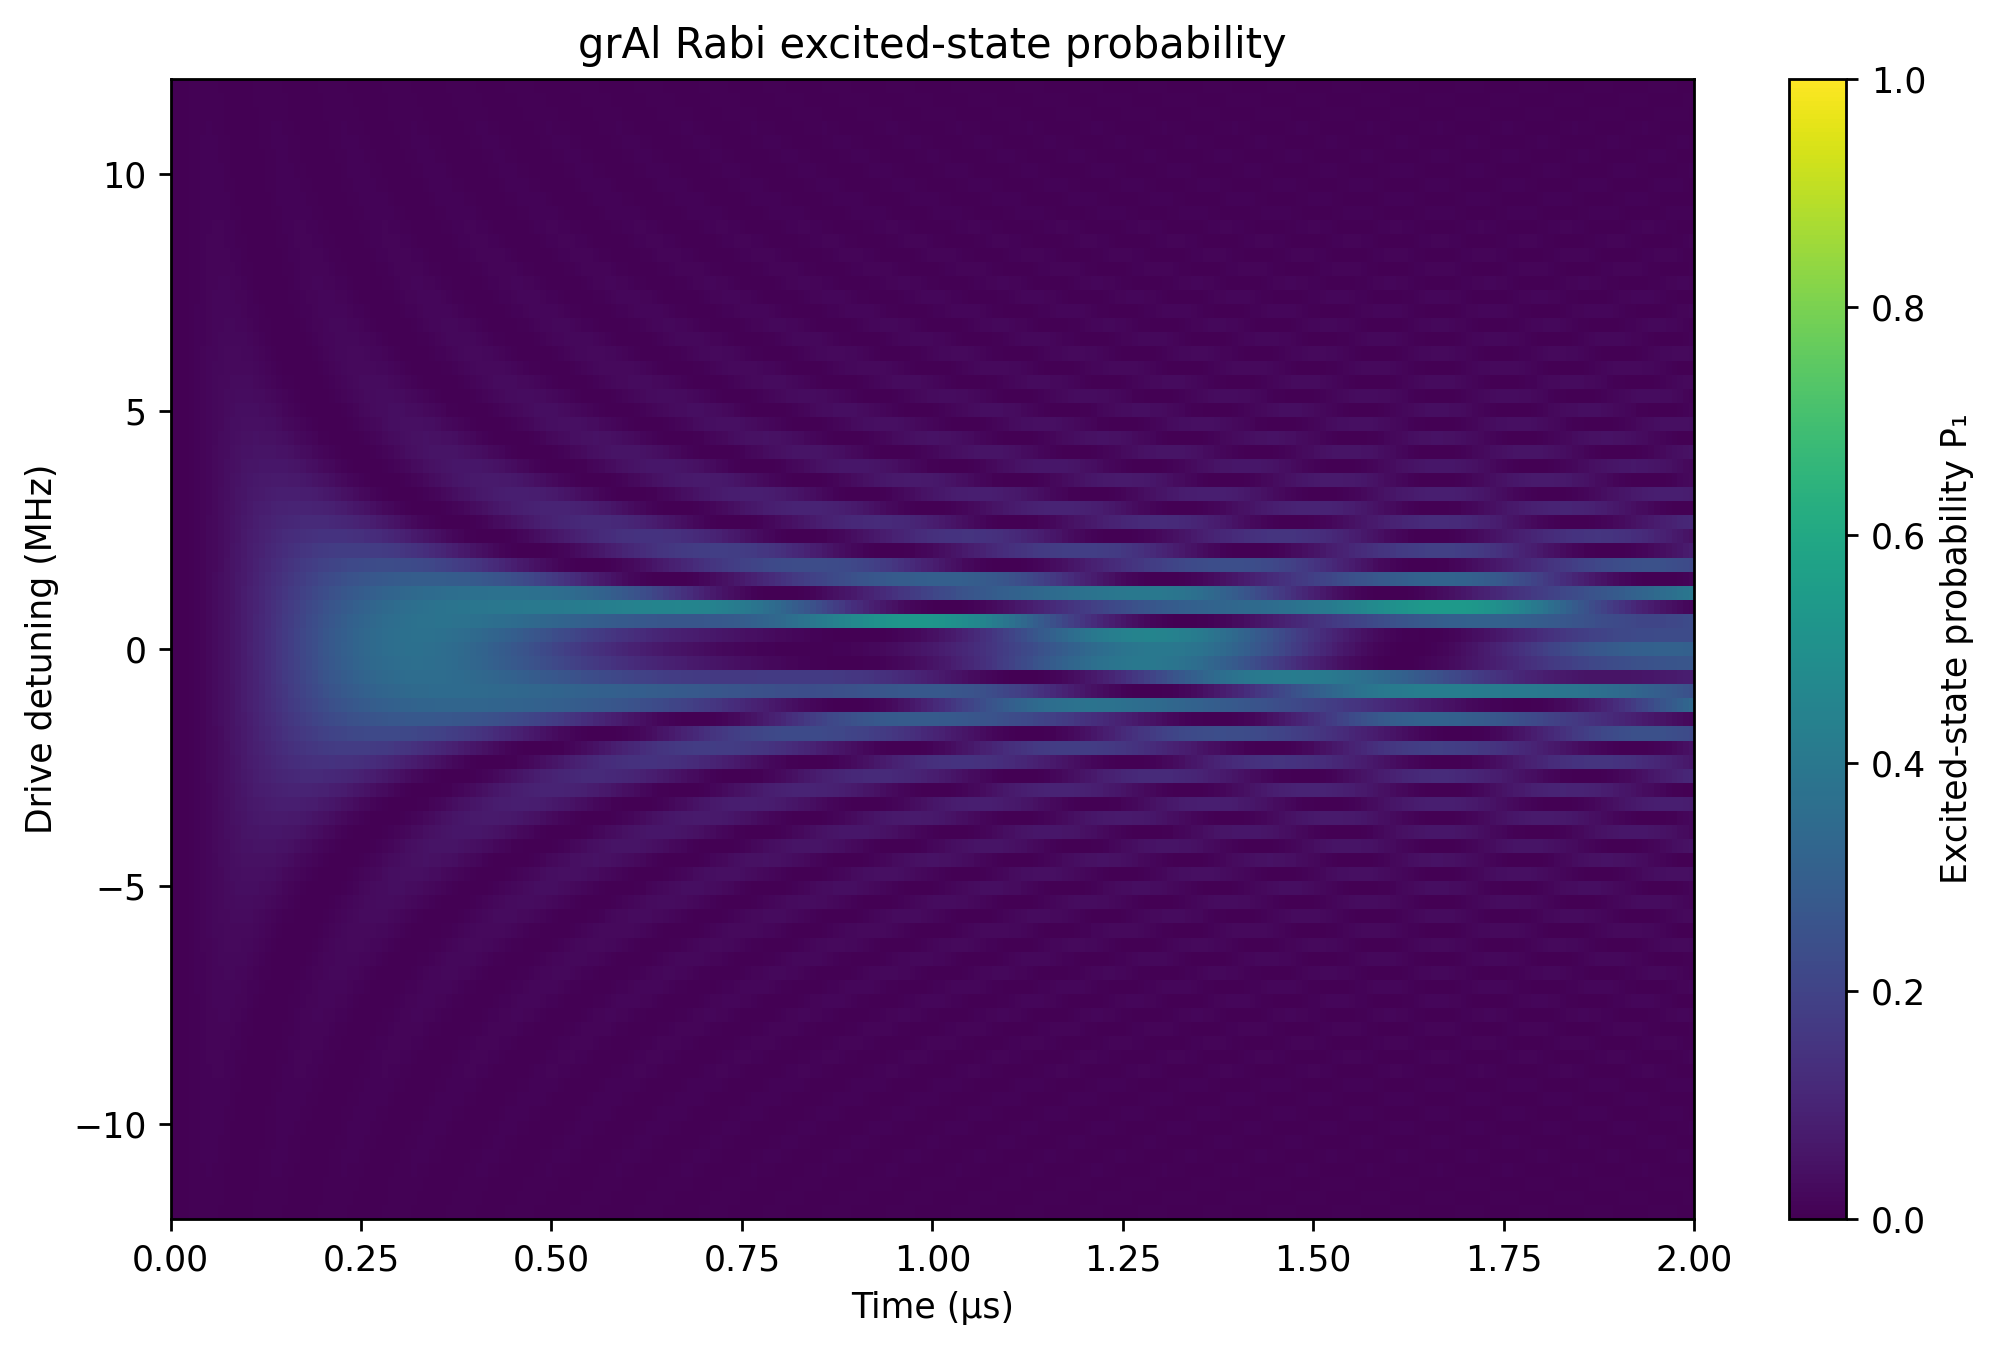

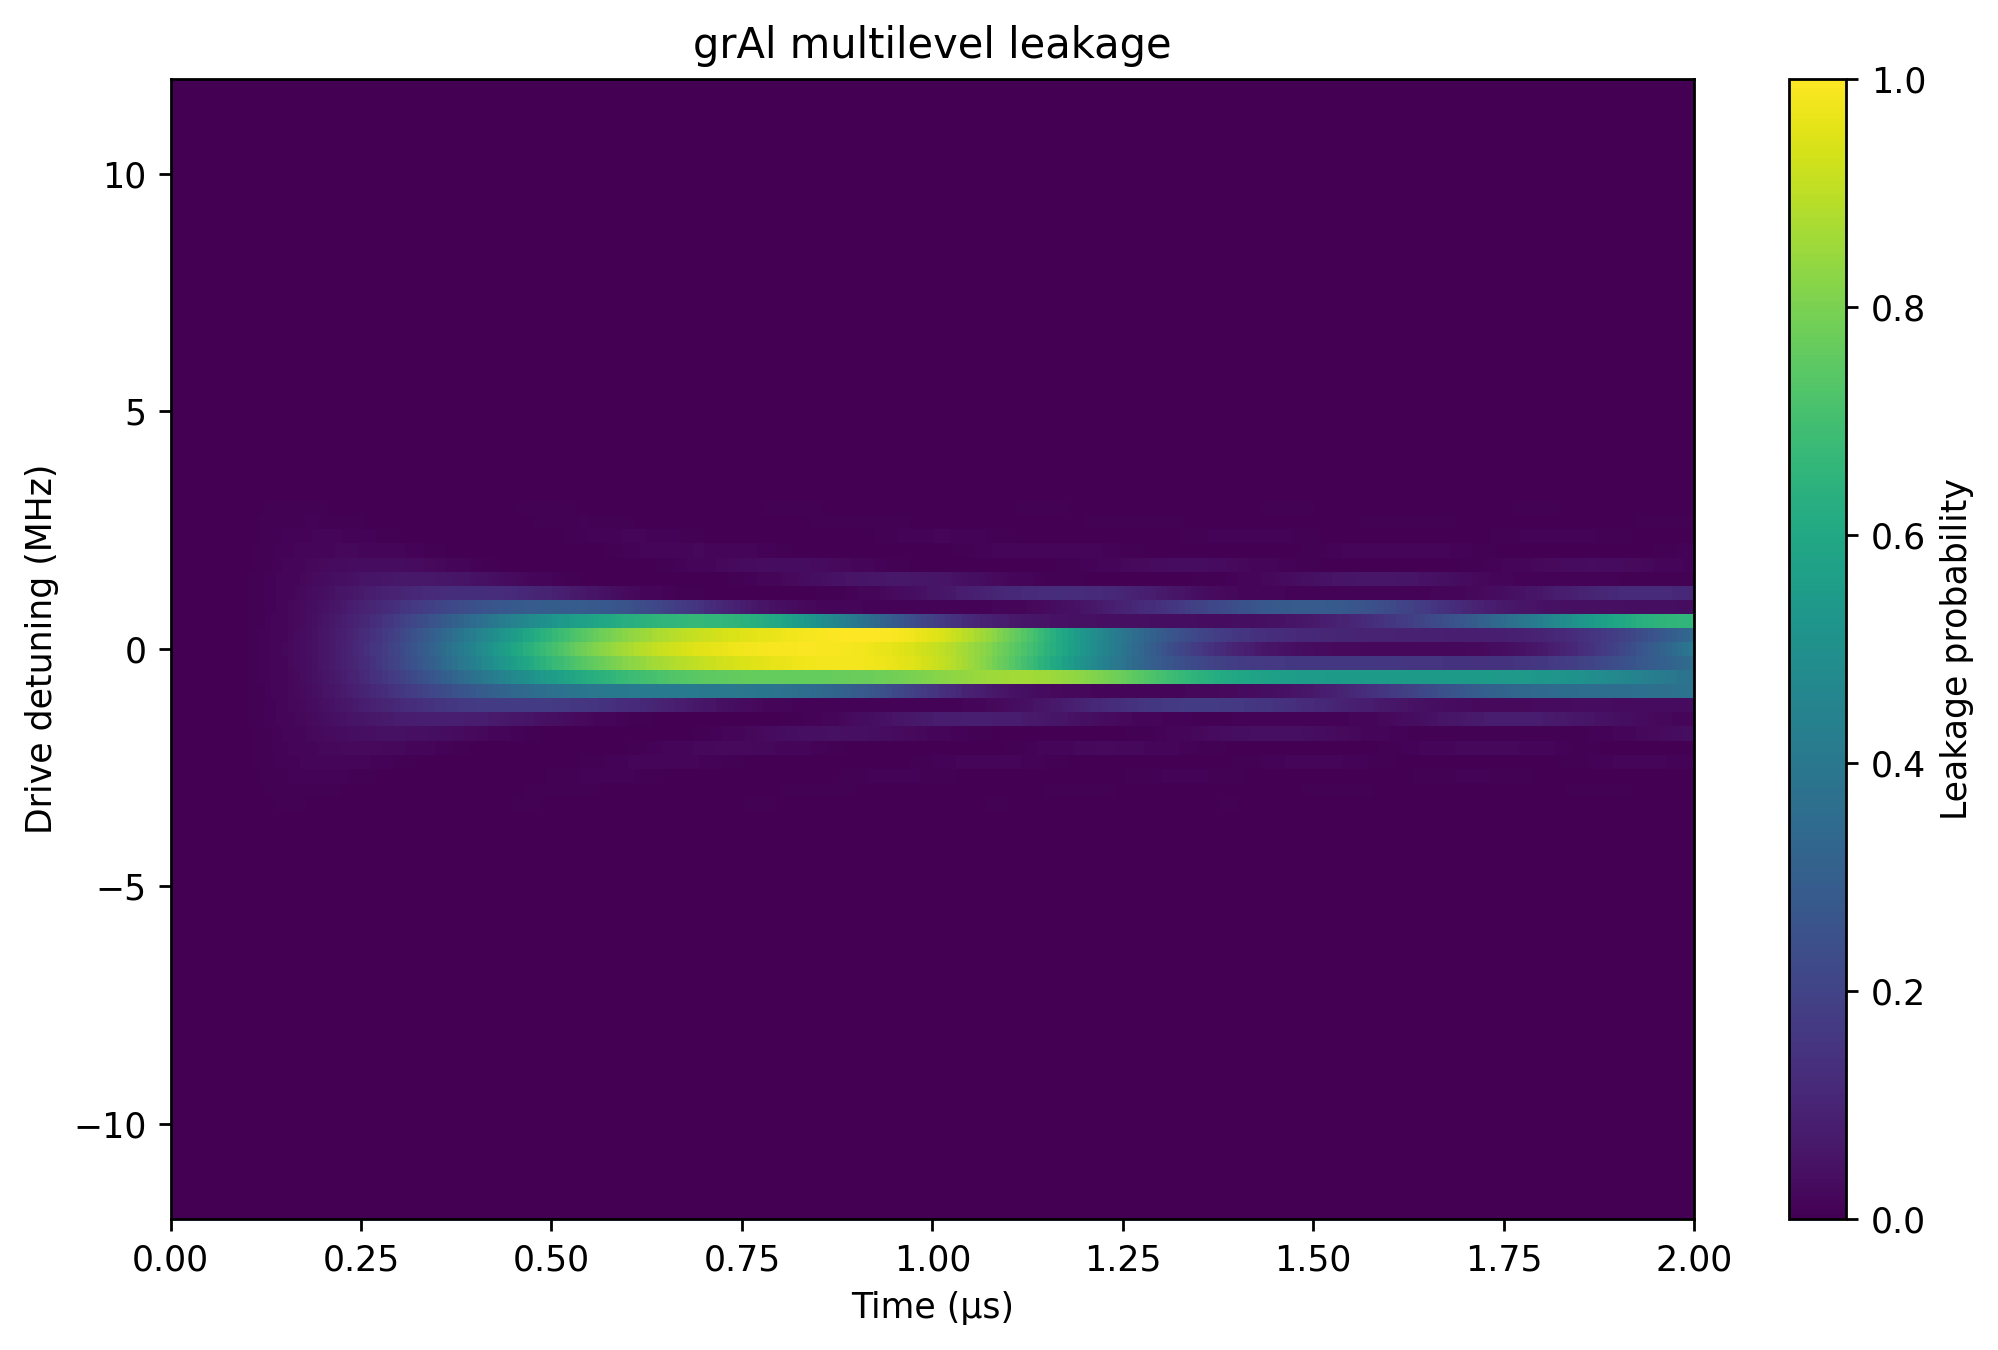

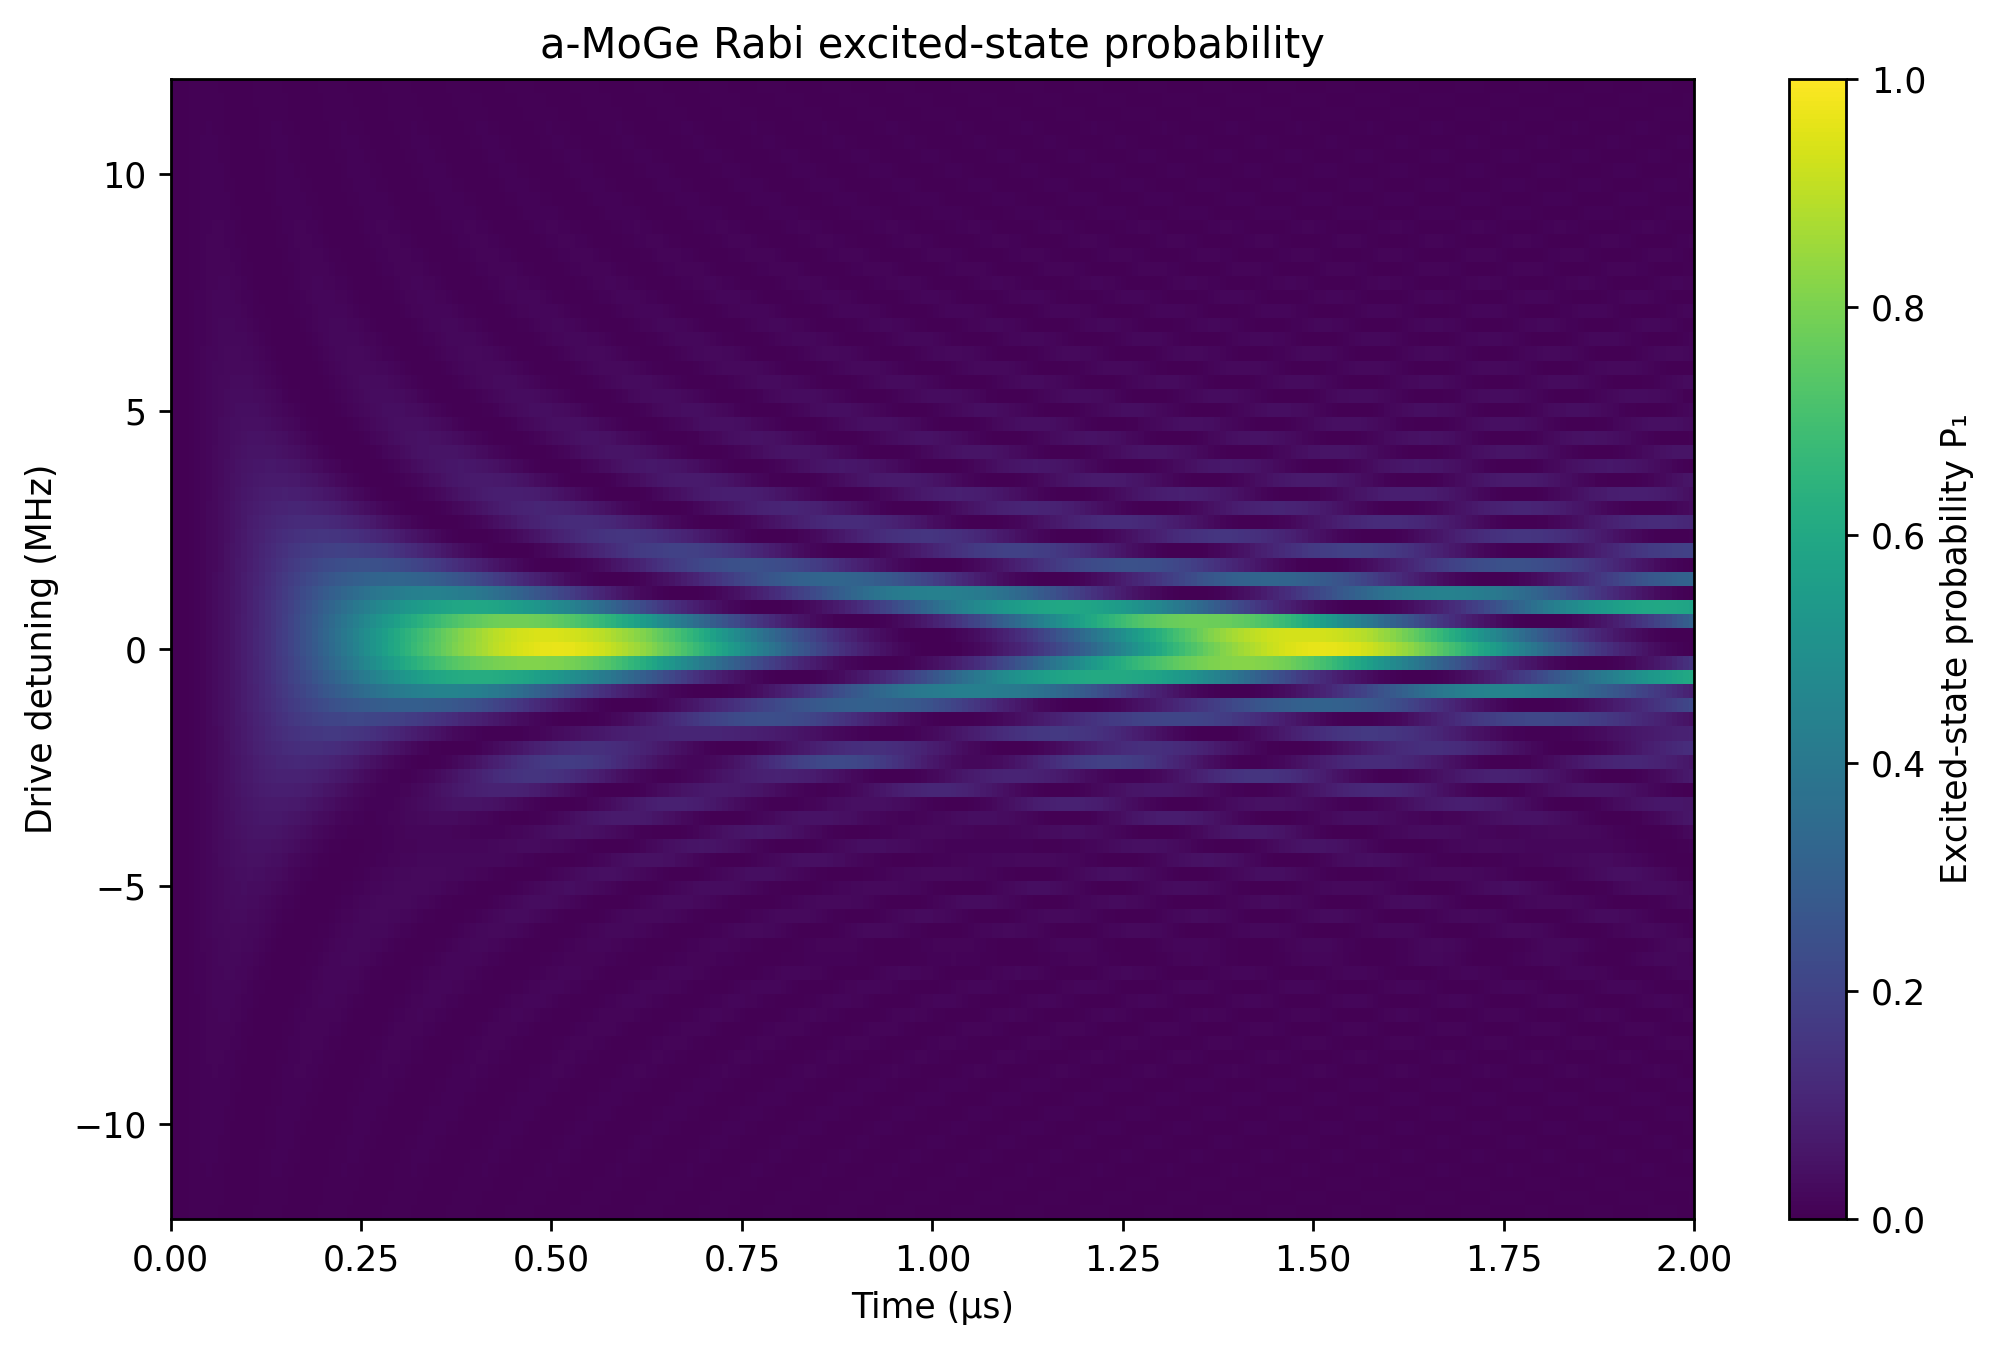

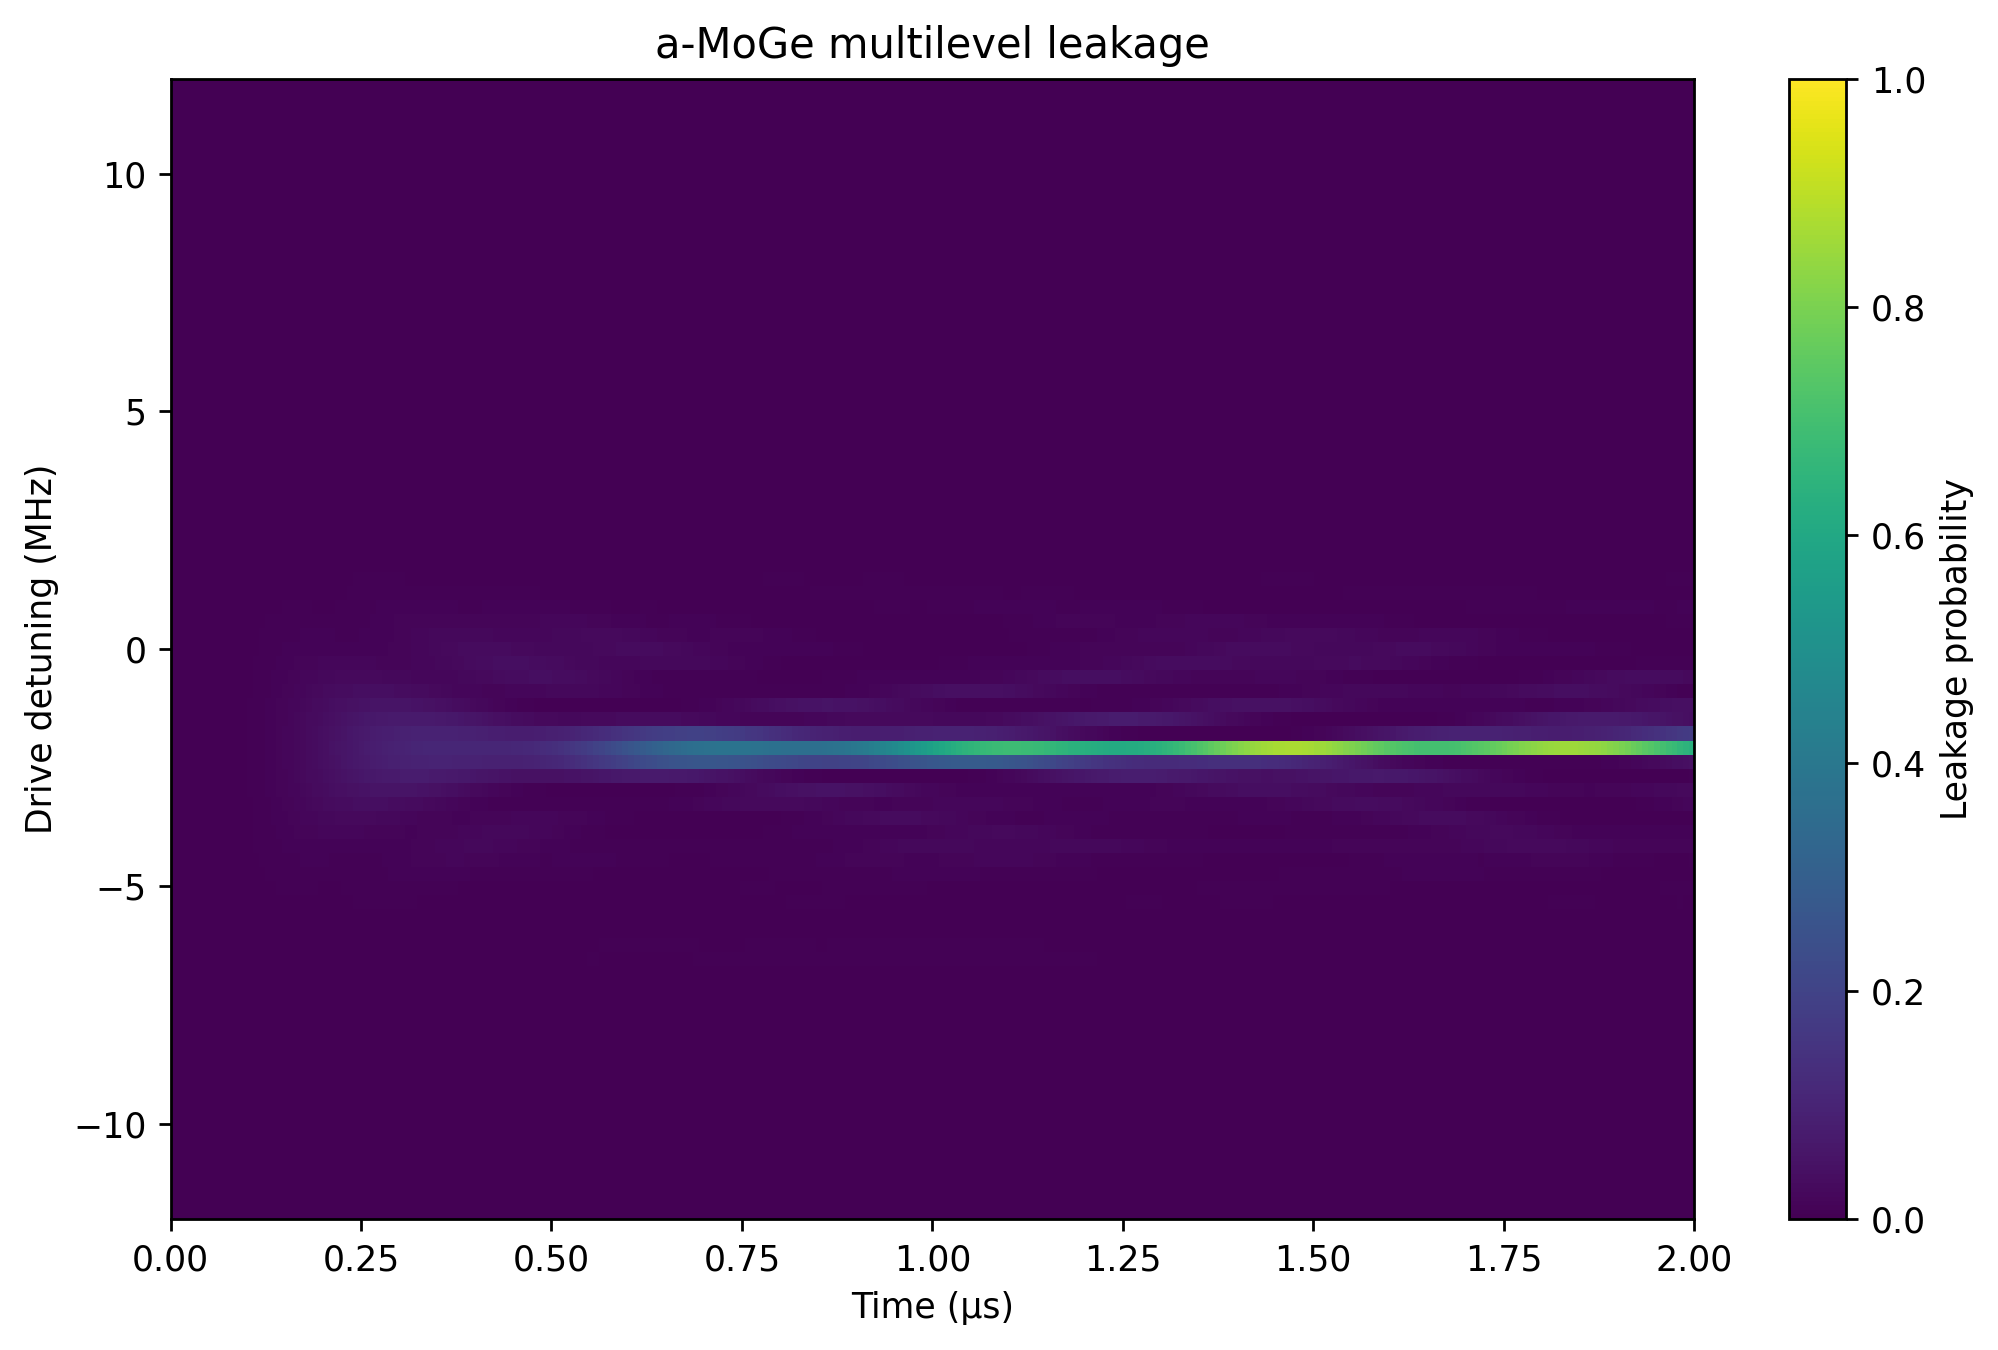

In [9]:
"""Compare nanobridge qubit material platforms with research-anchored models.

This combines dirty-limit kinetic-inductance estimates, a sparse
adjacency-network solver, a low-temperature nonlinear kinetic-inductance
relation, BCS Kerr estimates, MoGe multilayer sweeps, and QuTiP dynamics.

The baseline comparison distinguishes literature-anchored inputs from
geometry-scaled quantities and model-derived quantities.
"""

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from qutip import basis, destroy, sesolve
from scipy import sparse
from scipy.sparse import linalg as sparse_linalg

# -----------------------------------------------------------------------------
# CONTROL KNOBS
# -----------------------------------------------------------------------------

USE_CUPY = True
PLOT_DPI = 250

TARGET_FREQUENCY_GHZ = 6.0
TARGET_CAPACITANCE_FF = 100.0

BRIDGE_LENGTH_NM = 500.0
BRIDGE_WIDTH_NM = 80.0

GRID_NX = 16
GRID_NY = 6

# Low-temperature nonlinear kinetic-inductance exponent used in the
# Clem-Kogan relation and adopted in the 2025 NbN/grAl comparison.
NONLINEAR_EXPONENT = 2.21

# Maximum fraction of I_star used for nonlinear current plots.
MAXIMUM_BIAS_FRACTION = 0.90

# NbN literature anchors from the 2025 NbN/grAl comparison.
NBN_LK_SHEET_PH_SQ = 89.0
NBN_FILM_THICKNESS_NM = 13.0
NBN_REFERENCE_WIDTH_NM = 200.0
NBN_REFERENCE_I_STAR_UA = 74.0

# grAl literature anchors from the same comparison.
GRAL_LK_SHEET_PH_SQ = 150.0
GRAL_FILM_THICKNESS_NM = 50.0
GRAL_REFERENCE_WIDTH_NM = 200.0
GRAL_REFERENCE_I_STAR_UA = 22.3
GRAL_REFERENCE_I_SWITCH_UA = 6.8
GRAL_MEASURED_QUBIT_ALPHA_MHZ = 4.48

# a-MoGe dirty-limit inputs.
MOGE_RESISTIVITY_UOHM_CM = 160.0
MOGE_TC_K = 6.61
MOGE_REFERENCE_THICKNESS_NM = 10.0

# MoGe / Ge multilayer controls.
MOGE_LAYER_COUNTS = tuple(range(1, 7))
MOGE_LAYER_THICKNESS_NM = tuple(np.linspace(5.0, 15.0, 21))
GE_SPACER_THICKNESS_NM = tuple(np.linspace(0.5, 3.0, 21))

FIXED_MOGE_LAYER_THICKNESS_NM = 10.0
FIXED_GE_SPACER_NM = 1.5

# Phenomenological interlayer Josephson-coupling model.
VERTICAL_JC0_A_M2 = 1.0e9
VERTICAL_DECAY_LENGTH_NM = 1.0

# "top_only" reveals interlayer coupling.
# "all_layers" approaches the parallel-sheet limit.
CONTACT_MODE = "top_only"

# Deterministic geometry sweep.
SWEEP_LENGTH_POINTS = 17
SWEEP_WIDTH_POINTS = 13
SWEEP_LENGTH_RANGE_NM = (250.0, 1200.0)
SWEEP_WIDTH_RANGE_NM = (40.0, 160.0)

# QuTiP controls.
RABI_LEVELS = 6
RABI_DRIVE_MHZ = 1.0
RABI_DETUNING_MHZ = 12.0
RABI_DETUNING_POINTS = 81
RABI_TIME_US = 2.0
RABI_TIME_POINTS = 260
PLOT_RABI_LEAKAGE_HEATMAPS = True

# -----------------------------------------------------------------------------
# PHYSICAL CONSTANTS
# -----------------------------------------------------------------------------

HBAR = 1.054_571_817e-34
KB = 1.380_649e-23
E_CHARGE = 1.602_176_634e-19
PHI0 = 2.067_833_848e-15

plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["savefig.dpi"] = PLOT_DPI

try:
    import cupy as cp
    from cupyx.scipy import sparse as cupy_sparse
    from cupyx.scipy.sparse import linalg as cupy_sparse_linalg

    CUPY_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    CUPY_AVAILABLE = False


# -----------------------------------------------------------------------------
# MATERIAL PHYSICS
# -----------------------------------------------------------------------------

def dirty_limit_gap(tc_k):
    """Return the weak-coupling BCS zero-temperature gap in joules."""
    return 1.76 * KB * tc_k


def dirty_limit_sheet_inductance(
    resistivity_uohm_cm,
    thickness_nm,
    tc_k,
):
    """Estimate the low-temperature sheet kinetic inductance.

    Args:
        resistivity_uohm_cm: Normal-state volume resistivity in microohm cm.
        thickness_nm: Superconducting film thickness in nm.
        tc_k: Critical temperature in kelvin.

    Returns:
        Sheet kinetic inductance in henries per square.
    """
    resistivity_ohm_m = resistivity_uohm_cm * 1.0e-8
    thickness_m = thickness_nm * 1.0e-9
    sheet_resistance = resistivity_ohm_m / thickness_m
    delta_0 = dirty_limit_gap(tc_k)

    return HBAR * sheet_resistance / (math.pi * delta_0)


def normal_resistance_ohm(
    resistivity_uohm_cm,
    length_nm,
    width_nm,
    thickness_nm,
):
    """Return the normal-state resistance of a rectangular bridge."""
    resistivity_ohm_m = resistivity_uohm_cm * 1.0e-8
    length_m = length_nm * 1.0e-9
    width_m = width_nm * 1.0e-9
    thickness_m = thickness_nm * 1.0e-9

    return (
        resistivity_ohm_m
        * length_m
        / (width_m * thickness_m)
    )


def dirty_limit_characteristic_current_a(
    resistivity_uohm_cm,
    tc_k,
    length_nm,
    width_nm,
    thickness_nm,
):
    """Estimate the ScS characteristic current from the dirty limit.

    The approximation uses

        I0 = pi * Delta / (e * Rn).

    It is a characteristic weak-link current scale and should be replaced by
    measured depairing or switching current data for a fabricated device.
    """
    resistance = normal_resistance_ohm(
        resistivity_uohm_cm=resistivity_uohm_cm,
        length_nm=length_nm,
        width_nm=width_nm,
        thickness_nm=thickness_nm,
    )
    delta_0 = dirty_limit_gap(tc_k)

    return math.pi * delta_0 / (E_CHARGE * resistance)


def scale_reference_current_a(
    reference_current_ua,
    reference_width_nm,
    target_width_nm,
):
    """Scale a reference current linearly with wire width."""
    return (
        reference_current_ua
        * 1.0e-6
        * target_width_nm
        / reference_width_nm
    )


def target_capacitance(inductance_h, frequency_hz):
    """Return the capacitance required for a target LC frequency."""
    omega = 2.0 * math.pi * frequency_hz
    return 1.0 / (omega**2 * inductance_h)


def target_inductance(capacitance_f, frequency_hz):
    """Return the inductance required for a target LC frequency."""
    omega = 2.0 * math.pi * frequency_hz
    return 1.0 / (omega**2 * capacitance_f)


def nonlinear_kinetic_inductance(
    zero_current_inductance_h,
    current_a,
    i_star_a,
    exponent=NONLINEAR_EXPONENT,
):
    """Evaluate the low-temperature nonlinear kinetic inductance.

    The relation is

        Lk(I) = Lk(0) * [1 - (I / I_star)^n]^(-1 / n).

    Args:
        zero_current_inductance_h: Zero-bias kinetic inductance.
        current_a: Scalar or array current in amperes.
        i_star_a: Characteristic depairing-current scale.
        exponent: Current exponent n.

    Returns:
        Current-dependent kinetic inductance in henries.
    """
    current_a = np.asarray(current_a, dtype=float)
    reduced_current = np.abs(current_a) / i_star_a

    if np.any(reduced_current >= 1.0):
        raise ValueError(
            "The nonlinear kinetic-inductance model requires |I| < I_star."
        )

    return (
        zero_current_inductance_h
        * (1.0 - reduced_current**exponent) ** (-1.0 / exponent)
    )


def bcs_kerr_hz(
    total_inductance_h,
    frequency_hz,
    i_star_a,
):
    """Estimate the BCS self-Kerr coefficient K/(2 pi) in hertz."""
    omega = 2.0 * math.pi * frequency_hz
    kerr_rad_s = (
        -(3.0 / 8.0)
        * HBAR
        * omega**2
        / (total_inductance_h * i_star_a**2)
    )

    return kerr_rad_s / (2.0 * math.pi)


# -----------------------------------------------------------------------------
# ADJACENCY NETWORK
# -----------------------------------------------------------------------------

def build_layered_inductive_edges(
    nx,
    ny,
    n_layers,
    length_m,
    width_m,
    lk_sheet_h,
    ge_spacer_nm=None,
):
    """Construct the inductive adjacency graph of a layered nanobridge."""
    dx = length_m / (nx - 1)
    dy = width_m / (ny - 1)

    def node_index(x_index, y_index, layer_index):
        """Convert grid coordinates to one node index."""
        return layer_index * nx * ny + y_index * nx + x_index

    edges = []

    for layer_index in range(n_layers):
        for y_index in range(ny):
            control_width = dy

            if y_index in (0, ny - 1):
                control_width *= 0.5

            edge_inductance = lk_sheet_h * dx / control_width

            for x_index in range(nx - 1):
                node_a = node_index(
                    x_index,
                    y_index,
                    layer_index,
                )
                node_b = node_index(
                    x_index + 1,
                    y_index,
                    layer_index,
                )
                edges.append(
                    (node_a, node_b, edge_inductance)
                )

        for x_index in range(nx):
            control_width = dx

            if x_index in (0, nx - 1):
                control_width *= 0.5

            edge_inductance = lk_sheet_h * dy / control_width

            for y_index in range(ny - 1):
                node_a = node_index(
                    x_index,
                    y_index,
                    layer_index,
                )
                node_b = node_index(
                    x_index,
                    y_index + 1,
                    layer_index,
                )
                edges.append(
                    (node_a, node_b, edge_inductance)
                )

    if n_layers > 1:
        if ge_spacer_nm is None:
            raise ValueError(
                "A Ge spacer thickness is required for multilayer bridges."
            )

        vertical_jc = (
            VERTICAL_JC0_A_M2
            * math.exp(
                -float(ge_spacer_nm) / VERTICAL_DECAY_LENGTH_NM
            )
        )

        for layer_index in range(n_layers - 1):
            for y_index in range(ny):
                y_control = dy

                if y_index in (0, ny - 1):
                    y_control *= 0.5

                for x_index in range(nx):
                    x_control = dx

                    if x_index in (0, nx - 1):
                        x_control *= 0.5

                    junction_area = x_control * y_control
                    vertical_inductance = (
                        PHI0
                        / (
                            2.0
                            * math.pi
                            * vertical_jc
                            * junction_area
                        )
                    )

                    node_a = node_index(
                        x_index,
                        y_index,
                        layer_index,
                    )
                    node_b = node_index(
                        x_index,
                        y_index,
                        layer_index + 1,
                    )

                    edges.append(
                        (
                            node_a,
                            node_b,
                            vertical_inductance,
                        )
                    )

    return edges, nx * ny * n_layers, node_index


def scipy_csr_to_cupy(matrix):
    """Copy a SciPy CSR matrix onto the GPU using 32-bit indices."""
    matrix = matrix.copy()
    matrix.indices = matrix.indices.astype(np.int32, copy=False)
    matrix.indptr = matrix.indptr.astype(np.int32, copy=False)

    return cupy_sparse.csr_matrix(
        (
            cp.asarray(matrix.data),
            cp.asarray(matrix.indices),
            cp.asarray(matrix.indptr),
        ),
        shape=matrix.shape,
    )


def solve_effective_inductance(
    edges,
    node_count,
    source_nodes,
    drain_nodes,
):
    """Solve the weighted graph Laplacian for effective inductance."""
    rows = []
    columns = []
    values = []

    for node_a, node_b, inductance_h in edges:
        weight = 1.0 / inductance_h

        rows.extend(
            [node_a, node_b, node_a, node_b]
        )
        columns.extend(
            [node_a, node_b, node_b, node_a]
        )
        values.extend(
            [weight, weight, -weight, -weight]
        )

    laplacian = sparse.coo_matrix(
        (values, (rows, columns)),
        shape=(node_count, node_count),
    ).tocsr()

    source_nodes = np.asarray(source_nodes, dtype=np.int64)
    drain_nodes = np.asarray(drain_nodes, dtype=np.int64)

    known_nodes = np.unique(
        np.concatenate([source_nodes, drain_nodes])
    )
    source_set = set(source_nodes.tolist())

    known_flux = np.array(
        [
            1.0 if node in source_set else 0.0
            for node in known_nodes
        ],
        dtype=float,
    )

    unknown_mask = np.ones(node_count, dtype=bool)
    unknown_mask[known_nodes] = False
    unknown_nodes = np.flatnonzero(unknown_mask)

    lhs_cpu = laplacian[
        unknown_nodes
    ][:, unknown_nodes].tocsr()

    rhs_cpu = -(
        laplacian[
            unknown_nodes
        ][:, known_nodes]
        @ known_flux
    )

    gpu_enabled = USE_CUPY and CUPY_AVAILABLE

    if gpu_enabled:
        try:
            lhs_gpu = scipy_csr_to_cupy(lhs_cpu)
            rhs_gpu = cp.asarray(rhs_cpu)

            unknown_flux = cp.asnumpy(
                cupy_sparse_linalg.spsolve(
                    lhs_gpu,
                    rhs_gpu,
                )
            )
        except Exception as error:
            print(
                "CuPy sparse solve failed; using SciPy for this solve. "
                f"Reason: {error}"
            )
            unknown_flux = sparse_linalg.spsolve(
                lhs_cpu,
                rhs_cpu,
            )
    else:
        unknown_flux = sparse_linalg.spsolve(
            lhs_cpu,
            rhs_cpu,
        )

    flux = np.zeros(node_count, dtype=float)
    flux[known_nodes] = known_flux
    flux[unknown_nodes] = unknown_flux

    source_currents = laplacian[source_nodes, :] @ flux
    injected_current = float(np.sum(source_currents))

    if (
        np.isfinite(injected_current) is False
        or abs(injected_current) < np.finfo(float).tiny
    ):
        raise RuntimeError(
            "The adjacency solve produced zero or non-finite source current."
        )

    return 1.0 / injected_current


def get_boundary_nodes(
    node_index,
    nx,
    ny,
    n_layers,
):
    """Return source and drain nodes for the selected contact geometry."""
    if CONTACT_MODE == "all_layers":
        contacted_layers = range(n_layers)
    else:
        contacted_layers = (0,)

    source_nodes = []
    drain_nodes = []

    for layer_index in contacted_layers:
        for y_index in range(ny):
            source_nodes.append(
                node_index(
                    0,
                    y_index,
                    layer_index,
                )
            )
            drain_nodes.append(
                node_index(
                    nx - 1,
                    y_index,
                    layer_index,
                )
            )

    return source_nodes, drain_nodes


def calculate_bridge_inductance(
    lk_sheet_h,
    n_layers=1,
    ge_spacer_nm=None,
    length_nm=BRIDGE_LENGTH_NM,
    width_nm=BRIDGE_WIDTH_NM,
):
    """Calculate nanobridge inductance using the adjacency network."""
    edges, node_count, node_index = build_layered_inductive_edges(
        nx=GRID_NX,
        ny=GRID_NY,
        n_layers=n_layers,
        length_m=length_nm * 1.0e-9,
        width_m=width_nm * 1.0e-9,
        lk_sheet_h=lk_sheet_h,
        ge_spacer_nm=ge_spacer_nm,
    )

    source_nodes, drain_nodes = get_boundary_nodes(
        node_index=node_index,
        nx=GRID_NX,
        ny=GRID_NY,
        n_layers=n_layers,
    )

    return solve_effective_inductance(
        edges=edges,
        node_count=node_count,
        source_nodes=source_nodes,
        drain_nodes=drain_nodes,
    )


# -----------------------------------------------------------------------------
# MATERIAL DEFINITIONS
# -----------------------------------------------------------------------------

def get_material_parameters(
    length_nm=BRIDGE_LENGTH_NM,
    width_nm=BRIDGE_WIDTH_NM,
):
    """Return material inputs at a requested bridge geometry."""
    moge_lk_sheet_h = dirty_limit_sheet_inductance(
        resistivity_uohm_cm=MOGE_RESISTIVITY_UOHM_CM,
        thickness_nm=MOGE_REFERENCE_THICKNESS_NM,
        tc_k=MOGE_TC_K,
    )

    nbn_i_star_a = scale_reference_current_a(
        reference_current_ua=NBN_REFERENCE_I_STAR_UA,
        reference_width_nm=NBN_REFERENCE_WIDTH_NM,
        target_width_nm=width_nm,
    )

    gral_i_star_a = scale_reference_current_a(
        reference_current_ua=GRAL_REFERENCE_I_STAR_UA,
        reference_width_nm=GRAL_REFERENCE_WIDTH_NM,
        target_width_nm=width_nm,
    )

    moge_i_star_a = dirty_limit_characteristic_current_a(
        resistivity_uohm_cm=MOGE_RESISTIVITY_UOHM_CM,
        tc_k=MOGE_TC_K,
        length_nm=length_nm,
        width_nm=width_nm,
        thickness_nm=MOGE_REFERENCE_THICKNESS_NM,
    )

    return {
        "NbN": {
            "lk_sheet_h": NBN_LK_SHEET_PH_SQ * 1.0e-12,
            "thickness_nm": NBN_FILM_THICKNESS_NM,
            "i_star_a": nbn_i_star_a,
            "anchor": "2025 NbN/grAl comparison, width-scaled I*",
        },
        "grAl": {
            "lk_sheet_h": GRAL_LK_SHEET_PH_SQ * 1.0e-12,
            "thickness_nm": GRAL_FILM_THICKNESS_NM,
            "i_star_a": gral_i_star_a,
            "anchor": "2025 NbN/grAl comparison, width-scaled I*",
        },
        "a-MoGe": {
            "lk_sheet_h": moge_lk_sheet_h,
            "thickness_nm": MOGE_REFERENCE_THICKNESS_NM,
            "i_star_a": moge_i_star_a,
            "anchor": "Dirty-limit I0 from Rn, Tc, and bridge geometry",
        },
    }


def calculate_baseline_table():
    """Calculate the baseline material comparison."""
    frequency_hz = TARGET_FREQUENCY_GHZ * 1.0e9
    target_capacitance_f = TARGET_CAPACITANCE_FF * 1.0e-15
    desired_inductance_h = target_inductance(
        capacitance_f=target_capacitance_f,
        frequency_hz=frequency_hz,
    )

    materials = get_material_parameters()
    rows = []

    for material, parameters in materials.items():
        inductance_h = calculate_bridge_inductance(
            parameters["lk_sheet_h"]
        )
        capacitance_f = target_capacitance(
            inductance_h=inductance_h,
            frequency_hz=frequency_hz,
        )
        alpha_hz = bcs_kerr_hz(
            total_inductance_h=inductance_h,
            frequency_hz=frequency_hz,
            i_star_a=parameters["i_star_a"],
        )

        thickness_m = parameters["thickness_nm"] * 1.0e-9
        width_m = BRIDGE_WIDTH_NM * 1.0e-9
        current_density_a_m2 = (
            parameters["i_star_a"]
            / (width_m * thickness_m)
        )

        required_squares = (
            desired_inductance_h
            / parameters["lk_sheet_h"]
        )
        required_length_um = (
            required_squares
            * BRIDGE_WIDTH_NM
            * 1.0e-3
        )

        measured_alpha_mhz = (
            GRAL_MEASURED_QUBIT_ALPHA_MHZ
            if material == "grAl"
            else np.nan
        )

        rows.append(
            {
                "Material": material,
                "Film_t_nm": parameters["thickness_nm"],
                "Lk_sheet_pH_sq": (
                    parameters["lk_sheet_h"] * 1.0e12
                ),
                "I_star_uA": parameters["i_star_a"] * 1.0e6,
                "J_star_MA_cm2": current_density_a_m2 / 1.0e10,
                "L_eff_nH": inductance_h * 1.0e9,
                "C_for_6GHz_fF": capacitance_f * 1.0e15,
                "BCS_alpha_MHz": alpha_hz / 1.0e6,
                "abs_alpha_over_f_percent": (
                    abs(alpha_hz) / frequency_hz * 100.0
                ),
                "Length_for_100fF_um": required_length_um,
                "Measured_qubit_alpha_MHz": measured_alpha_mhz,
                "Anchor": parameters["anchor"],
            }
        )

    return pd.DataFrame(rows)


# -----------------------------------------------------------------------------
# ONE-DIMENSIONAL MATERIAL COMPARISONS
# -----------------------------------------------------------------------------

def plot_same_current_inductance(baseline_table):
    """Compare all materials over one common physical-current interval."""
    current_limit_a = (
        MAXIMUM_BIAS_FRACTION
        * baseline_table["I_star_uA"].min()
        * 1.0e-6
    )
    current_a = np.linspace(0.0, current_limit_a, 300)

    plt.figure(figsize=(8.2, 5.2))

    for _, row in baseline_table.iterrows():
        inductance_h = nonlinear_kinetic_inductance(
            zero_current_inductance_h=row["L_eff_nH"] * 1.0e-9,
            current_a=current_a,
            i_star_a=row["I_star_uA"] * 1.0e-6,
        )

        plt.plot(
            current_a * 1.0e6,
            inductance_h * 1.0e9,
            linewidth=2.0,
            label=row["Material"],
        )

    plt.xlabel("Bridge current (µA)")
    plt.ylabel("Differential kinetic inductance (nH)")
    plt.title("Same-current nanobridge comparison")
    plt.grid(alpha=0.25)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_reduced_current_inductance(baseline_table):
    """Compare materials at the same fraction of their current scale."""
    reduced_current = np.linspace(
        0.0,
        MAXIMUM_BIAS_FRACTION,
        300,
    )

    plt.figure(figsize=(8.2, 5.2))

    for _, row in baseline_table.iterrows():
        i_star_a = row["I_star_uA"] * 1.0e-6
        current_a = reduced_current * i_star_a

        inductance_h = nonlinear_kinetic_inductance(
            zero_current_inductance_h=row["L_eff_nH"] * 1.0e-9,
            current_a=current_a,
            i_star_a=i_star_a,
        )

        plt.plot(
            reduced_current,
            inductance_h * 1.0e9,
            linewidth=2.0,
            label=row["Material"],
        )

    plt.xlabel("Reduced bridge current, I / I*")
    plt.ylabel("Differential kinetic inductance (nH)")
    plt.title("Equal reduced-current comparison")
    plt.grid(alpha=0.25)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_i_star_sensitivity(baseline_table):
    """Show how uncertainty in I_star propagates into anharmonicity."""
    frequency_hz = TARGET_FREQUENCY_GHZ * 1.0e9
    scale = np.linspace(0.5, 1.5, 240)

    plt.figure(figsize=(8.2, 5.2))

    for _, row in baseline_table.iterrows():
        nominal_i_star_a = row["I_star_uA"] * 1.0e-6
        inductance_h = row["L_eff_nH"] * 1.0e-9

        alpha_mhz = np.array(
            [
                abs(
                    bcs_kerr_hz(
                        total_inductance_h=inductance_h,
                        frequency_hz=frequency_hz,
                        i_star_a=nominal_i_star_a * factor,
                    )
                )
                / 1.0e6
                for factor in scale
            ]
        )

        plt.plot(
            scale,
            alpha_mhz,
            linewidth=2.0,
            label=row["Material"],
        )

    plt.yscale("log")
    plt.xlabel("I* multiplier relative to baseline")
    plt.ylabel("|Modeled anharmonicity| (MHz)")
    plt.title("Sensitivity of anharmonicity to the current scale")
    plt.grid(alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# DETERMINISTIC GEOMETRY SWEEP
# -----------------------------------------------------------------------------

def material_geometry_values(
    material,
    length_nm,
    width_nm,
):
    """Return L and I_star for one material and bridge geometry."""
    parameters = get_material_parameters(
        length_nm=length_nm,
        width_nm=width_nm,
    )[material]

    inductance_h = (
        parameters["lk_sheet_h"]
        * length_nm
        / width_nm
    )

    return inductance_h, parameters["i_star_a"]


def plot_design_scatter():
    """Plot deterministic geometry sweeps of L versus anharmonicity."""
    frequency_hz = TARGET_FREQUENCY_GHZ * 1.0e9

    lengths_nm = np.linspace(
        SWEEP_LENGTH_RANGE_NM[0],
        SWEEP_LENGTH_RANGE_NM[1],
        SWEEP_LENGTH_POINTS,
    )
    widths_nm = np.linspace(
        SWEEP_WIDTH_RANGE_NM[0],
        SWEEP_WIDTH_RANGE_NM[1],
        SWEEP_WIDTH_POINTS,
    )

    plt.figure(figsize=(8.4, 5.6))

    for material in get_material_parameters():
        inductance_values = []
        alpha_values = []
        marker_sizes = []

        for length_nm in lengths_nm:
            for width_nm in widths_nm:
                inductance_h, i_star_a = material_geometry_values(
                    material=material,
                    length_nm=length_nm,
                    width_nm=width_nm,
                )

                alpha_hz = bcs_kerr_hz(
                    total_inductance_h=inductance_h,
                    frequency_hz=frequency_hz,
                    i_star_a=i_star_a,
                )

                inductance_values.append(
                    inductance_h * 1.0e9
                )
                alpha_values.append(
                    abs(alpha_hz) / 1.0e6
                )
                marker_sizes.append(
                    12.0
                    + 28.0
                    * (
                        width_nm
                        - SWEEP_WIDTH_RANGE_NM[0]
                    )
                    / (
                        SWEEP_WIDTH_RANGE_NM[1]
                        - SWEEP_WIDTH_RANGE_NM[0]
                    )
                )

        plt.scatter(
            inductance_values,
            alpha_values,
            s=marker_sizes,
            alpha=0.55,
            label=material,
        )

    plt.yscale("log")
    plt.xlabel("Effective bridge inductance (nH)")
    plt.ylabel("|Modeled anharmonicity| (MHz)")
    plt.title(
        "Geometry map: marker size increases with bridge width"
    )
    plt.grid(alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# MOGE MULTILAYER MODEL
# -----------------------------------------------------------------------------

def calculate_moge_multilayer_inductance(
    layer_count,
    layer_thickness_nm,
    ge_spacer_nm,
):
    """Calculate effective MoGe multilayer bridge inductance."""
    lk_sheet_h = dirty_limit_sheet_inductance(
        resistivity_uohm_cm=MOGE_RESISTIVITY_UOHM_CM,
        thickness_nm=layer_thickness_nm,
        tc_k=MOGE_TC_K,
    )

    return calculate_bridge_inductance(
        lk_sheet_h=lk_sheet_h,
        n_layers=layer_count,
        ge_spacer_nm=ge_spacer_nm,
    )


def calculate_moge_effective_i_star(
    layer_count,
    layer_thickness_nm,
    inductance_h,
):
    """Estimate a multilayer MoGe current scale from layer participation."""
    single_layer_lk_sheet_h = dirty_limit_sheet_inductance(
        resistivity_uohm_cm=MOGE_RESISTIVITY_UOHM_CM,
        thickness_nm=layer_thickness_nm,
        tc_k=MOGE_TC_K,
    )
    single_layer_inductance_h = (
        single_layer_lk_sheet_h
        * BRIDGE_LENGTH_NM
        / BRIDGE_WIDTH_NM
    )

    effective_active_layers = np.clip(
        single_layer_inductance_h / inductance_h,
        1.0,
        float(layer_count),
    )

    single_layer_i_star_a = dirty_limit_characteristic_current_a(
        resistivity_uohm_cm=MOGE_RESISTIVITY_UOHM_CM,
        tc_k=MOGE_TC_K,
        length_nm=BRIDGE_LENGTH_NM,
        width_nm=BRIDGE_WIDTH_NM,
        thickness_nm=layer_thickness_nm,
    )

    return (
        single_layer_i_star_a
        * effective_active_layers
    )


def make_moge_heatmaps():
    """Render MoGe multilayer inductance and anharmonicity heat maps."""
    layer_counts = np.asarray(
        MOGE_LAYER_COUNTS,
        dtype=int,
    )
    layer_thicknesses = np.asarray(
        MOGE_LAYER_THICKNESS_NM,
        dtype=float,
    )
    spacer_thicknesses = np.asarray(
        GE_SPACER_THICKNESS_NM,
        dtype=float,
    )

    inductance_map = np.zeros(
        (
            len(layer_counts),
            len(layer_thicknesses),
        )
    )

    for row_index, layer_count in enumerate(layer_counts):
        for column_index, thickness_nm in enumerate(
            layer_thicknesses
        ):
            inductance_h = (
                calculate_moge_multilayer_inductance(
                    layer_count=layer_count,
                    layer_thickness_nm=thickness_nm,
                    ge_spacer_nm=FIXED_GE_SPACER_NM,
                )
            )

            inductance_map[
                row_index,
                column_index,
            ] = inductance_h * 1.0e9

    thickness_grid, layer_grid = np.meshgrid(
        layer_thicknesses,
        layer_counts,
    )

    plt.figure(figsize=(8.3, 5.5))
    image = plt.pcolormesh(
        thickness_grid,
        layer_grid,
        inductance_map,
        shading="auto",
    )
    contours = plt.contour(
        thickness_grid,
        layer_grid,
        inductance_map,
        levels=7,
        linewidths=0.8,
    )
    plt.clabel(
        contours,
        inline=True,
        fontsize=8,
        fmt="%.2f",
    )
    plt.colorbar(
        image,
        label="Effective inductance (nH)",
    )
    plt.xlabel("MoGe thickness per layer (nm)")
    plt.ylabel("Number of MoGe layers")
    plt.title(
        f"MoGe multilayer inductance at {FIXED_GE_SPACER_NM:.1f} nm Ge spacer"
    )
    plt.tight_layout()
    plt.show()

    frequency_hz = TARGET_FREQUENCY_GHZ * 1.0e9
    anharmonicity_map = np.zeros(
        (
            len(layer_counts),
            len(spacer_thicknesses),
        )
    )

    for row_index, layer_count in enumerate(layer_counts):
        for column_index, spacer_nm in enumerate(
            spacer_thicknesses
        ):
            inductance_h = (
                calculate_moge_multilayer_inductance(
                    layer_count=layer_count,
                    layer_thickness_nm=(
                        FIXED_MOGE_LAYER_THICKNESS_NM
                    ),
                    ge_spacer_nm=spacer_nm,
                )
            )

            i_star_a = calculate_moge_effective_i_star(
                layer_count=layer_count,
                layer_thickness_nm=(
                    FIXED_MOGE_LAYER_THICKNESS_NM
                ),
                inductance_h=inductance_h,
            )

            alpha_hz = bcs_kerr_hz(
                total_inductance_h=inductance_h,
                frequency_hz=frequency_hz,
                i_star_a=i_star_a,
            )

            anharmonicity_map[
                row_index,
                column_index,
            ] = abs(alpha_hz) / 1.0e6

    spacer_grid, layer_grid = np.meshgrid(
        spacer_thicknesses,
        layer_counts,
    )

    plt.figure(figsize=(8.3, 5.5))
    image = plt.pcolormesh(
        spacer_grid,
        layer_grid,
        anharmonicity_map,
        shading="auto",
    )
    contours = plt.contour(
        spacer_grid,
        layer_grid,
        anharmonicity_map,
        levels=7,
        linewidths=0.8,
    )
    plt.clabel(
        contours,
        inline=True,
        fontsize=8,
        fmt="%.2f",
    )
    plt.colorbar(
        image,
        label="|Modeled anharmonicity| (MHz)",
    )
    plt.xlabel("Ge spacer thickness (nm)")
    plt.ylabel("Number of MoGe layers")
    plt.title(
        "MoGe multilayer anharmonicity map"
    )
    plt.tight_layout()
    plt.show()

    return inductance_map, anharmonicity_map


def plot_moge_thickness_traces():
    """Plot MoGe anharmonicity against layer thickness."""
    frequency_hz = TARGET_FREQUENCY_GHZ * 1.0e9
    layer_thicknesses = np.asarray(
        MOGE_LAYER_THICKNESS_NM,
        dtype=float,
    )

    plt.figure(figsize=(8.3, 5.4))

    for layer_count in MOGE_LAYER_COUNTS:
        alpha_values = []

        for thickness_nm in layer_thicknesses:
            inductance_h = (
                calculate_moge_multilayer_inductance(
                    layer_count=layer_count,
                    layer_thickness_nm=thickness_nm,
                    ge_spacer_nm=FIXED_GE_SPACER_NM,
                )
            )

            i_star_a = calculate_moge_effective_i_star(
                layer_count=layer_count,
                layer_thickness_nm=thickness_nm,
                inductance_h=inductance_h,
            )

            alpha_hz = bcs_kerr_hz(
                total_inductance_h=inductance_h,
                frequency_hz=frequency_hz,
                i_star_a=i_star_a,
            )

            alpha_values.append(
                abs(alpha_hz) / 1.0e6
            )

        plt.plot(
            layer_thicknesses,
            alpha_values,
            linewidth=1.8,
            label=f"{layer_count} layer(s)",
        )

    plt.yscale("log")
    plt.xlabel("MoGe thickness per layer (nm)")
    plt.ylabel("|Modeled anharmonicity| (MHz)")
    plt.title(
        f"MoGe thickness sweep at {FIXED_GE_SPACER_NM:.1f} nm Ge spacer"
    )
    plt.grid(alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# QUTIP DYNAMICS
# -----------------------------------------------------------------------------

def simulate_rabi_trace(alpha_hz, time_s):
    """Simulate resonant multilevel Rabi dynamics."""
    alpha_rad_s = 2.0 * np.pi * alpha_hz
    drive_rad_s = (
        2.0
        * np.pi
        * RABI_DRIVE_MHZ
        * 1.0e6
    )

    annihilation = destroy(RABI_LEVELS)
    creation = annihilation.dag()
    number = creation * annihilation

    quartic_number = (
        creation
        * creation
        * annihilation
        * annihilation
    )

    drive_operator = annihilation + creation

    state_0 = basis(RABI_LEVELS, 0)
    projector_0 = state_0 * state_0.dag()

    state_1 = basis(RABI_LEVELS, 1)
    projector_1 = state_1 * state_1.dag()

    hamiltonian = (
        0.5
        * alpha_rad_s
        * quartic_number
        + 0.5
        * drive_rad_s
        * drive_operator
    )

    result = sesolve(
        hamiltonian,
        state_0,
        time_s,
        e_ops=[projector_0, projector_1],
        options={
            "progress_bar": "",
            "nsteps": 10000,
        },
    )

    population_0 = np.real(result.expect[0])
    population_1 = np.real(result.expect[1])
    leakage = np.clip(
        1.0 - population_0 - population_1,
        0.0,
        1.0,
    )

    return population_1, leakage


def plot_rabi_material_comparison(baseline_table):
    """Compare resonant Rabi population and leakage for all materials."""
    time_s = np.linspace(
        0.0,
        RABI_TIME_US * 1.0e-6,
        RABI_TIME_POINTS,
    )

    traces = {}

    for _, row in baseline_table.iterrows():
        material = row["Material"]
        alpha_hz = row["BCS_alpha_MHz"] * 1.0e6

        population_1, leakage = simulate_rabi_trace(
            alpha_hz=alpha_hz,
            time_s=time_s,
        )

        traces[material] = {
            "population_1": population_1,
            "leakage": leakage,
        }

    plt.figure(figsize=(8.4, 5.2))

    for material, data in traces.items():
        plt.plot(
            time_s * 1.0e6,
            data["population_1"],
            linewidth=1.8,
            label=material,
        )

    plt.xlabel("Time (µs)")
    plt.ylabel("P₁")
    plt.title(
        f"Resonant Rabi comparison at {RABI_DRIVE_MHZ:.2f} MHz drive"
    )
    plt.ylim(0.0, 1.0)
    plt.grid(alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8.4, 5.2))

    for material, data in traces.items():
        plt.plot(
            time_s * 1.0e6,
            data["leakage"],
            linewidth=1.8,
            label=material,
        )

    plt.xlabel("Time (µs)")
    plt.ylabel("Population outside |0> and |1>")
    plt.title("Multilevel leakage under the same resonant drive")
    plt.ylim(0.0, 1.0)
    plt.grid(alpha=0.25)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


def simulate_rabi_heatmaps(baseline_table):
    """Render Rabi P1 heat maps for every material in the baseline table."""
    drive_rad_s = (
        2.0
        * np.pi
        * RABI_DRIVE_MHZ
        * 1.0e6
    )

    detuning_mhz = np.linspace(
        -RABI_DETUNING_MHZ,
        RABI_DETUNING_MHZ,
        RABI_DETUNING_POINTS,
    )

    time_s = np.linspace(
        0.0,
        RABI_TIME_US * 1.0e-6,
        RABI_TIME_POINTS,
    )

    annihilation = destroy(RABI_LEVELS)
    creation = annihilation.dag()
    number = creation * annihilation

    quartic_number = (
        creation
        * creation
        * annihilation
        * annihilation
    )

    drive_operator = annihilation + creation

    state_0 = basis(RABI_LEVELS, 0)
    projector_0 = state_0 * state_0.dag()

    state_1 = basis(RABI_LEVELS, 1)
    projector_1 = state_1 * state_1.dag()

    heatmap_results = {}

    for _, row in baseline_table.iterrows():
        material = row["Material"]
        alpha_hz = row["BCS_alpha_MHz"] * 1.0e6
        alpha_rad_s = 2.0 * np.pi * alpha_hz

        population_1 = np.zeros(
            (
                RABI_DETUNING_POINTS,
                RABI_TIME_POINTS,
            )
        )
        leakage_map = np.zeros_like(population_1)

        for detuning_index, detuning_value in enumerate(
            detuning_mhz
        ):
            detuning_rad_s = (
                2.0
                * np.pi
                * detuning_value
                * 1.0e6
            )

            hamiltonian = (
                -detuning_rad_s * number
                + 0.5
                * alpha_rad_s
                * quartic_number
                + 0.5
                * drive_rad_s
                * drive_operator
            )

            result = sesolve(
                hamiltonian,
                state_0,
                time_s,
                e_ops=[projector_0, projector_1],
                options={
                    "progress_bar": "",
                    "nsteps": 10000,
                },
            )

            population_0 = np.real(result.expect[0])
            p1 = np.real(result.expect[1])

            population_1[
                detuning_index,
                :
            ] = p1

            leakage_map[
                detuning_index,
                :
            ] = np.clip(
                1.0 - population_0 - p1,
                0.0,
                1.0,
            )

        heatmap_results[material] = {
            "population_1": population_1,
            "leakage": leakage_map,
        }

        plt.figure(figsize=(8.5, 5.5))
        image = plt.imshow(
            population_1,
            origin="lower",
            aspect="auto",
            extent=[
                0.0,
                RABI_TIME_US,
                detuning_mhz[0],
                detuning_mhz[-1],
            ],
            vmin=0.0,
            vmax=1.0,
        )
        plt.colorbar(
            image,
            label="Excited-state probability P₁",
        )
        plt.xlabel("Time (µs)")
        plt.ylabel("Drive detuning (MHz)")
        plt.title(
            f"{material} Rabi excited-state probability"
        )
        plt.tight_layout()
        plt.show()

        if PLOT_RABI_LEAKAGE_HEATMAPS:
            plt.figure(figsize=(8.5, 5.5))
            image = plt.imshow(
                leakage_map,
                origin="lower",
                aspect="auto",
                extent=[
                    0.0,
                    RABI_TIME_US,
                    detuning_mhz[0],
                    detuning_mhz[-1],
                ],
                vmin=0.0,
                vmax=1.0,
            )
            plt.colorbar(
                image,
                label="Leakage probability",
            )
            plt.xlabel("Time (µs)")
            plt.ylabel("Drive detuning (MHz)")
            plt.title(
                f"{material} multilevel leakage"
            )
            plt.tight_layout()
            plt.show()

    return heatmap_results

# -----------------------------------------------------------------------------
# MAIN ENTRY POINT
# -----------------------------------------------------------------------------

def main():
    """Run the full nanobridge material comparison."""
    backend = (
        "CuPy GPU sparse solver"
        if USE_CUPY and CUPY_AVAILABLE
        else "SciPy CPU sparse solver"
    )

    print(f"Adjacency backend: {backend}")
    print(
        "NbN and grAl current scales use literature reference currents "
        "scaled to the configured bridge width."
    )
    print(
        "The a-MoGe current scale is derived from the dirty-limit "
        "normal-resistance relation."
    )
    print(
        "MoGe multilayer interlayer coupling remains phenomenological."
    )

    baseline_table = calculate_baseline_table()

    print("\nBaseline nanobridge comparison:")
    display(
        baseline_table.round(
            {
                "Film_t_nm": 2,
                "Lk_sheet_pH_sq": 3,
                "I_star_uA": 3,
                "J_star_MA_cm2": 3,
                "L_eff_nH": 4,
                "C_for_6GHz_fF": 1,
                "BCS_alpha_MHz": 5,
                "abs_alpha_over_f_percent": 5,
                "Length_for_100fF_um": 3,
                "Measured_qubit_alpha_MHz": 3,
            }
        )
    )

    plot_same_current_inductance(baseline_table)
    plot_reduced_current_inductance(baseline_table)
    plot_i_star_sensitivity(baseline_table)
    plot_design_scatter()

    make_moge_heatmaps()
    plot_moge_thickness_traces()

    plot_rabi_material_comparison(baseline_table)
    simulate_rabi_heatmaps(baseline_table)


if __name__ == "__main__":
    main()

,device,length_nm,width_nm,lk_ph,lk_error_ph,aspect_ratio
0,c,101,58,84,12,1.741379
1,m,176,54,121,3,3.259259
2,u,319,34,261,17,9.382353
3,v,313,45,215,12,6.955556
4,w,338,38,225,14,8.894737


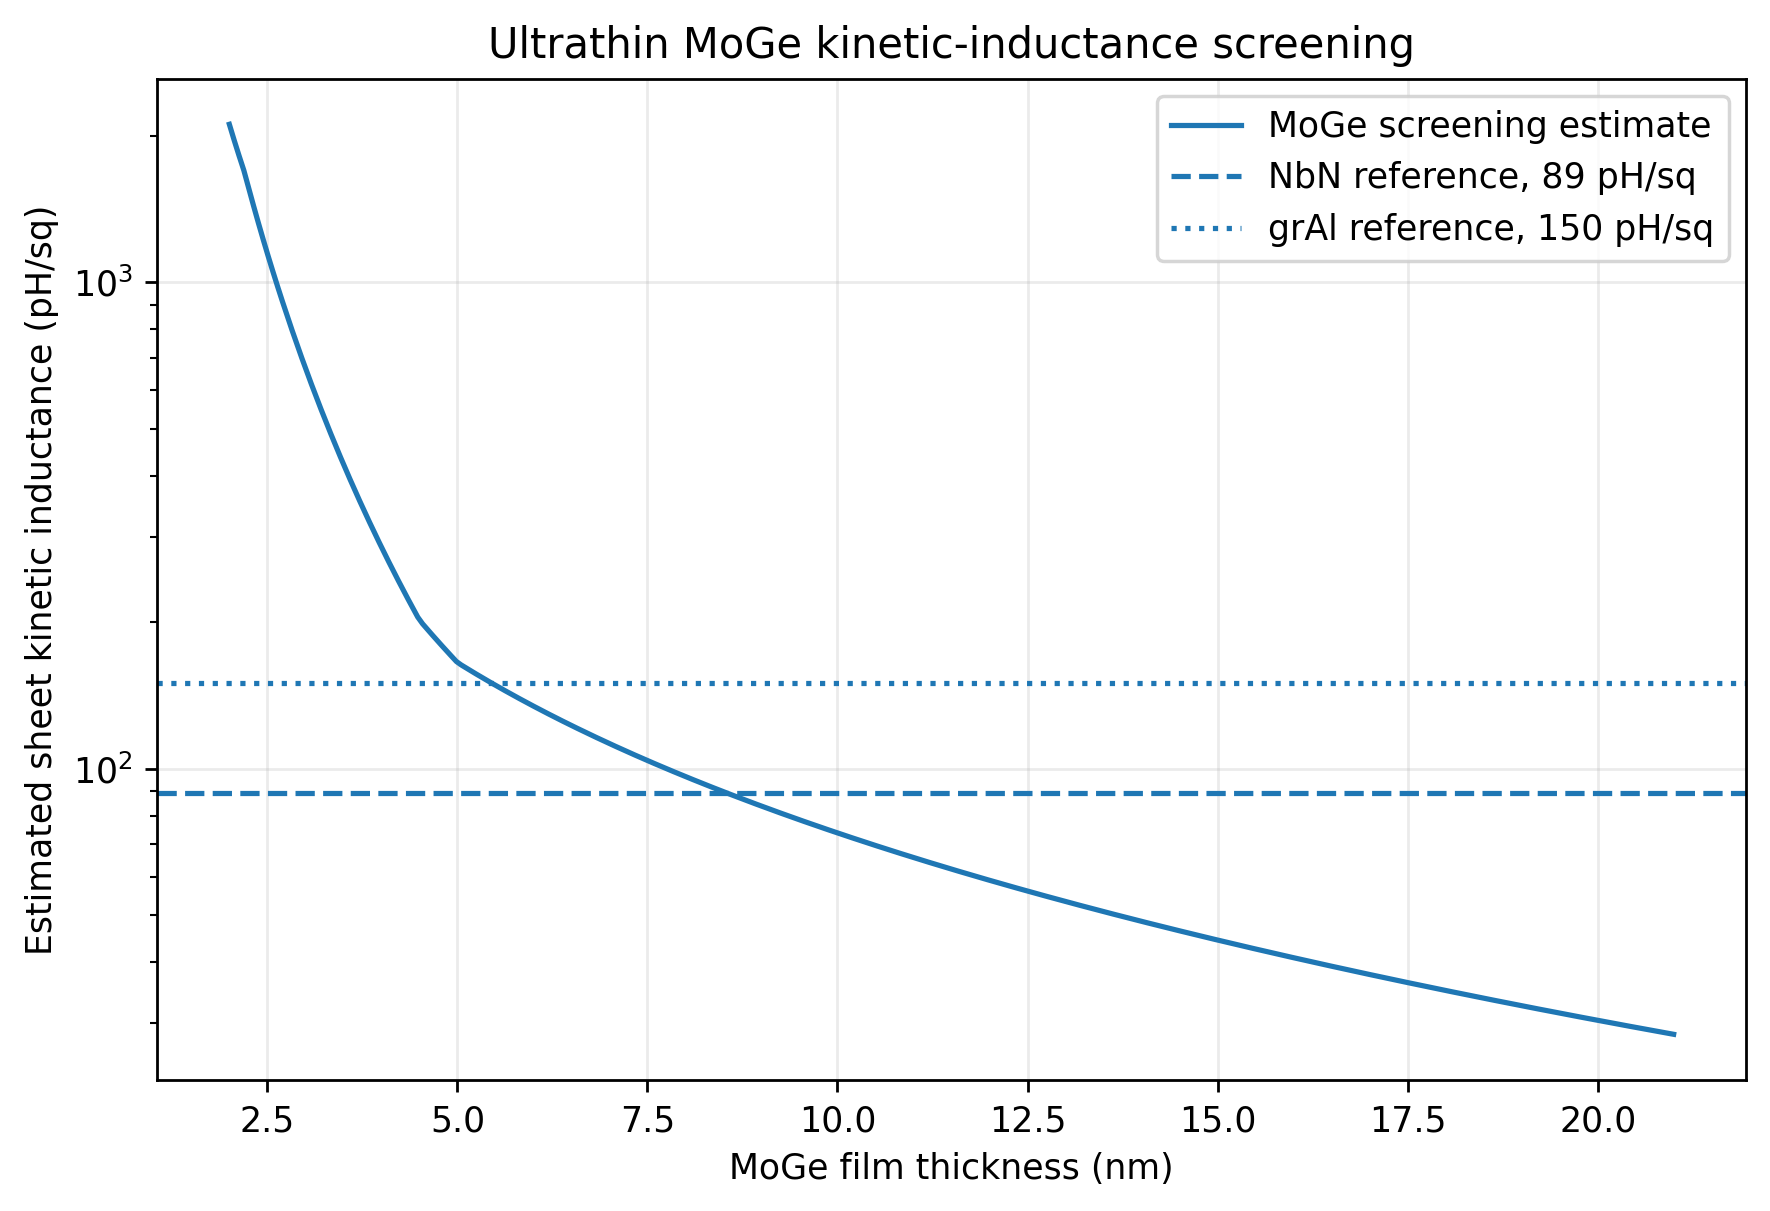

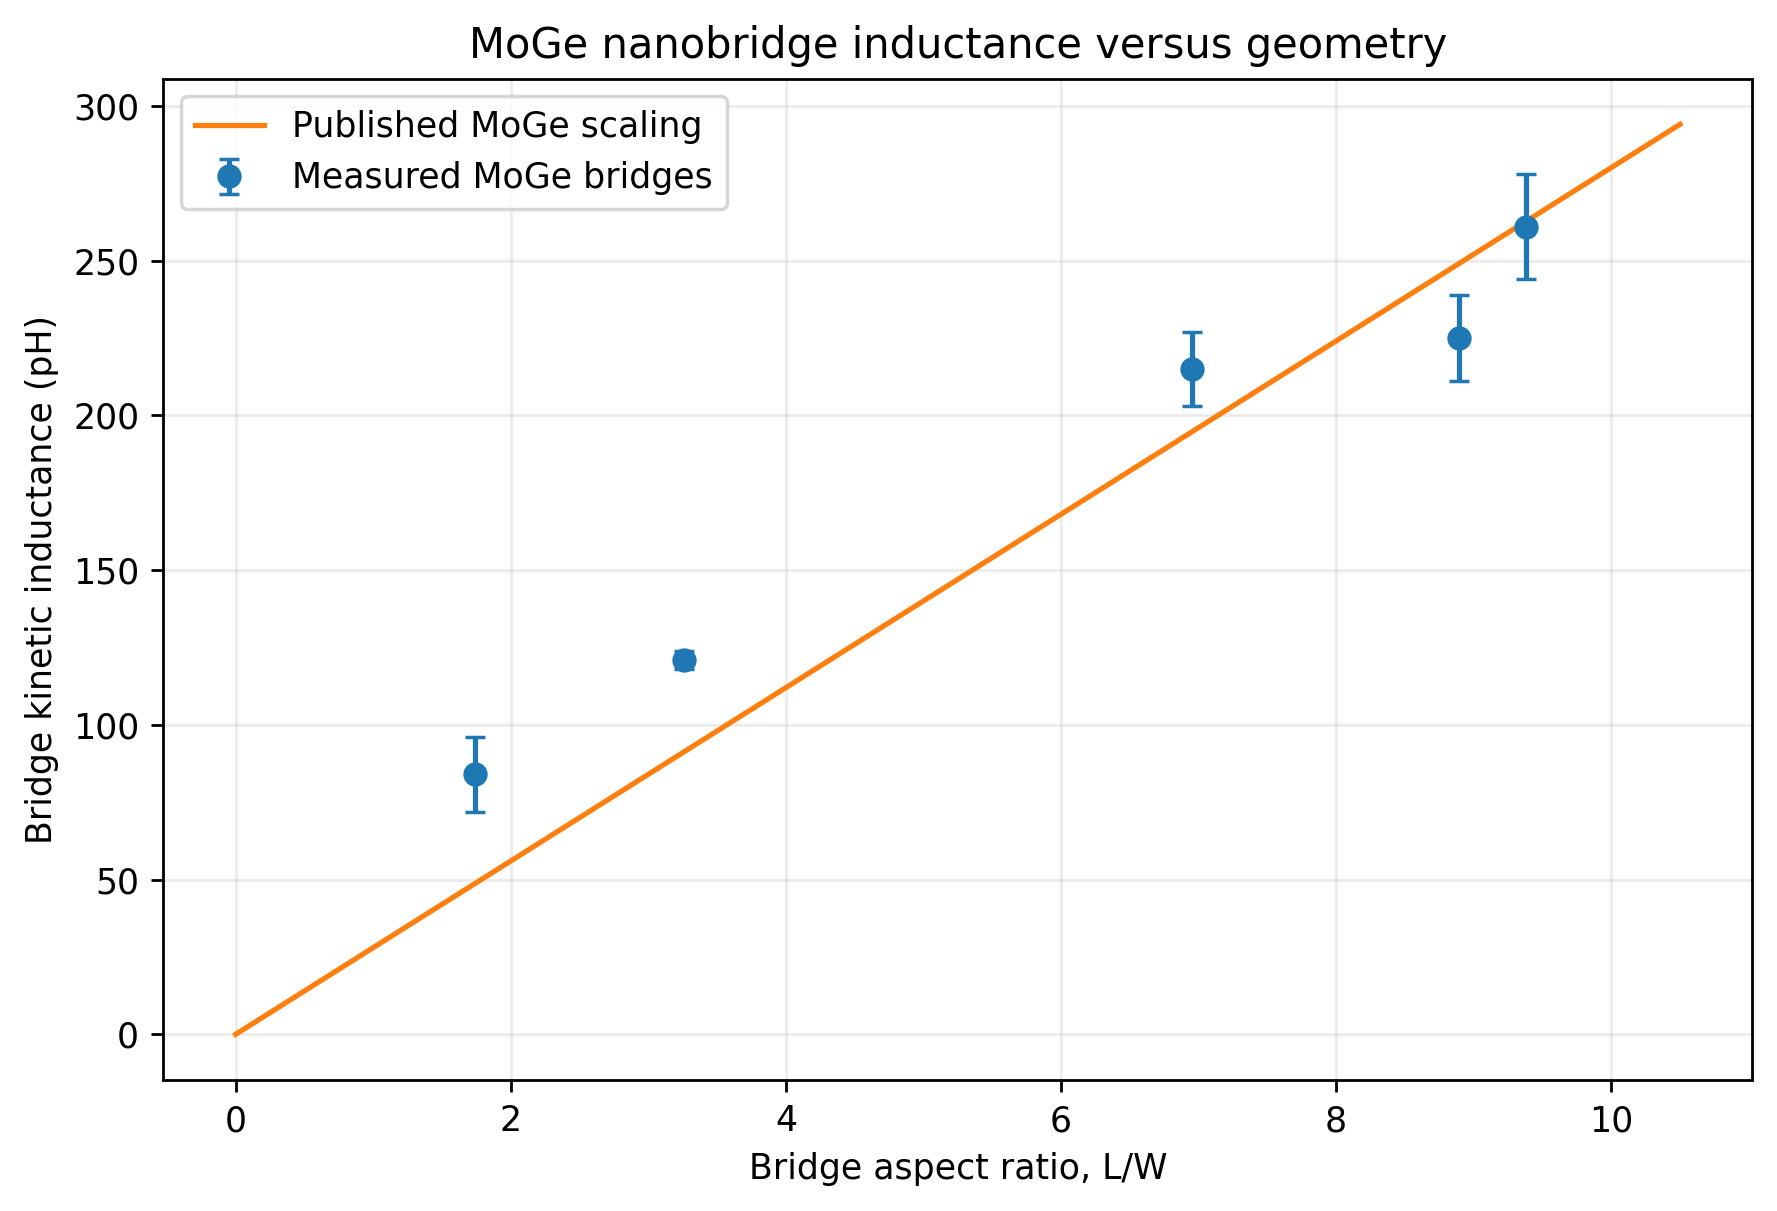

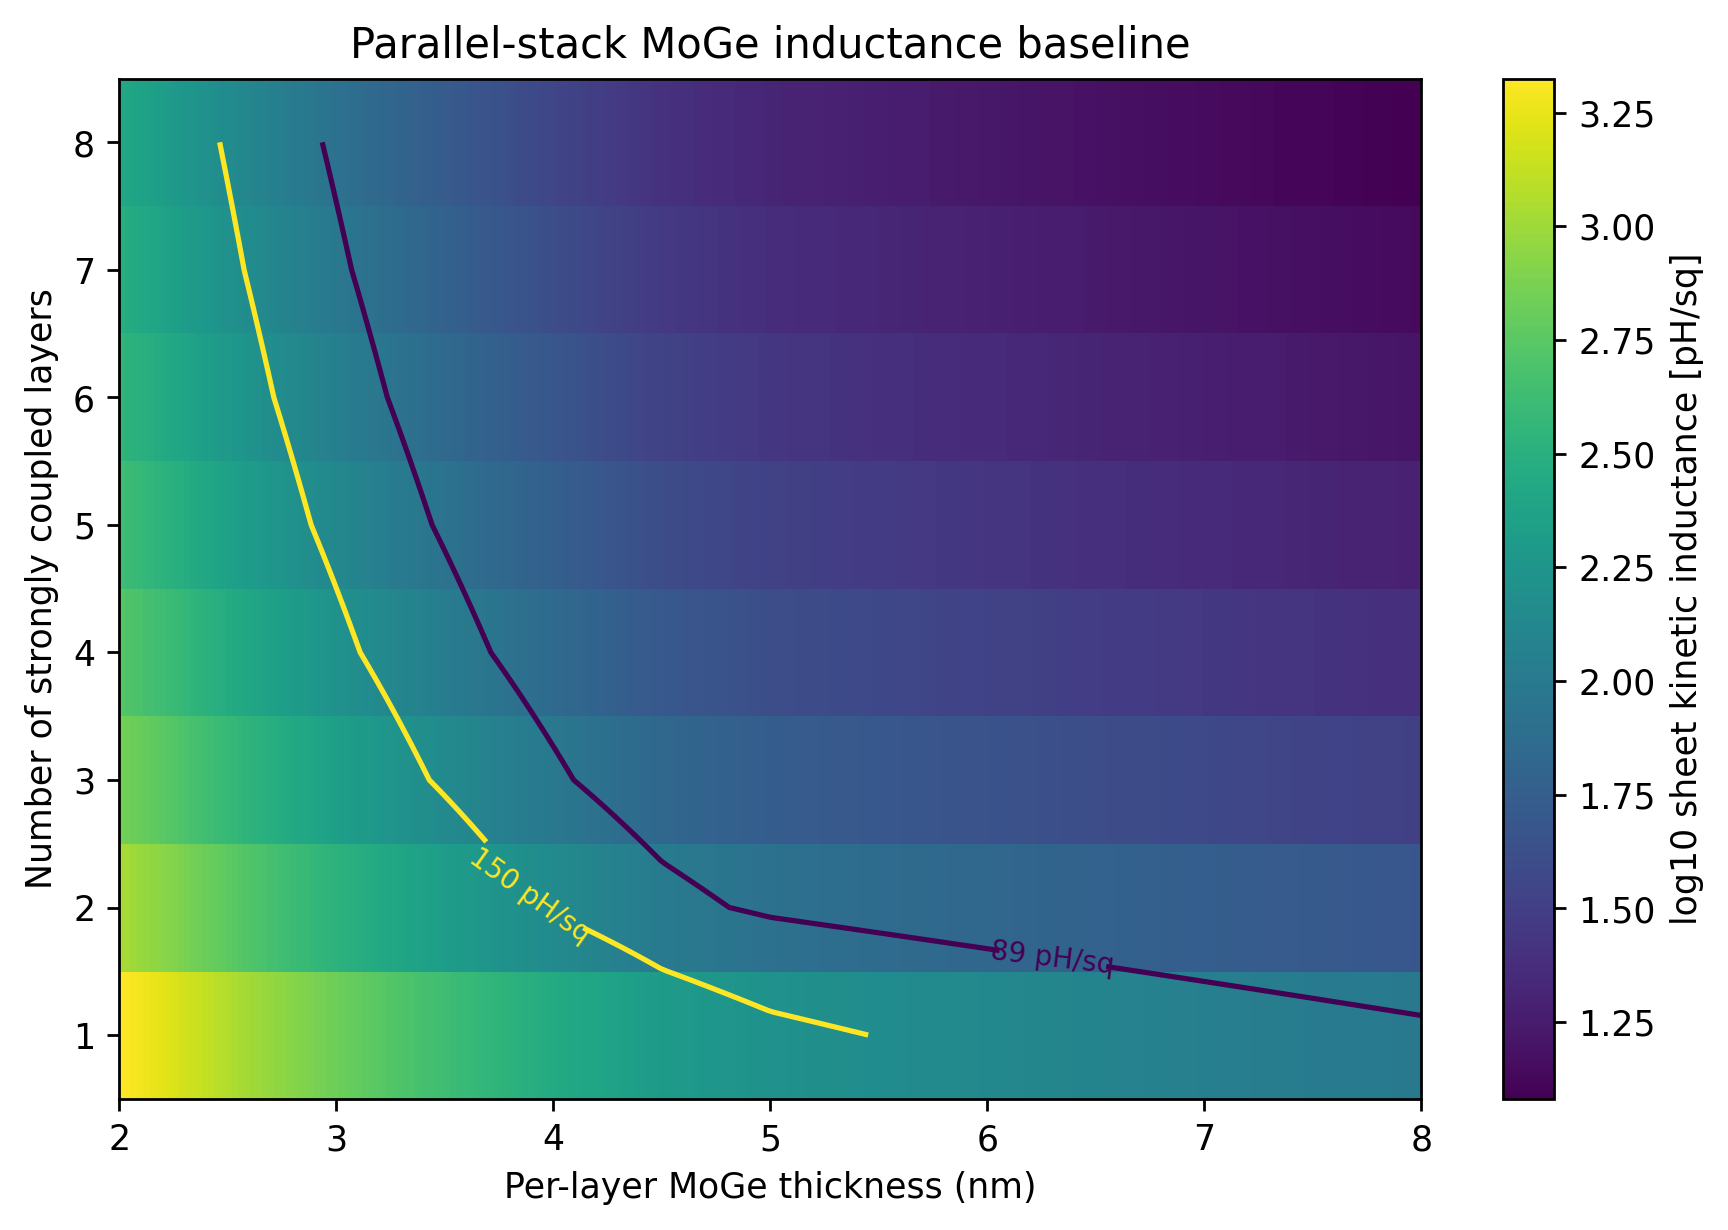

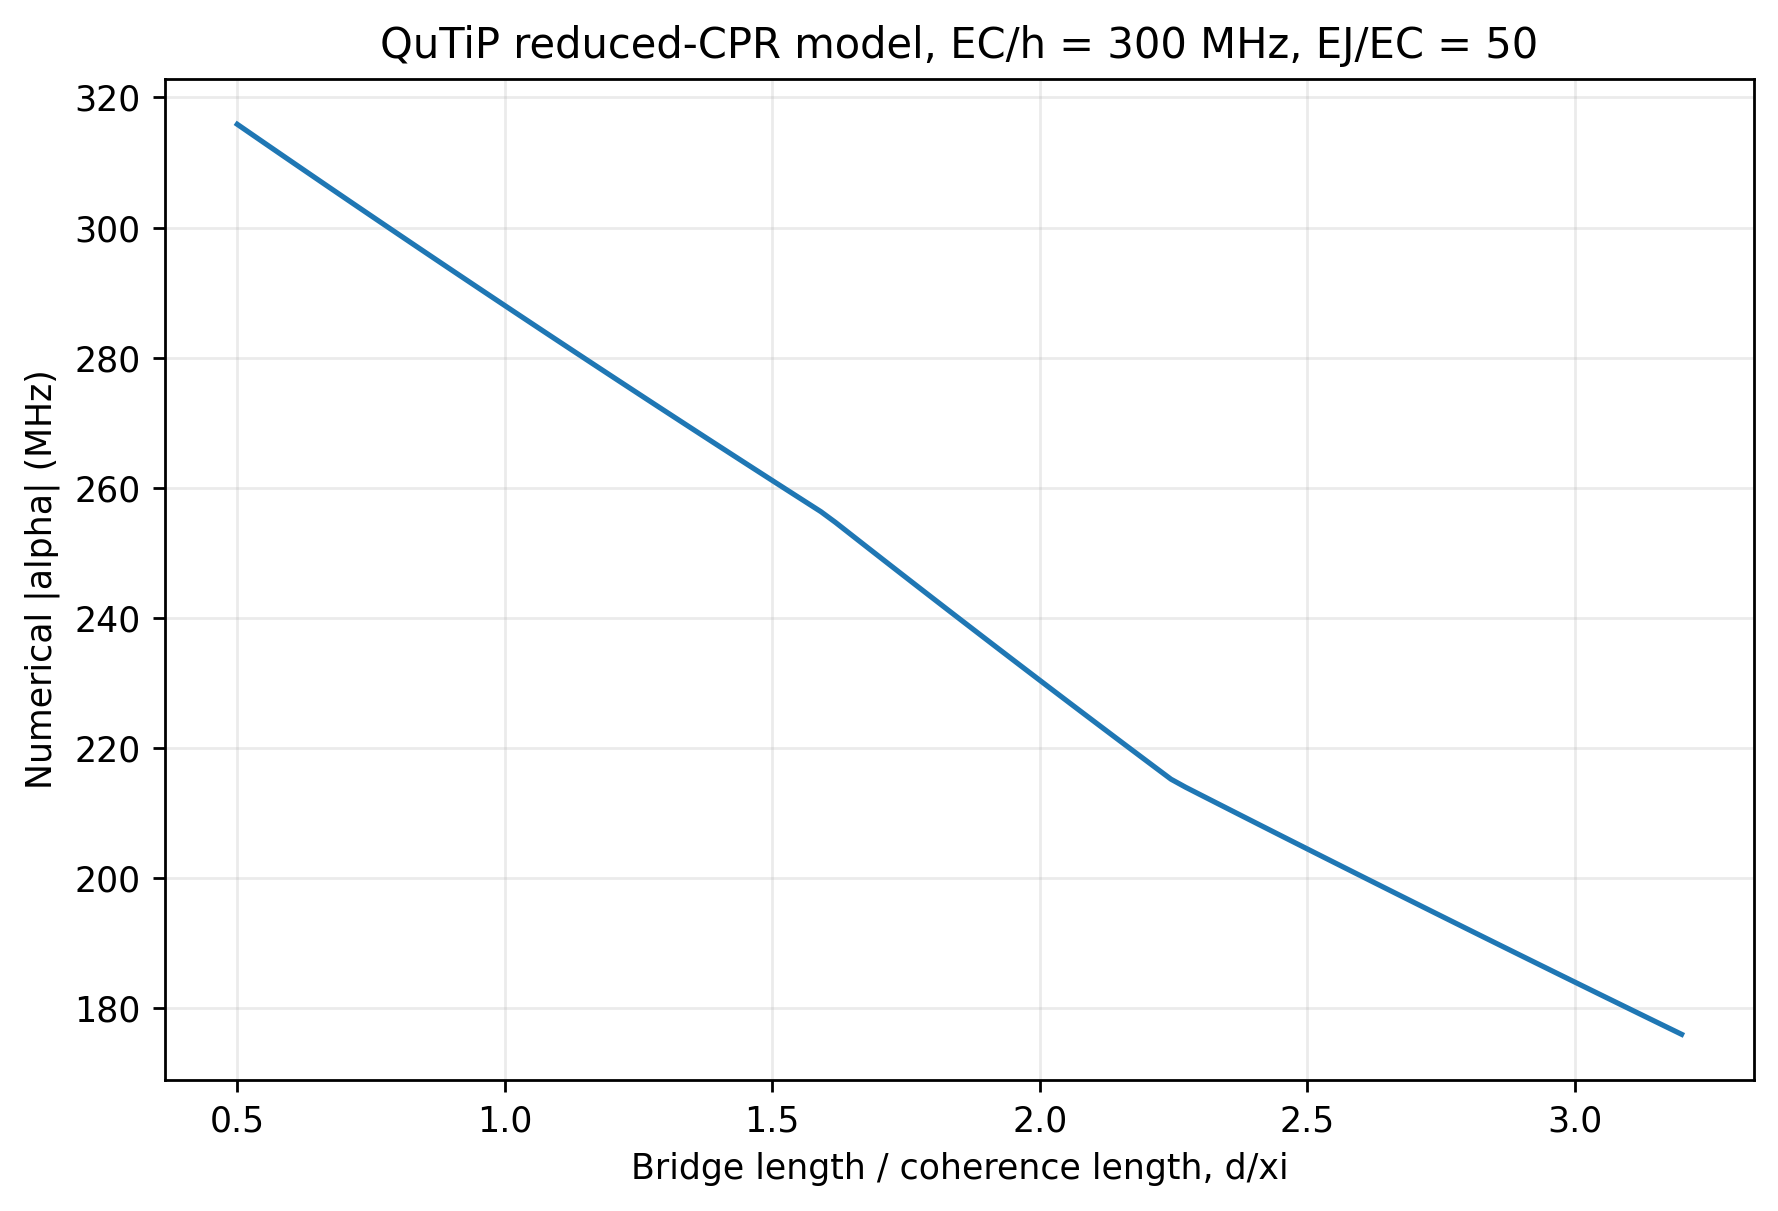

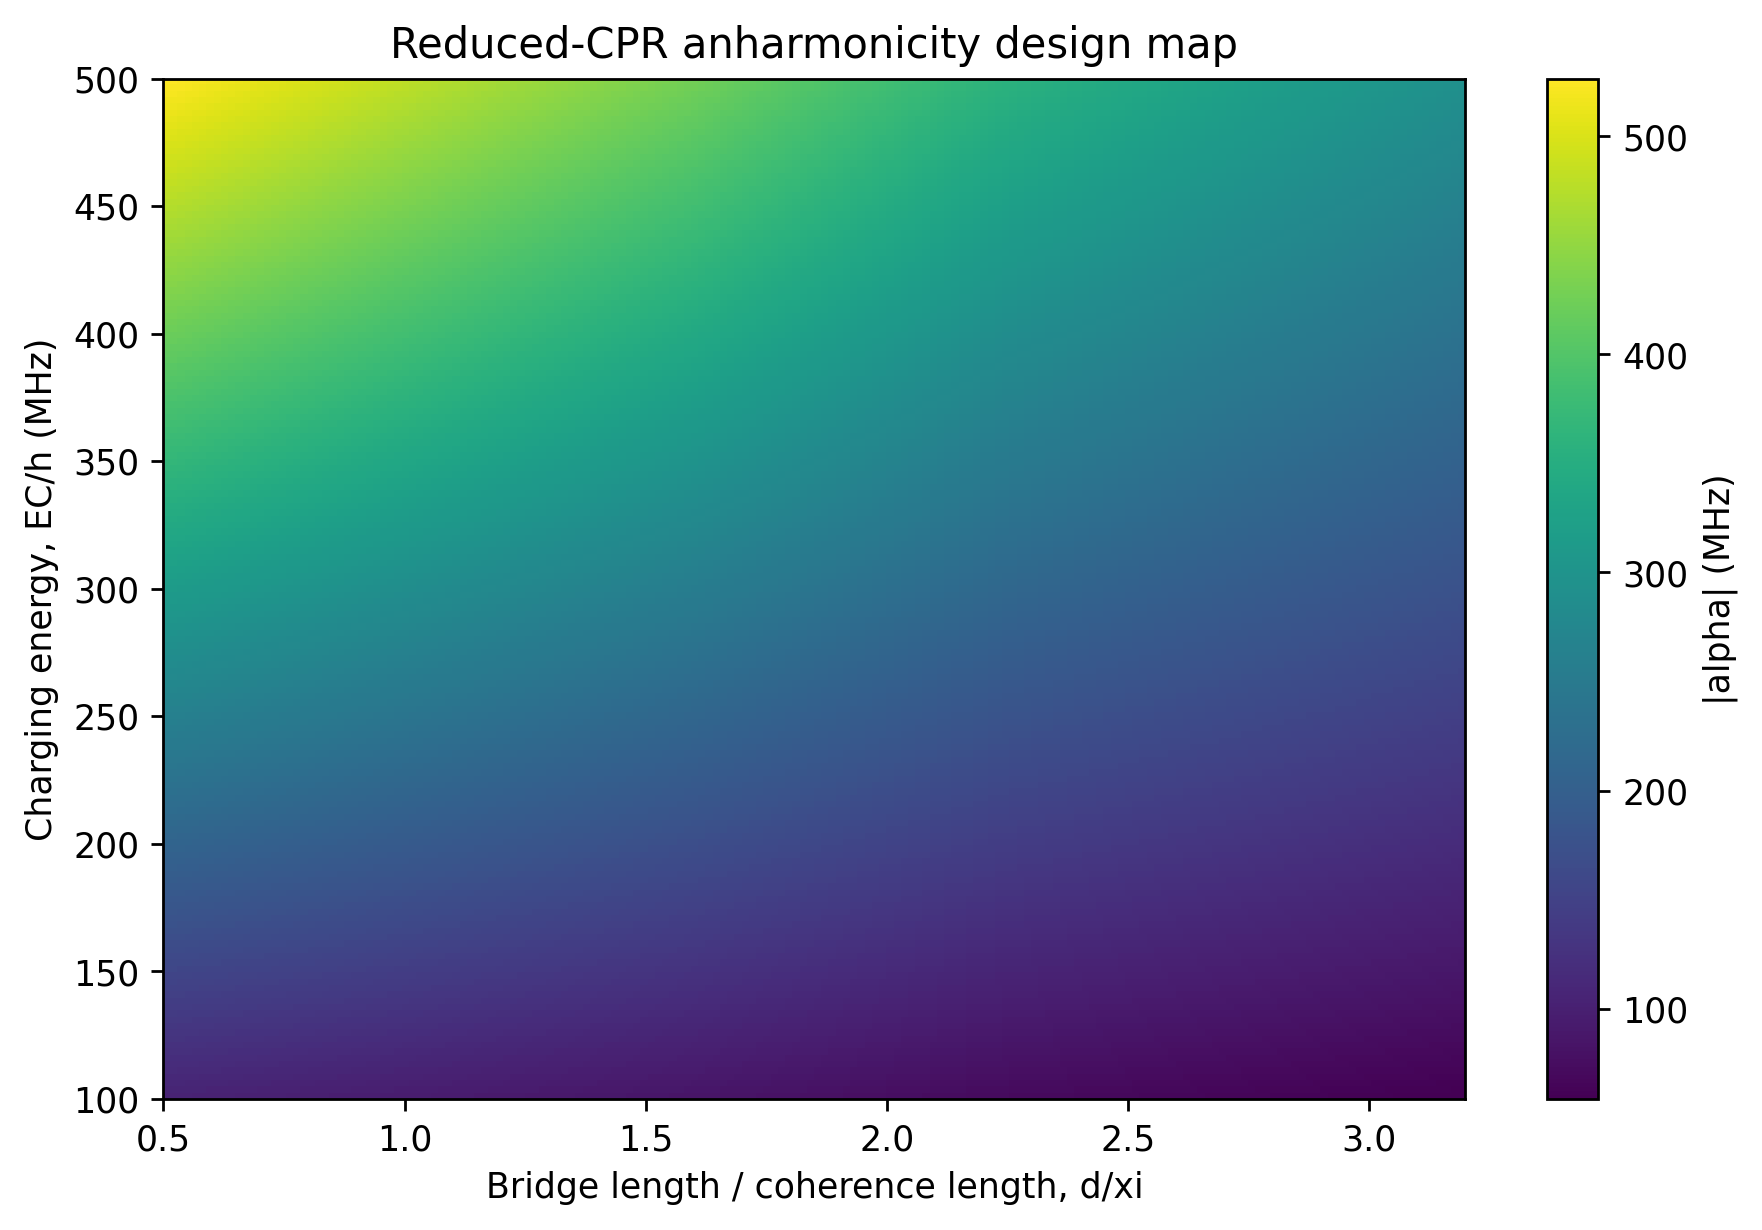

,layers,locking_scale_ghz
0,1,0.000000
1,2,10.000000
2,3,5.000000
3,4,2.928932
4,5,1.909830
5,6,1.339746
6,7,0.990311
7,8,0.761205


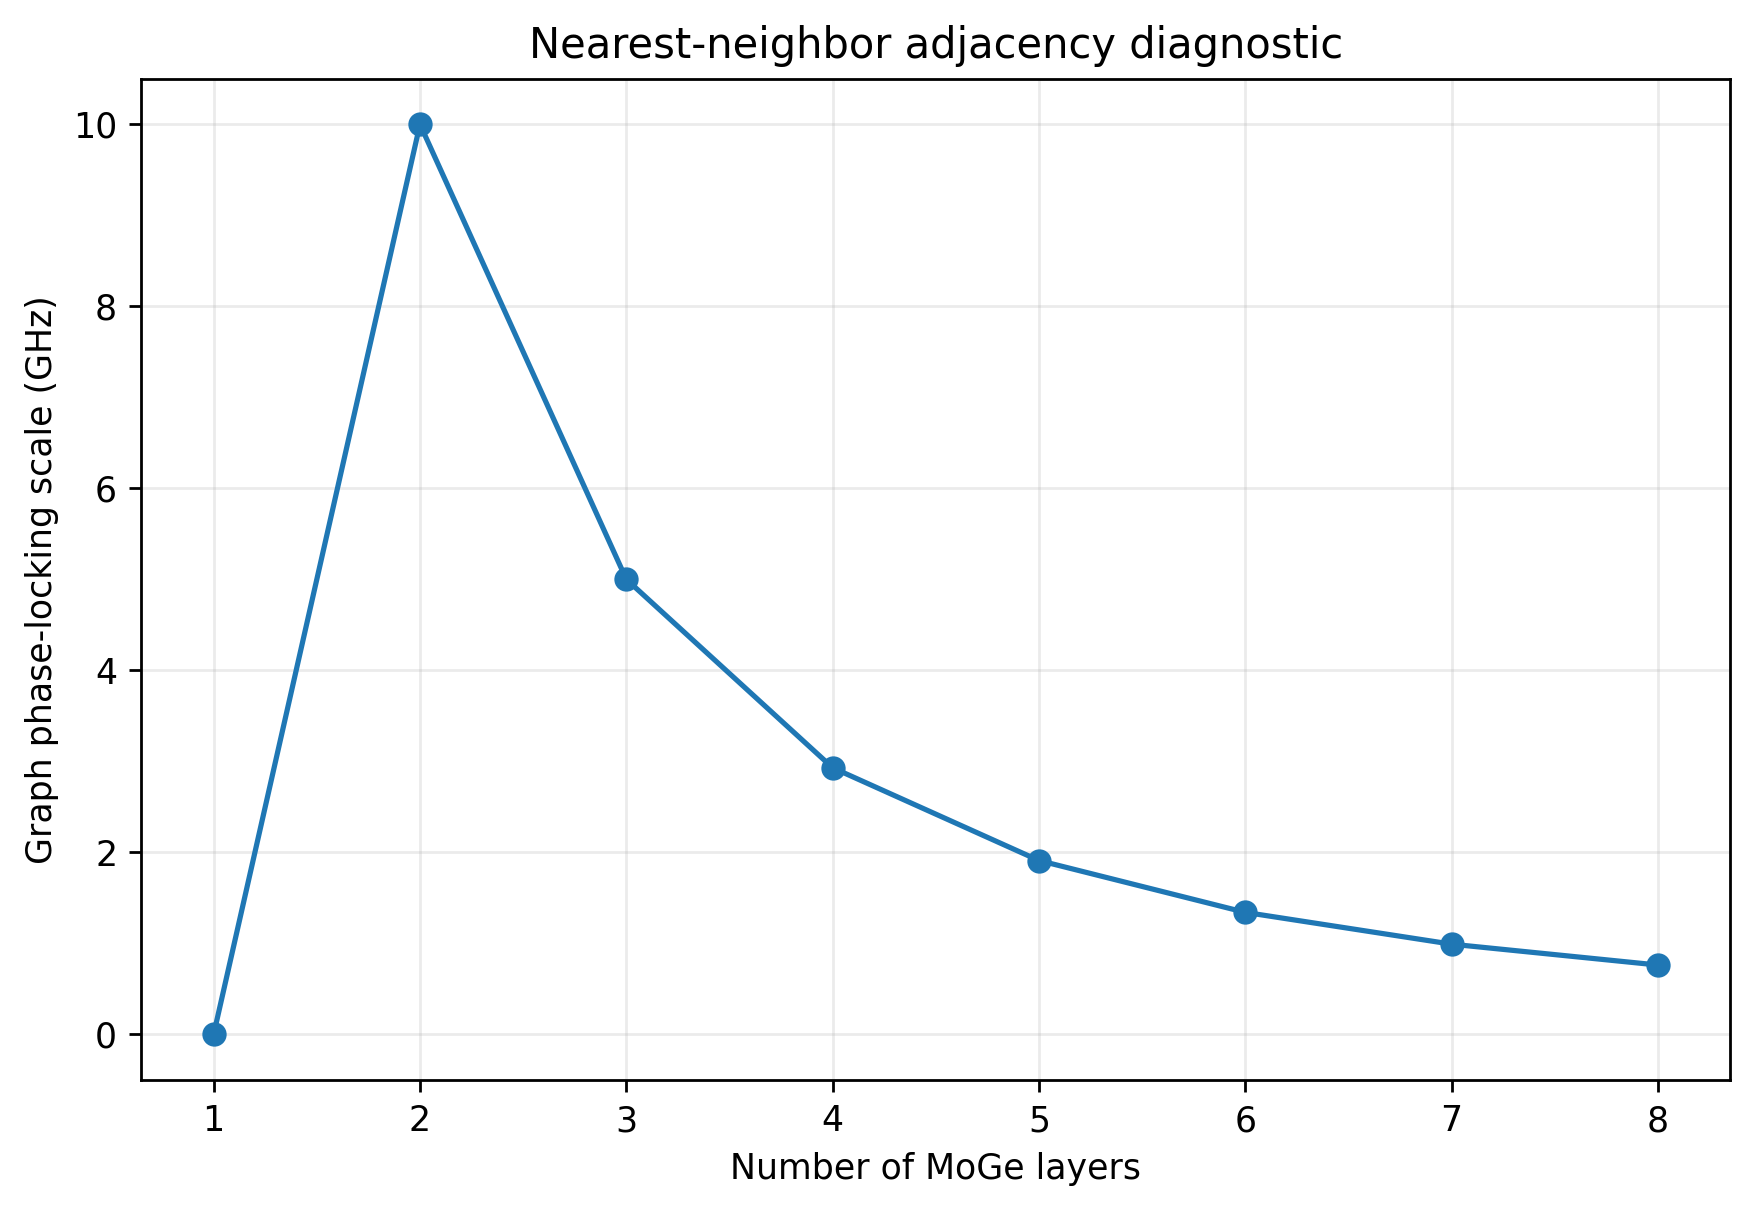

CuPy GPU path active: True


In [2]:
"""GPU-assisted nanobridge-qubit material and CPR screening."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qutip as qt

try:
    import cupy as cp
    GPU_AVAILABLE = True
except Exception:
    cp = np
    GPU_AVAILABLE = False


# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
PLOT_DPI = 250
MOGE_RESISTIVITY_OHM_M = 219e-8
MOGE_BETA = 0.25

MOGE_THICKNESS_ANCHORS_NM = np.array([2.0, 4.5, 21.0])
MOGE_TC_ANCHORS_K = np.array([1.8, 5.0, 7.0])

NBN_SHEET_LK_PH = 89.0
GRAL_SHEET_LK_PH = 150.0

D_OVER_XI_MIN = 0.5
D_OVER_XI_MAX = 3.2
EJ_OVER_EC = 50.0
EC_MHZ = 300.0

MAX_STACK_LAYERS = 8
INTERFACE_COUPLING_GHZ = 5.0
CHARGE_CUTOFF = 24

plt.rcParams["figure.dpi"] = PLOT_DPI

HBAR = 1.054_571_817e-34
K_B = 1.380_649e-23


def interpolate_moge_tc(thickness_nm: np.ndarray) -> np.ndarray:
    """Interpolate MoGe Tc anchors for screening calculations."""
    return np.interp(
        thickness_nm,
        MOGE_THICKNESS_ANCHORS_NM,
        MOGE_TC_ANCHORS_K,
    )


def stiffness_retention(thickness_nm: np.ndarray) -> np.ndarray:
    """Approximate superfluid-stiffness loss in ultrathin MoGe."""
    retention = np.ones_like(thickness_nm, dtype=float)
    thin = thickness_nm < 5.0
    retention[thin] = np.interp(
        thickness_nm[thin],
        [2.0, 2.2, 5.0],
        [0.55, 0.55, 1.0],
    )
    return retention


def sheet_lk_ph(thickness_nm: np.ndarray) -> np.ndarray:
    """Estimate MoGe sheet kinetic inductance in pH per square."""
    tc_k = interpolate_moge_tc(thickness_nm)
    sheet_resistance = (
        MOGE_RESISTIVITY_OHM_M / (thickness_nm * 1e-9)
    )
    dirty_lk_h = (
        MOGE_BETA * HBAR * sheet_resistance / (K_B * tc_k)
    )
    return dirty_lk_h * 1e12 / stiffness_retention(thickness_nm)


def a1_from_bridge_ratio(d_over_xi: np.ndarray) -> np.ndarray:
    """Interpolate published GL cubic-CPR coefficients."""
    return np.interp(
        d_over_xi,
        [0.0, 1.60, 2.25, 3.20],
        [-1.0, -2.0 / 3.0, -1.0 / 2.0, -1.0 / 3.0],
    )


def second_harmonic_ratio(a1: float) -> float:
    """Match a cubic CPR coefficient with a two-harmonic periodic CPR."""
    return -(1.0 + a1) / (8.0 + 2.0 * a1)


def qutip_reduced_cpr_spectrum(
    a1: float,
    ec_mhz: float = EC_MHZ,
    ej_over_ec: float = EJ_OVER_EC,
    charge_cutoff: int = CHARGE_CUTOFF,
) -> tuple[np.ndarray, float]:
    """Diagonalize a Fourier-matched nanobridge Hamiltonian with QuTiP."""
    charges = np.arange(-charge_cutoff, charge_cutoff + 1)
    size = charges.size

    charge_term = qt.Qobj(np.diag(4.0 * ec_mhz * charges**2))

    cos_phi = np.zeros((size, size), dtype=float)
    cos_2phi = np.zeros((size, size), dtype=float)

    for index in range(size - 1):
        cos_phi[index, index + 1] = 0.5
        cos_phi[index + 1, index] = 0.5

    for index in range(size - 2):
        cos_2phi[index, index + 2] = 0.5
        cos_2phi[index + 2, index] = 0.5

    harmonic_ratio = second_harmonic_ratio(a1)
    denominator = 1.0 + 2.0 * harmonic_ratio
    ej_mhz = ej_over_ec * ec_mhz

    hamiltonian = (
        charge_term
        - (ej_mhz / denominator) * qt.Qobj(cos_phi)
        - (
            ej_mhz
            * harmonic_ratio
            / (2.0 * denominator)
        )
        * qt.Qobj(cos_2phi)
    )

    eigenvalues = np.asarray(hamiltonian.eigenenergies()[:4])
    e01 = eigenvalues[1] - eigenvalues[0]
    e12 = eigenvalues[2] - eigenvalues[1]
    alpha_mhz = e12 - e01
    return eigenvalues, alpha_mhz


def path_graph_laplacian(layer_count: int):
    """Return a nearest-neighbor layer adjacency Laplacian on GPU."""
    xp = cp
    adjacency = xp.zeros((layer_count, layer_count), dtype=float)

    if layer_count > 1:
        indices = xp.arange(layer_count - 1)
        adjacency[indices, indices + 1] = 1.0
        adjacency[indices + 1, indices] = 1.0

    degree = xp.diag(xp.sum(adjacency, axis=1))
    return degree - adjacency


def interlayer_locking_scale_ghz(layer_count: int) -> float:
    """Estimate a graph-based nearest-neighbor phase-locking scale."""
    if layer_count == 1:
        return 0.0

    laplacian = path_graph_laplacian(layer_count)
    eigenvalues = cp.linalg.eigvalsh(laplacian)

    if GPU_AVAILABLE:
        eigenvalues = cp.asnumpy(eigenvalues)

    return float(eigenvalues[1] * INTERFACE_COUPLING_GHZ)


# ---------------------------------------------------
# LITERATURE-ANCHORED MoGe BRIDGE TABLE
# ---------------------------------------------------
bridge_data = pd.DataFrame(
    {
        "device": ["c", "m", "u", "v", "w"],
        "length_nm": [101, 176, 319, 313, 338],
        "width_nm": [58, 54, 34, 45, 38],
        "lk_ph": [84, 121, 261, 215, 225],
        "lk_error_ph": [12, 3, 17, 12, 14],
    }
)
bridge_data["aspect_ratio"] = (
    bridge_data["length_nm"] / bridge_data["width_nm"]
)
display(bridge_data)


# ---------------------------------------------------
# 1D - MoGe thickness screening
# ---------------------------------------------------
thickness_nm = np.linspace(2.0, 21.0, 300)
moge_lk_ph = sheet_lk_ph(thickness_nm)

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(thickness_nm, moge_lk_ph, label="MoGe screening estimate")
ax.axhline(
    NBN_SHEET_LK_PH,
    linestyle="--",
    label="NbN reference, 89 pH/sq",
)
ax.axhline(
    GRAL_SHEET_LK_PH,
    linestyle=":",
    label="grAl reference, 150 pH/sq",
)
ax.set_yscale("log")
ax.set_xlabel("MoGe film thickness (nm)")
ax.set_ylabel("Estimated sheet kinetic inductance (pH/sq)")
ax.set_title("Ultrathin MoGe kinetic-inductance screening")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
plt.show()


# ---------------------------------------------------
# SCATTER - MoGe bridge geometry
# ---------------------------------------------------
aspect = bridge_data["aspect_ratio"].to_numpy()
lk = bridge_data["lk_ph"].to_numpy()
lk_error = bridge_data["lk_error_ph"].to_numpy()

model_aspect = np.linspace(0.0, 10.5, 250)
model_lk = (
    MOGE_BETA * HBAR * 88.0 / (K_B * 6.0) * 1e12
) * model_aspect

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.errorbar(
    aspect,
    lk,
    yerr=lk_error,
    fmt="o",
    capsize=3,
    label="Measured MoGe bridges",
)
ax.plot(model_aspect, model_lk, label="Published MoGe scaling")
ax.set_xlabel("Bridge aspect ratio, L/W")
ax.set_ylabel("Bridge kinetic inductance (pH)")
ax.set_title("MoGe nanobridge inductance versus geometry")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
plt.show()


# ---------------------------------------------------
# HEAT MAP - Strongly phase-locked MoGe stack baseline
# ---------------------------------------------------
per_layer_thickness_nm = np.linspace(2.0, 8.0, 220)
single_layer_lk = sheet_lk_ph(per_layer_thickness_nm)
layer_counts = np.arange(1, MAX_STACK_LAYERS + 1)
effective_stack_lk = single_layer_lk[None, :] / layer_counts[:, None]

fig, ax = plt.subplots(figsize=(8.4, 5.3))
image = ax.imshow(
    np.log10(effective_stack_lk),
    origin="lower",
    aspect="auto",
    extent=[
        per_layer_thickness_nm.min(),
        per_layer_thickness_nm.max(),
        0.5,
        MAX_STACK_LAYERS + 0.5,
    ],
)
contours = ax.contour(
    per_layer_thickness_nm,
    layer_counts,
    effective_stack_lk,
    levels=[NBN_SHEET_LK_PH, GRAL_SHEET_LK_PH],
)
ax.clabel(contours, inline=True, fontsize=8, fmt="%.0f pH/sq")
ax.set_xlabel("Per-layer MoGe thickness (nm)")
ax.set_ylabel("Number of strongly coupled layers")
ax.set_title("Parallel-stack MoGe inductance baseline")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("log10 sheet kinetic inductance [pH/sq]")
plt.show()


# ---------------------------------------------------
# QUTIP - CPR-dependent anharmonicity
# ---------------------------------------------------
d_over_xi = np.linspace(D_OVER_XI_MIN, D_OVER_XI_MAX, 100)
a1_values = a1_from_bridge_ratio(d_over_xi)

numeric_alpha_mhz = np.array(
    [
        abs(qutip_reduced_cpr_spectrum(a1)[1])
        for a1 in a1_values
    ]
)

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(d_over_xi, numeric_alpha_mhz)
ax.set_xlabel("Bridge length / coherence length, d/xi")
ax.set_ylabel("Numerical |alpha| (MHz)")
ax.set_title(
    f"QuTiP reduced-CPR model, EC/h = {EC_MHZ:.0f} MHz, "
    f"EJ/EC = {EJ_OVER_EC:.0f}"
)
ax.grid(True, alpha=0.25)
plt.show()


# ---------------------------------------------------
# GPU HEAT MAP - EC and bridge-length sweep
# ---------------------------------------------------
ec_axis_mhz = cp.linspace(100.0, 500.0, 161)
d_axis = cp.linspace(D_OVER_XI_MIN, D_OVER_XI_MAX, 180)

d_axis_cpu = cp.asnumpy(d_axis) if GPU_AVAILABLE else np.asarray(d_axis)
a1_cpu = a1_from_bridge_ratio(d_axis_cpu)

alpha_per_ec = np.array(
    [
        abs(qutip_reduced_cpr_spectrum(a1, ec_mhz=1.0)[1])
        for a1 in a1_cpu
    ]
)

alpha_per_ec_gpu = cp.asarray(alpha_per_ec)
alpha_heatmap = ec_axis_mhz[:, None] * alpha_per_ec_gpu[None, :]

if GPU_AVAILABLE:
    alpha_heatmap = cp.asnumpy(alpha_heatmap)
    ec_axis_plot = cp.asnumpy(ec_axis_mhz)
else:
    ec_axis_plot = np.asarray(ec_axis_mhz)

fig, ax = plt.subplots(figsize=(8.4, 5.3))
image = ax.imshow(
    alpha_heatmap,
    origin="lower",
    aspect="auto",
    extent=[
        D_OVER_XI_MIN,
        D_OVER_XI_MAX,
        float(ec_axis_plot.min()),
        float(ec_axis_plot.max()),
    ],
)
ax.set_xlabel("Bridge length / coherence length, d/xi")
ax.set_ylabel("Charging energy, EC/h (MHz)")
ax.set_title("Reduced-CPR anharmonicity design map")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("|alpha| (MHz)")
plt.show()


# ---------------------------------------------------
# ADJACENCY - Interlayer phase-locking diagnostic
# ---------------------------------------------------
locking_rows = []
for layer_count in range(1, MAX_STACK_LAYERS + 1):
    locking_rows.append(
        {
            "layers": layer_count,
            "locking_scale_ghz": interlayer_locking_scale_ghz(
                layer_count
            ),
        }
    )

locking_table = pd.DataFrame(locking_rows)
display(locking_table)

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(
    locking_table["layers"],
    locking_table["locking_scale_ghz"],
    marker="o",
)
ax.set_xlabel("Number of MoGe layers")
ax.set_ylabel("Graph phase-locking scale (GHz)")
ax.set_title("Nearest-neighbor adjacency diagnostic")
ax.grid(True, alpha=0.25)
plt.show()

print(f"CuPy GPU path active: {GPU_AVAILABLE}")


## Interpretation boundary

The adjacency Laplacian is a reduced phase-locking scaffold. Its coupling constant needs calibration from a microscopic Usadel, BdG, or measured multilayer response before it can predict a physical qubit spectrum. The parallel-stack heat map assumes strongly phase-locked identical layers, so its $L_k/N$ scaling is a baseline that exposes what interface engineering must overcome.
